In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings("ignore", category=Warning)

import sys
sys.path.append(f"./../")

from qiskit import QuantumCircuit, transpile
import itertools
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Operator, Pauli, SparsePauliOp
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
import os
import pandas as pd

from src.graphs import StaticGraph
from src.misc import graph_matchings_no_relabeling
from src.graph_simplifier import build_matching_circuit_iteratively

In [2]:
# Create output directory for plots
output_dir = "trotterization_plots"
os.makedirs(output_dir, exist_ok=True)

# Set up publication-quality plotting style
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'lines.linewidth': 2,
    'lines.markersize': 8,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'text.usetex': False  # Set to True if you have LaTeX installed
})

In [ ]:
# Global storage for gate count data
gate_count_data = []

def build_matching_circuit(n_qubits, n_steps, delta_t, matchings):
    """
    Build quantum circuit using matching-based decomposition.

    Builds one Trotter step circuit, then repeats it n_steps times.

    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        matchings: List of matchings, where each matching is a list of edges

    Returns:
        QuantumCircuit: Complete matching-based circuit
    """
    return build_matching_circuit_iteratively(n_qubits, n_steps, delta_t, matchings)


def build_pauli_circuit(n_qubits, n_steps, delta_t, hamiltonian):
    """
    Build quantum circuit using Pauli decomposition with TRUE Trotter approximation.

    This creates a proper n_steps Trotter approximation by:
    1. Decomposing H into Pauli terms: H = sum_i c_i * P_i
    2. Approximating exp(-iHt) ≈ [prod_i exp(-i*c_i*P_i*t/n)]^n
    3. Each Trotter step evolves individual Pauli terms

    Args:
        n_qubits: Number of qubits
        n_steps: Number of Trotter steps
        delta_t: Time step size
        hamiltonian: Hamiltonian matrix

    Returns:
        QuantumCircuit: Complete Pauli-based circuit with TRUE Trotter approximation
    """
    # Decompose Hamiltonian into Pauli basis
    pauli_strings = []
    coeffs = []

    for pauli_string in ["".join(p) for p in itertools.product("IXYZ", repeat=n_qubits)]:
        P = Pauli(pauli_string)
        P_op = Operator(P).data
        coeff = np.trace(P_op.conj().T @ hamiltonian) / (2**n_qubits)

        real_coeff = float(np.real(coeff))
        if not np.isclose(real_coeff, 0, atol=1e-10):
            pauli_strings.append(pauli_string)
            coeffs.append(real_coeff)

    if not coeffs:
        return QuantumCircuit(n_qubits)

    # Build circuit with TRUE Trotter approximation
    # Each Trotter step: evolve each Pauli term separately
    qc = QuantumCircuit(n_qubits)

    for step in range(n_steps):
        # Evolve each Pauli term for time delta_t/n_steps
        for pauli_str, coeff in zip(pauli_strings, coeffs):
            # Create single-term Hamiltonian
            single_term = SparsePauliOp([pauli_str], [coeff])

            # Evolve this term
            evo_gate = PauliEvolutionGate(
                single_term,
                time=delta_t / n_steps
            )
            qc.append(evo_gate, range(n_qubits))

    return qc


def build_exact_circuit(n_qubits, delta_t, hamiltonian):
    """
    Build exact quantum circuit using matrix exponential.

    Args:
        n_qubits: Number of qubits
        delta_t: Total time
        hamiltonian: Hamiltonian matrix

    Returns:
        QuantumCircuit: Exact evolution circuit
    """
    qc = QuantumCircuit(n_qubits)

    # Compute exact evolution operator
    exact_op = expm(-1j * hamiltonian * delta_t)
    exact_operator = Operator(exact_op)

    # Add as unitary gate
    qc.unitary(exact_operator, range(n_qubits), label='exact_evolution')

    return qc


def analyze_and_plot(edges, title, output_dir="trotterization_plots", delta_t=0.1):
    """
    Analyze quantum time evolution errors and plot results.
    Compares matching-based and Pauli decomposition methods.

    Args:
        edges: Graph edges (set of tuples of binary strings)
               Example: {('00','01'), ('00','10'), ('00','11')}
        title: Plot title
        output_dir: Directory to save plots (default: "trotterization_plots")
        delta_t: Time step size (default: 0.1)

    Example:
        edges = {('00','01'), ('00','10'), ('00','11')}
        analyze_and_plot(edges, "Tree Graph T4")
    """
    global gate_count_data

    # Create output directory if it doesn't exist
    import os
    os.makedirs(output_dir, exist_ok=True)

    n_steps_list = [1, 2, 5, 10, 20, 50, 100]

    print(f"\n{title}")
    print("="*60)
    print(f"Original edges: {edges}")

    # Create graph
    G = StaticGraph(edges)
    print(f"Number of qubits: {G.n_qubits}")

    # Display graph
    print("\nGraph:")
    try:
        display(G.draw())
    except:
        print("(Graph display not available)")

    # Get matchings (no relabeling)
    matchings = graph_matchings_no_relabeling(edges)

    print(f"\nMatchings: {len(matchings)}")
    print(f"Matchings: {matchings}")

    # Infer number of qubits
    first_edge = next(iter(edges))
    n_qubits = len(first_edge[0])

    print(f"Number of qubits: {n_qubits}")

    # Calculate total Hamming cost
    def calculate_total_hamming_cost(edge_set):
        """Calculate total Hamming distance for all edges in the set"""
        total_cost = 0
        for edge in edge_set:
            v1, v2 = edge
            hamming_dist = sum(c1 != c2 for c1, c2 in zip(v1, v2))
            total_cost += hamming_dist
        return total_cost

    hamming_cost = calculate_total_hamming_cost(edges)
    num_edges = len(edges)
    hamming_per_edge = hamming_cost / num_edges if num_edges > 0 else 0

    print(f"\nHamming Cost Analysis:")
    print(f"Total = {hamming_cost}, Edges = {num_edges}, Per Edge = {hamming_per_edge:.3f}")

    # Get Hamiltonian
    H = G.get_adj_mat()

    # Display sample circuits (with n_steps=1)
    sample_qc_matching = build_matching_circuit(n_qubits, 1, delta_t, matchings)
    print("\nSample Circuit - Matching (n_steps=1):")
    try:
        display(sample_qc_matching.draw('mpl'))
    except:
        print(sample_qc_matching.draw('text'))

    # Build exact circuit
    exact_qc = build_exact_circuit(n_qubits, delta_t, H)
    exact_operator = Operator(expm(-1j * H * delta_t))

    # Storage for results
    matching_vs_exact_errors = []
    pauli_vs_exact_errors = []

    matching_cx_no_opt = []
    matching_cx_opt = []
    matching_u3_no_opt = []
    matching_u3_opt = []
    pauli_cx_no_opt = []
    pauli_cx_opt = []
    pauli_u3_no_opt = []
    pauli_u3_opt = []

    # Analyze each n_steps
    for n_steps in n_steps_list:
        # Build matching circuit
        matching_qc = build_matching_circuit(n_qubits, n_steps, delta_t, matchings)
        transpiled_matching_no_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_matching_opt = transpile(matching_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        matching_operator = Operator(transpiled_matching_opt)

        matching_counts_no_opt = transpiled_matching_no_opt.count_ops()
        matching_counts_opt = transpiled_matching_opt.count_ops()

        matching_cx_no_opt.append(matching_counts_no_opt.get('cx', 0))
        matching_cx_opt.append(matching_counts_opt.get('cx', 0))
        matching_u3_no_opt.append(matching_counts_no_opt.get('u3', 0))
        matching_u3_opt.append(matching_counts_opt.get('u3', 0))

        # Build Pauli circuit
        pauli_qc = build_pauli_circuit(n_qubits, n_steps, delta_t, H)
        transpiled_pauli_no_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=0)
        transpiled_pauli_opt = transpile(pauli_qc, basis_gates=['u3', 'cx'], optimization_level=3)
        # Extract operator BEFORE transpilation to show proper Trotter convergence
        pauli_operator = Operator(pauli_qc)

        pauli_counts_no_opt = transpiled_pauli_no_opt.count_ops()
        pauli_counts_opt = transpiled_pauli_opt.count_ops()

        pauli_cx_no_opt.append(pauli_counts_no_opt.get('cx', 0))
        pauli_cx_opt.append(pauli_counts_opt.get('cx', 0))
        pauli_u3_no_opt.append(pauli_counts_no_opt.get('u3', 0))
        pauli_u3_opt.append(pauli_counts_opt.get('u3', 0))

        # Store gate count data
        gate_count_data.extend([
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': matching_cx_no_opt[-1],
                'U3_gates': matching_u3_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Matching',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': matching_cx_opt[-1],
                'U3_gates': matching_u3_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'No',
                'CX_gates': pauli_cx_no_opt[-1],
                'U3_gates': pauli_u3_no_opt[-1]
            },
            {
                'Case': title,
                'Method': 'Pauli',
                'n_steps': n_steps,
                'Optimization': 'Yes',
                'CX_gates': pauli_cx_opt[-1],
                'U3_gates': pauli_u3_opt[-1]
            }
        ])

        # Calculate errors
        matching_vs_exact = np.linalg.norm(matching_operator - exact_operator, ord=2)
        pauli_vs_exact = np.linalg.norm(pauli_operator - exact_operator, ord=2)

        matching_vs_exact_errors.append(matching_vs_exact)
        pauli_vs_exact_errors.append(pauli_vs_exact)

    # Print gate count summary
    print(f"\nGate Count Summary (U3/CX) for {title}:")
    print("="*110)

    # Create DataFrame for clean table display
    table_data = []
    for i, n_steps in enumerate(n_steps_list):
        table_data.append({
            "n_steps": n_steps,
            "Match (No Opt)": f"{matching_u3_no_opt[i]}/{matching_cx_no_opt[i]}",
            "Match (Opt)": f"{matching_u3_opt[i]}/{matching_cx_opt[i]}",
            "Pauli (No Opt)": f"{pauli_u3_no_opt[i]}/{pauli_cx_no_opt[i]}",
            "Pauli (Opt)": f"{pauli_u3_opt[i]}/{pauli_cx_opt[i]}"
        })

    df = pd.DataFrame(table_data)
    print(df.to_string(index=False))

    print(f"\nHamming cost/edge: {hamming_per_edge:.3f}")
    print("="*110)

    # Create error plot
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.loglog(n_steps_list, matching_vs_exact_errors, 'o-',
              label='Matching', linewidth=2.5, markersize=8,
              color='#1f77b4', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#1f77b4')
    ax.loglog(n_steps_list, pauli_vs_exact_errors, 's-',
              label='Pauli', linewidth=2.5, markersize=8,
              color='#d62728', markerfacecolor='white',
              markeredgewidth=2, markeredgecolor='#d62728')

    ax.set_xlabel('Number of Trotter steps', fontsize=14)
    ax.set_ylabel('2-norm Operator Difference (vs exact CTQW)', fontsize=14)

    plot_title = title.split(":")[1].strip() if ":" in title else title
    ax.set_title(plot_title, fontsize=16, pad=20)

    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Move legend outside the plot (below)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=True,
              fancybox=True, shadow=True, ncol=2)

    plt.tight_layout()

    # Save plot
    filename_base = title.lower().replace(" ", "_").replace(":", "").replace(
        "(", "").replace(")", "").replace("-", "_")
    filename_base = "_".join([part for part in filename_base.split("_") if part])
    filename = f"{output_dir}/{filename_base}_error_analysis.pdf"
    plt.savefig(filename, format='pdf', dpi=300, bbox_inches='tight')
    print(f"Error plot saved as: {filename}")

    plt.show()


def create_gate_count_summary_table():
    """Create comprehensive summary table of all gate counts."""
    global gate_count_data

    if not gate_count_data:
        print("No gate count data available.")
        return

    df = pd.DataFrame(gate_count_data)

    print("\n" + "="*100)
    print("COMPREHENSIVE GATE COUNT SUMMARY")
    print("="*100)

    for case in df['Case'].unique():
        print(f"\nCase: {case}")
        print("-" * 80)
        case_data = df[df['Case'] == case]

        for method in ['Matching', 'Pauli']:
            method_data = case_data[case_data['Method'] == method]
            if not method_data.empty:
                print(f"\n{method} Method:")
                print("n_steps | No Opt (U3/CX) | Optimized (U3/CX) | CX Reduction (%)")
                print("-" * 75)

                for n_steps in sorted(method_data['n_steps'].unique()):
                    no_opt = method_data[(method_data['n_steps'] == n_steps) &
                                       (method_data['Optimization'] == 'No')]
                    opt = method_data[(method_data['n_steps'] == n_steps) &
                                    (method_data['Optimization'] == 'Yes')]

                    if not no_opt.empty and not opt.empty:
                        no_opt_row = no_opt.iloc[0]
                        opt_row = opt.iloc[0]

                        reduction = (100 * (1 - opt_row['CX_gates'] /
                                           no_opt_row['CX_gates'])
                                    if no_opt_row['CX_gates'] > 0 else 0)

                        print(f"{n_steps:7d} | {no_opt_row['U3_gates']:3d}/{no_opt_row['CX_gates']:3d}       | "
                              f"{opt_row['U3_gates']:3d}/{opt_row['CX_gates']:3d}            | {reduction:16.1f}")

        print("-" * 80)



Cycle Graph C4
Original edges: {('01', '11'), ('10', '11'), ('00', '01'), ('00', '10')}
Number of qubits: 2

Graph:


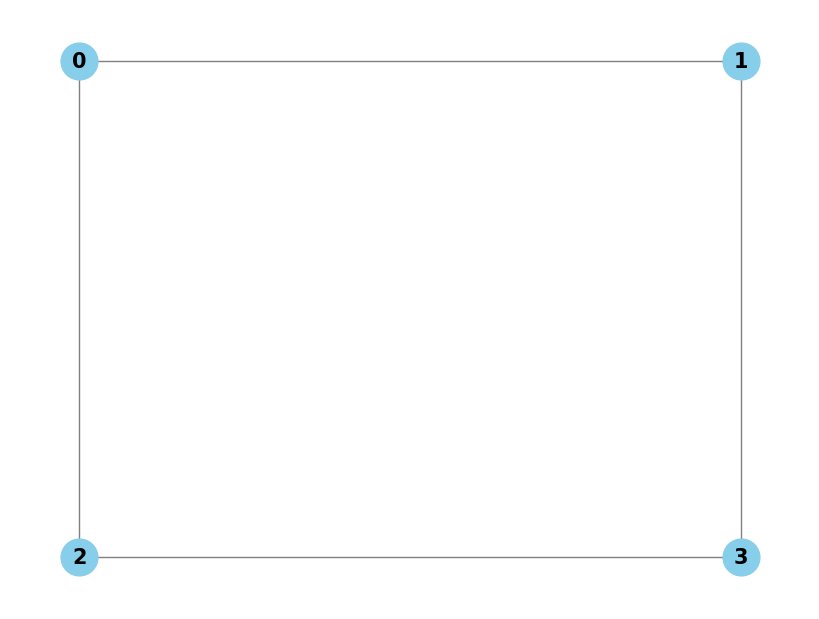

None


Matchings: 2
Matchings: [{('01', '11'), ('00', '10')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 4, Per Edge = 1.000

Sample Circuit - Matching (n_steps=1):


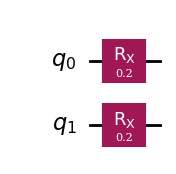


Gate Count Summary (U3/CX) for Cycle Graph C4:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            2/0         2/0            2/0         2/0
       2            4/0         2/0            4/0         2/0
       5           10/0         2/0           10/0         2/0
      10           20/0         2/0           20/0         2/0
      20           40/0         2/0           40/0         2/0
      50          100/0         2/0          100/0         2/0
     100          200/0         2/0          200/0         2/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cycle_graph_c4_error_analysis.pdf


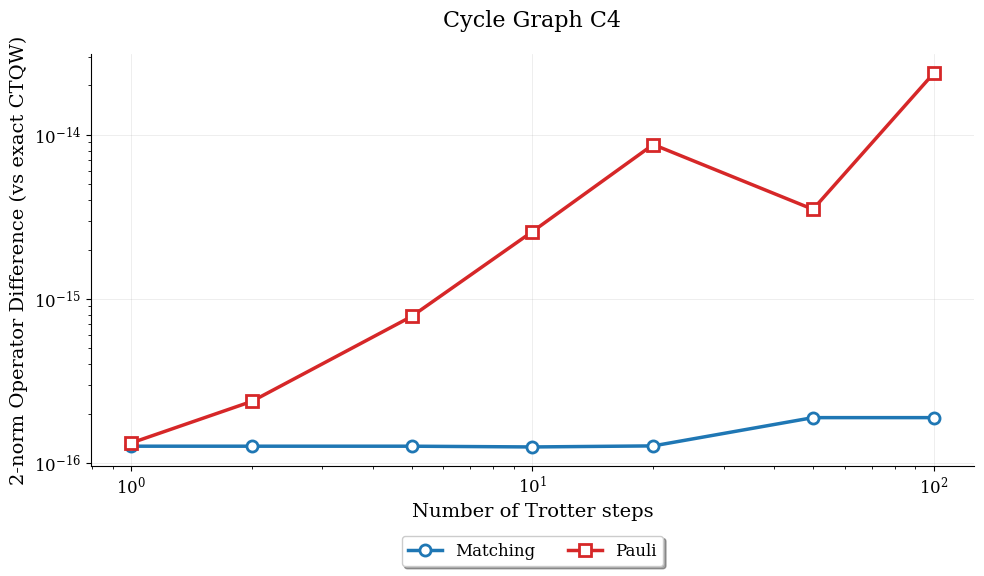

In [4]:
edges = {('00', '10'), ('01', '11'), ('10', '11'), ('00', '01')}
analyze_and_plot(edges, "Cycle Graph C4")


Complete Graph K4 - C2
Original edges: {('01', '11'), ('00', '10'), ('01', '10'), ('00', '11'), ('00', '01')}
Number of qubits: 2

Graph:


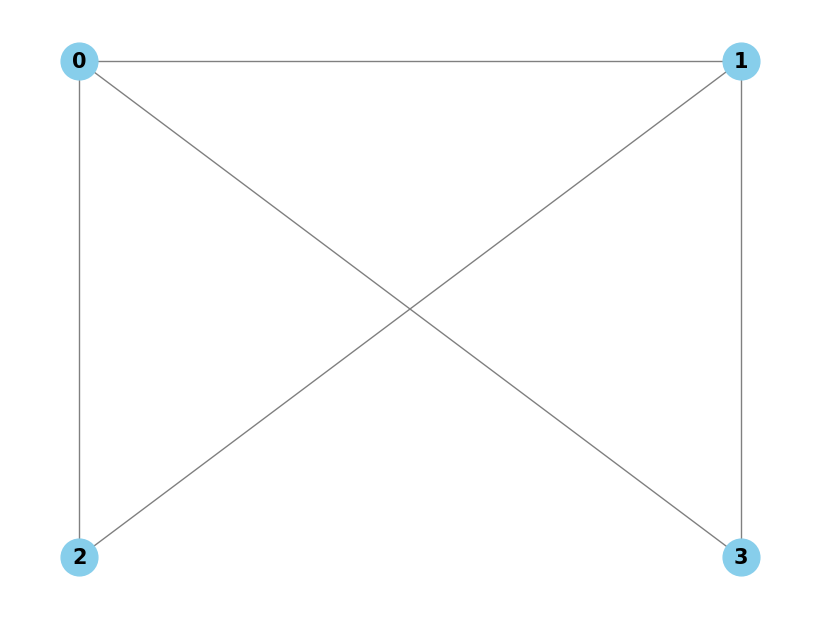

None


Matchings: 3
Matchings: [{('01', '11'), ('00', '10')}, {('01', '10'), ('00', '11')}, {('00', '01')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 7, Edges = 5, Per Edge = 1.400

Sample Circuit - Matching (n_steps=1):


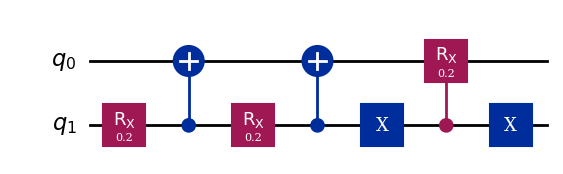


Gate Count Summary (U3/CX) for Complete Graph K4 - C2:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            7/4         6/2           10/4         6/2
       2           14/8         6/2           20/8         6/2
       5          35/20         6/2          50/20         6/2
      10          70/40         6/2         100/40         6/2
      20         140/80         6/2         200/80         6/2
      50        350/200         6/2        500/200         6/2
     100        700/400         6/2       1000/400         6/2

Hamming cost/edge: 1.400
Error plot saved as: trotterization_plots/complete_graph_k4_c2_error_analysis.pdf


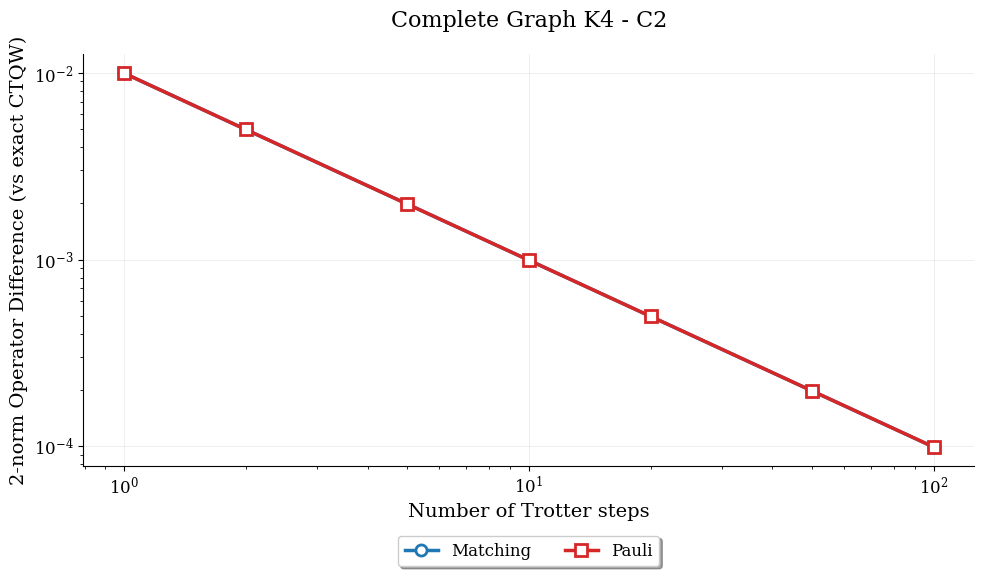

In [5]:
edges = {('00', '11'), ('01', '10'), ('00', '10'), ('01', '11'), ('00', '01')}
analyze_and_plot(edges, "Complete Graph K4 - C2")


Path Graph P3
Original edges: {('01', '10'), ('00', '01'), ('10', '11')}
Number of qubits: 2

Graph:


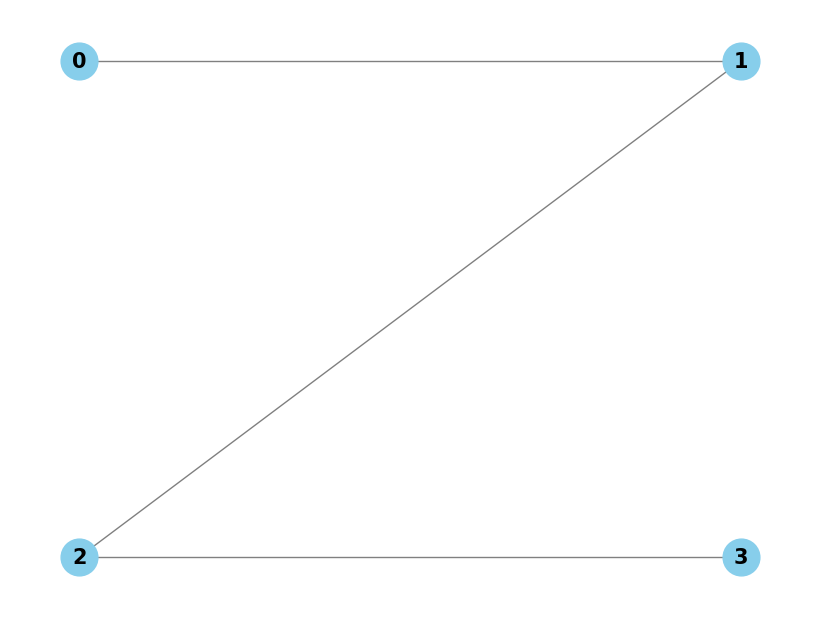

None


Matchings: 2
Matchings: [{('01', '10')}, {('00', '01'), ('10', '11')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 3, Per Edge = 1.333

Sample Circuit - Matching (n_steps=1):


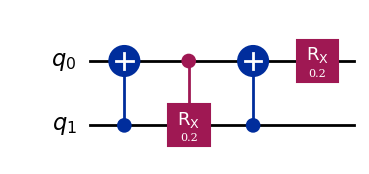


Gate Count Summary (U3/CX) for Path Graph P3:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            4/4         6/2           11/4         6/2
       2            8/8         6/2           22/8         6/2
       5          20/20         6/2          55/20         6/2
      10          40/40         6/2         110/40         6/2
      20          80/80         6/2         220/80         6/2
      50        200/200         6/2        550/200         6/2
     100        400/400         6/2       1100/400         6/2

Hamming cost/edge: 1.333
Error plot saved as: trotterization_plots/path_graph_p3_error_analysis.pdf


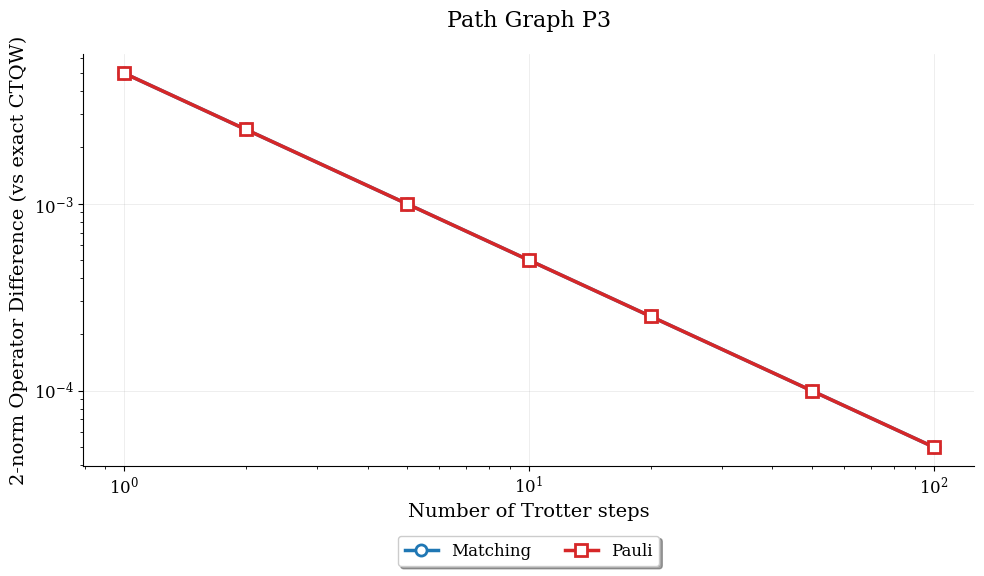

In [6]:
edges = {('00', '01'), ('01', '10'), ('10', '11')}
analyze_and_plot(edges, "Path Graph P3")


Tree Graph (2 qubits)
Original edges: {('00', '11'), ('00', '01'), ('00', '10')}
Number of qubits: 2

Graph:


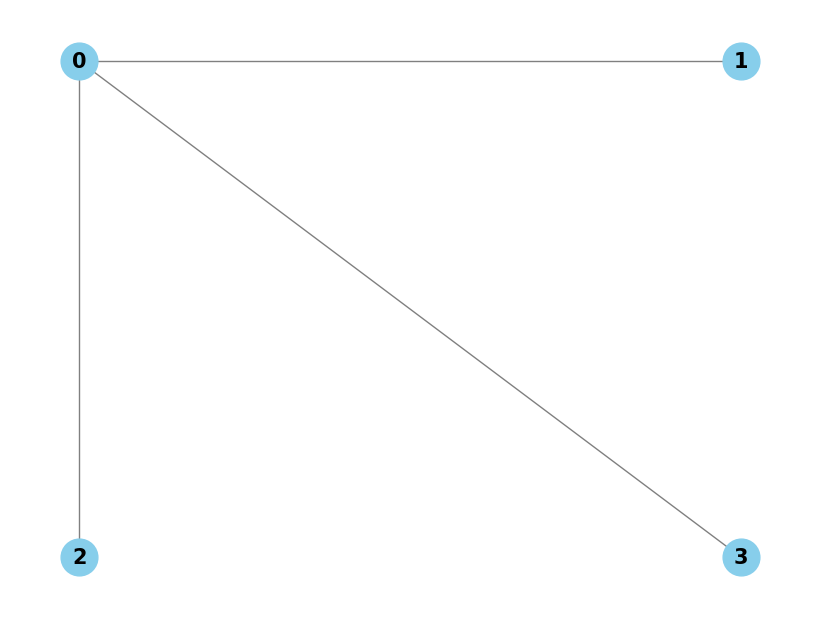

None


Matchings: 3
Matchings: [{('00', '11')}, {('00', '01')}, {('00', '10')}]
Number of qubits: 2

Hamming Cost Analysis:
Total = 4, Edges = 3, Per Edge = 1.333

Sample Circuit - Matching (n_steps=1):


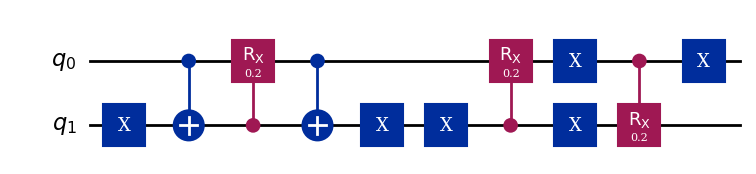


Gate Count Summary (U3/CX) for Tree Graph (2 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1           15/8         8/3           18/8         8/3
       2          30/16         8/3          36/16         8/3
       5          75/40         8/3          90/40         8/3
      10         150/80         8/3         180/80         8/3
      20        300/160         8/3        360/160         8/3
      50        750/400         8/3        900/400         8/3
     100       1500/800         8/3       1800/800         8/3

Hamming cost/edge: 1.333
Error plot saved as: trotterization_plots/tree_graph_2_qubits_error_analysis.pdf


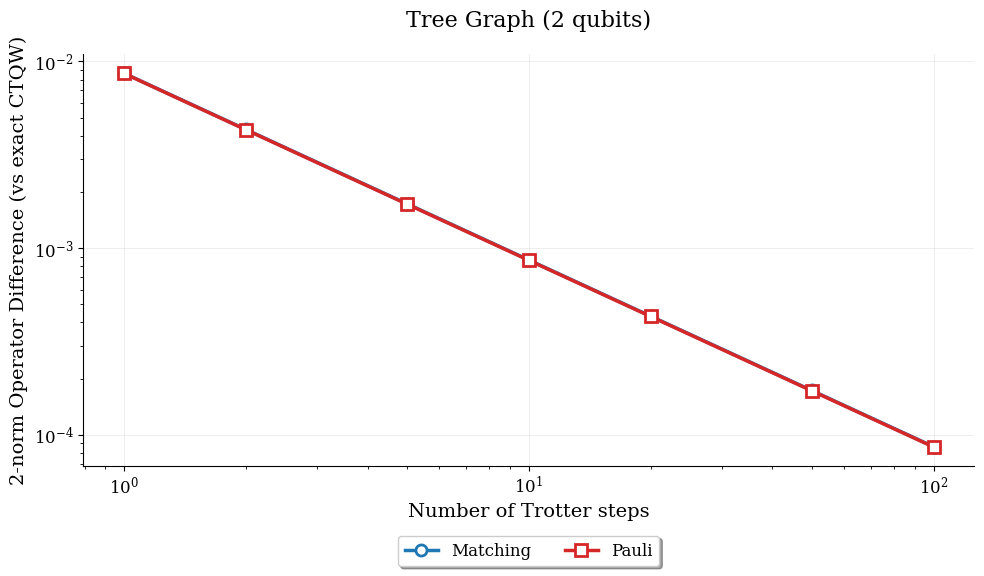

In [7]:
edges = {('00','01'), ('00','10'), ('00','11')}
analyze_and_plot(edges, "Tree Graph (2 qubits)")


Tree Graph (3 qubits)
Original edges: {('000', '011'), ('000', '101'), ('000', '010'), ('000', '111'), ('000', '110'), ('000', '100'), ('000', '001')}
Number of qubits: 3

Graph:


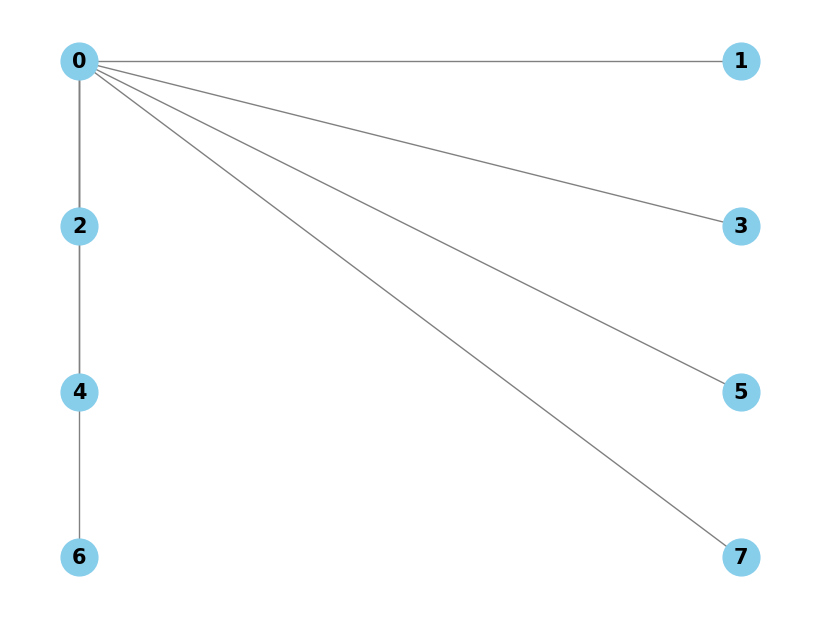

None


Matchings: 7
Matchings: [{('000', '011')}, {('000', '101')}, {('000', '111')}, {('000', '110')}, {('000', '010')}, {('000', '100')}, {('000', '001')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 12, Edges = 7, Per Edge = 1.714

Sample Circuit - Matching (n_steps=1):


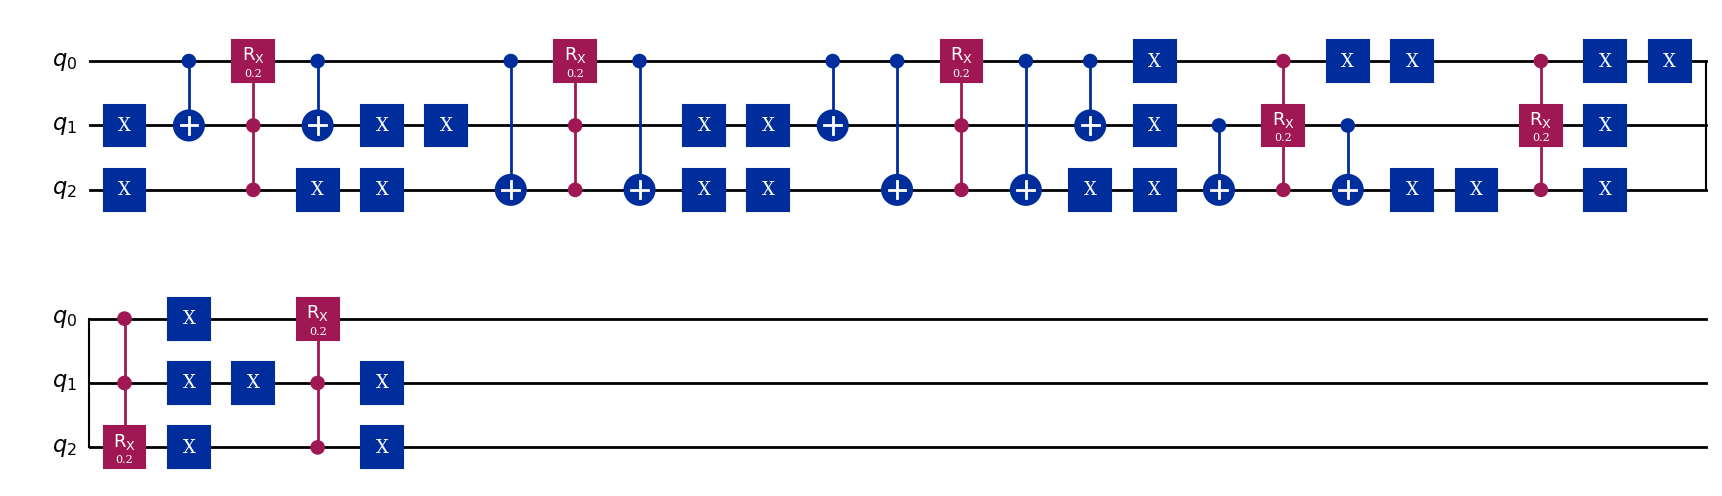


Gate Count Summary (U3/CX) for Tree Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         133/66       66/57         118/76       55/30
       2        266/132     130/113        236/152      109/60
       5        665/330     322/281        590/380     271/150
      10       1330/660     642/561       1180/760     541/300
      20      2660/1320   1282/1121      2360/1520    1081/600
      50      6650/3300   3202/2801      5900/3800   2651/1500
     100     13300/6600   6402/5601     11800/7600   5401/3000

Hamming cost/edge: 1.714
Error plot saved as: trotterization_plots/tree_graph_3_qubits_error_analysis.pdf


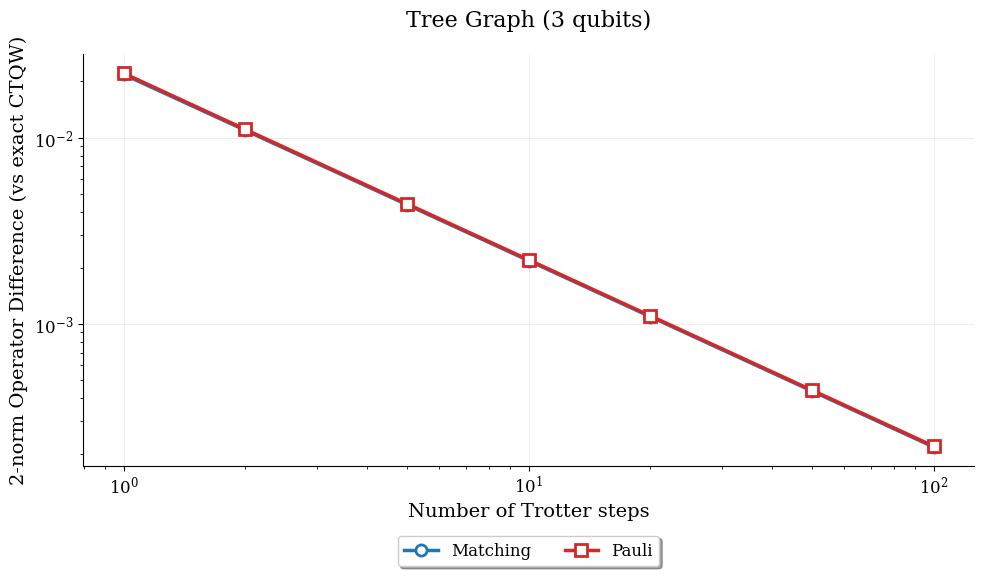

In [8]:
edges = {('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'), ('000','111')}
analyze_and_plot(edges, "Tree Graph (3 qubits)")


Dense Non-Bipartite Graph (3 qubits)
Original edges: {('000', '110'), ('011', '101'), ('100', '111'), ('010', '111'), ('001', '100'), ('100', '101'), ('000', '100'), ('101', '111'), ('001', '011'), ('000', '001'), ('001', '111'), ('001', '010'), ('000', '011'), ('011', '100'), ('100', '110'), ('000', '010'), ('010', '110'), ('110', '111'), ('001', '101'), ('011', '111'), ('000', '101'), ('101', '110'), ('010', '100'), ('010', '011')}
Number of qubits: 3

Graph:


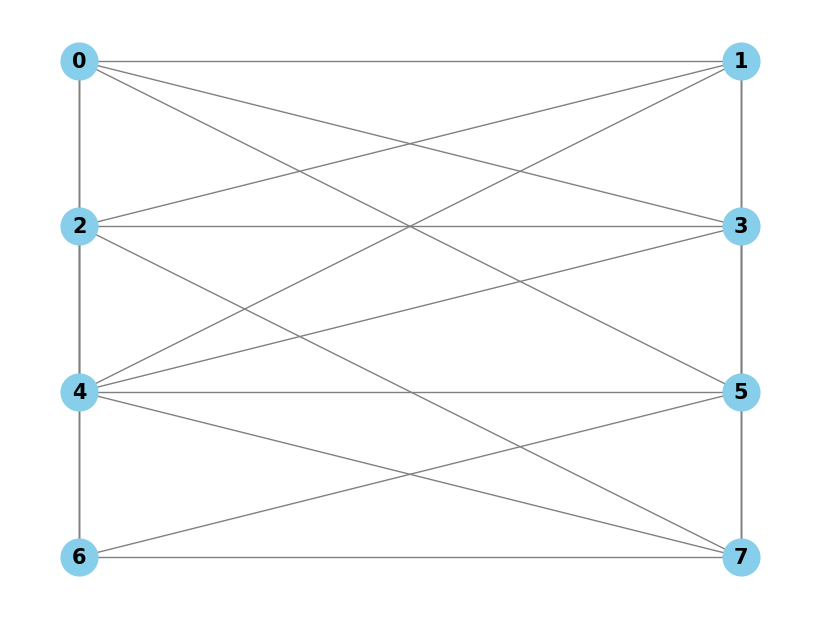

None


Matchings: 7
Matchings: [{('011', '101'), ('100', '111'), ('001', '010'), ('000', '110')}, {('001', '100'), ('101', '110'), ('010', '111'), ('000', '011')}, {('011', '100'), ('000', '101'), ('001', '111')}, {('010', '100')}, {('010', '011'), ('110', '111'), ('000', '001'), ('100', '101')}, {('011', '111'), ('010', '110'), ('001', '101'), ('000', '100')}, {('000', '010'), ('101', '111'), ('100', '110'), ('001', '011')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 37, Edges = 24, Per Edge = 1.542

Sample Circuit - Matching (n_steps=1):


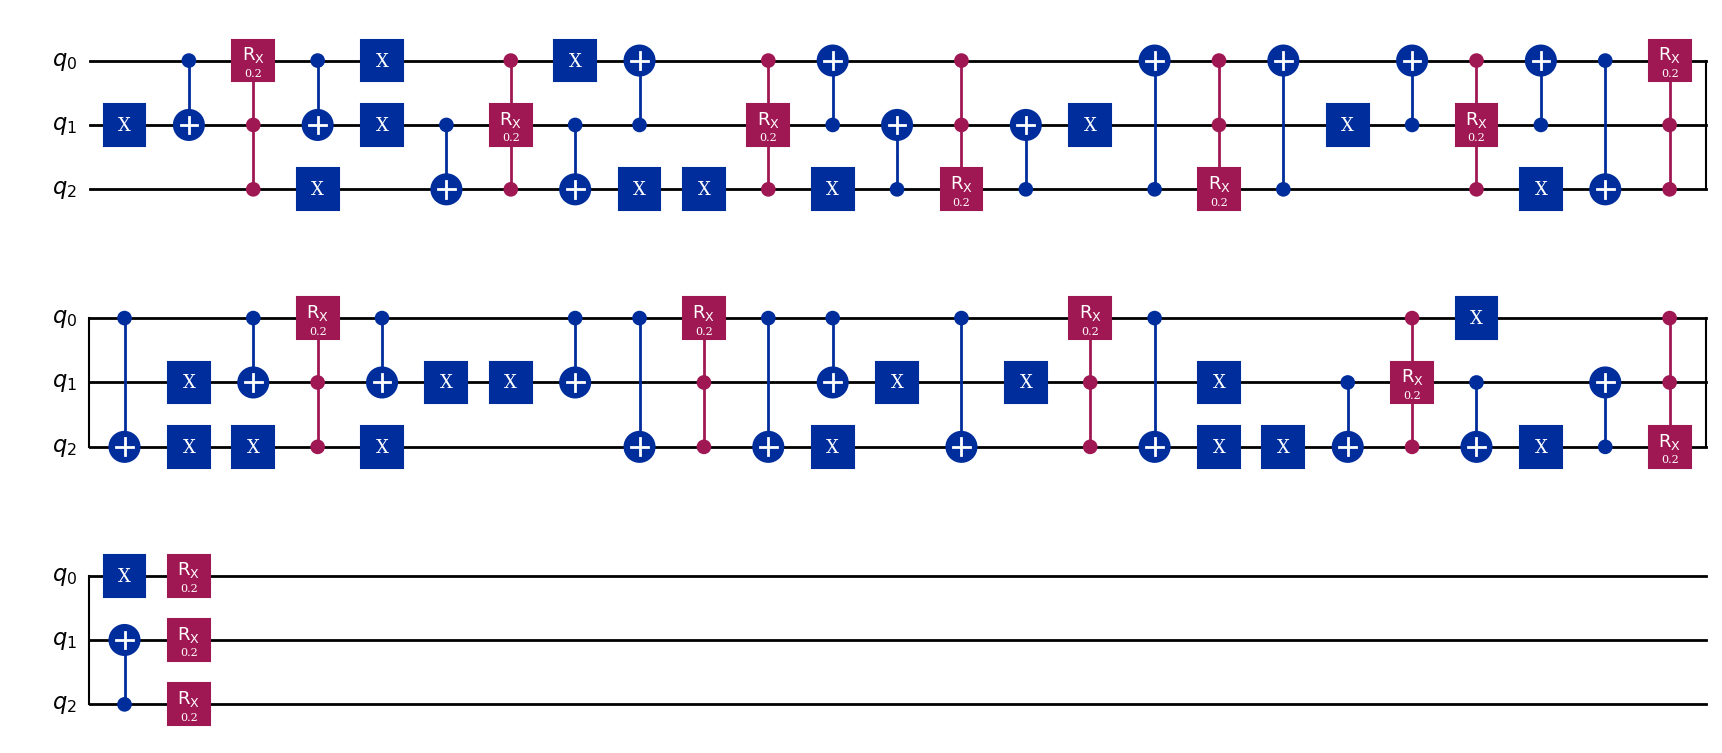


Gate Count Summary (U3/CX) for Dense Non-Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        209/122     122/107          61/32       32/20
       2        418/244     243/214         122/64       60/40
       5       1045/610     611/535        305/160     147/100
      10      2090/1220   1221/1070        610/320     292/200
      20      4180/2440   2421/2140       1220/640     582/400
      50     10450/6100   6051/5350      3050/1600   1502/1000
     100    20900/12200 12101/10700      6100/3200   3002/2000

Hamming cost/edge: 1.542
Error plot saved as: trotterization_plots/dense_non_bipartite_graph_3_qubits_error_analysis.pdf


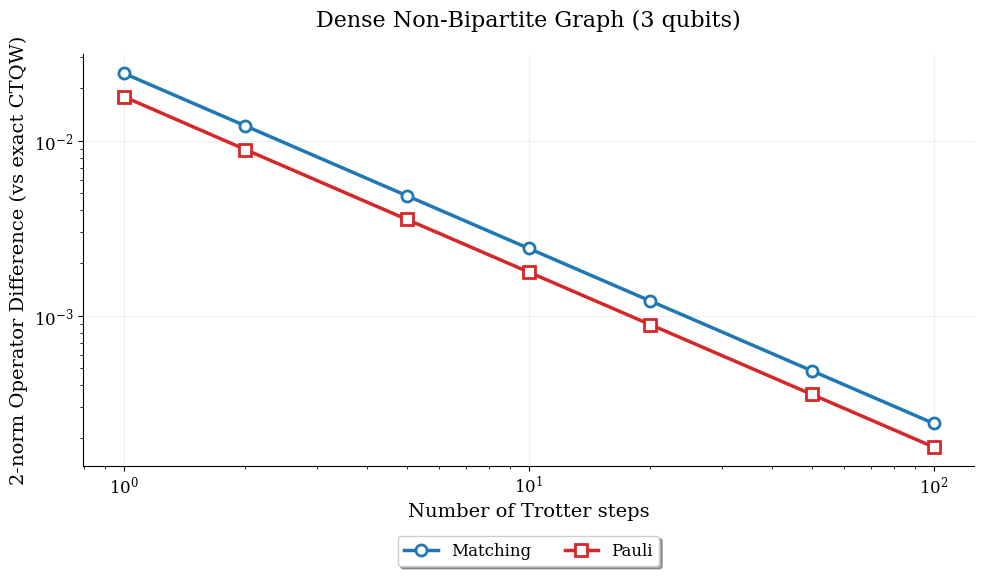

In [9]:
dense_nonbipartite_8 = {
    ('000','001'), ('000','010'), ('000','011'), ('000','100'), ('000','101'), ('000','110'),
    ('001','010'), ('001','011'), ('001','100'), ('001','101'), ('001','111'),
    ('010','011'), ('010','100'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','111'),
    ('100','101'), ('100','110'), ('100','111'),
    ('101','110'), ('101','111'),
    ('110','111')
}

analyze_and_plot(dense_nonbipartite_8, "Dense Non-Bipartite Graph (3 qubits)")


Dense Bipartite Graph (3 qubits)
Original edges: {('011', '101'), ('000', '110'), ('010', '111'), ('001', '100'), ('011', '110'), ('000', '100'), ('010', '101'), ('001', '111'), ('011', '100'), ('010', '110'), ('000', '111'), ('001', '101'), ('011', '111'), ('000', '101'), ('010', '100'), ('001', '110')}
Number of qubits: 3

Graph:


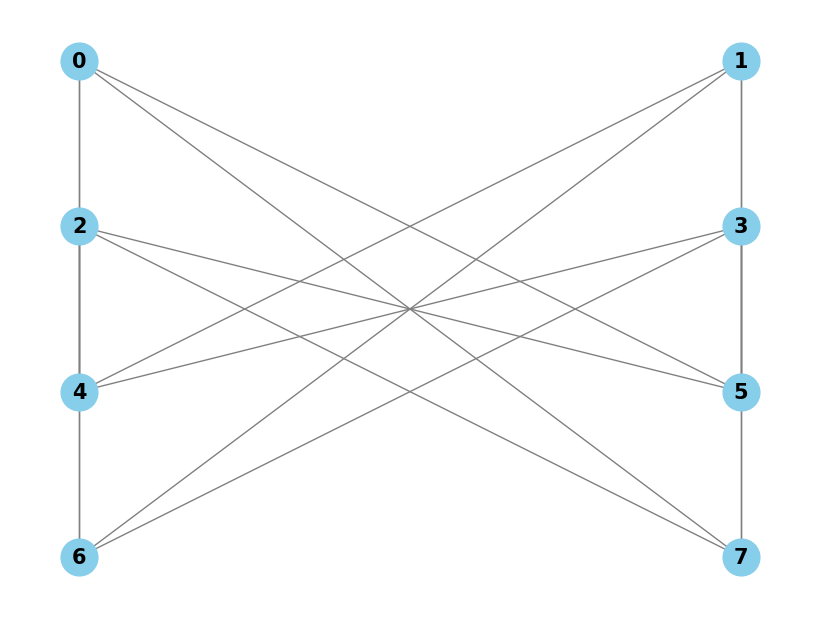

None


Matchings: 4
Matchings: [{('011', '111'), ('101', '001'), ('110', '010'), ('000', '100')}, {('001', '100'), ('011', '110'), ('101', '000'), ('010', '111')}, {('111', '001'), ('011', '101'), ('000', '110'), ('010', '100')}, {('101', '010'), ('110', '001'), ('000', '111'), ('011', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 32, Edges = 16, Per Edge = 2.000

Sample Circuit - Matching (n_steps=1):


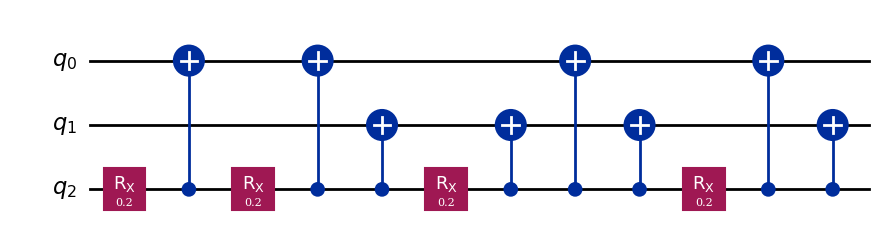


Gate Count Summary (U3/CX) for Dense Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            4/8         4/6           18/8        11/6
       2           8/16        8/12          36/16       17/12
       5          20/40       20/30          90/40       38/30
      10          40/80       40/60         180/80       73/60
      20         80/160      80/120        360/160     143/120
      50        200/400     200/300        900/400     354/300
     100        400/800     400/600       1800/800     704/600

Hamming cost/edge: 2.000
Error plot saved as: trotterization_plots/dense_bipartite_graph_3_qubits_error_analysis.pdf


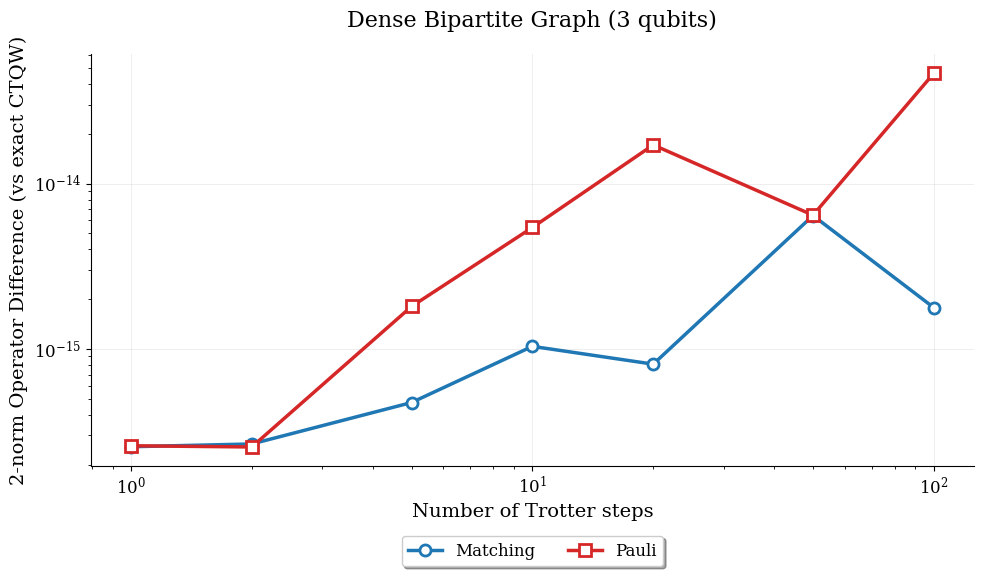

In [10]:
dense_bipartite_8 = {
    ('000','100'), ('000','101'), ('000','110'), ('000','111'),
    ('001','100'), ('001','101'), ('001','110'), ('001','111'),
    ('010','100'), ('010','101'), ('010','110'), ('010','111'),
    ('011','100'), ('011','101'), ('011','110'), ('011','111')  
}
analyze_and_plot(dense_bipartite_8, "Dense Bipartite Graph (3 qubits)")


Sparse Non-Bipartite Graph (3 qubits)
Original edges: {('110', '101'), ('110', '111'), ('100', '101'), ('100', '011'), ('000', '001'), ('010', '011')}
Number of qubits: 3

Graph:


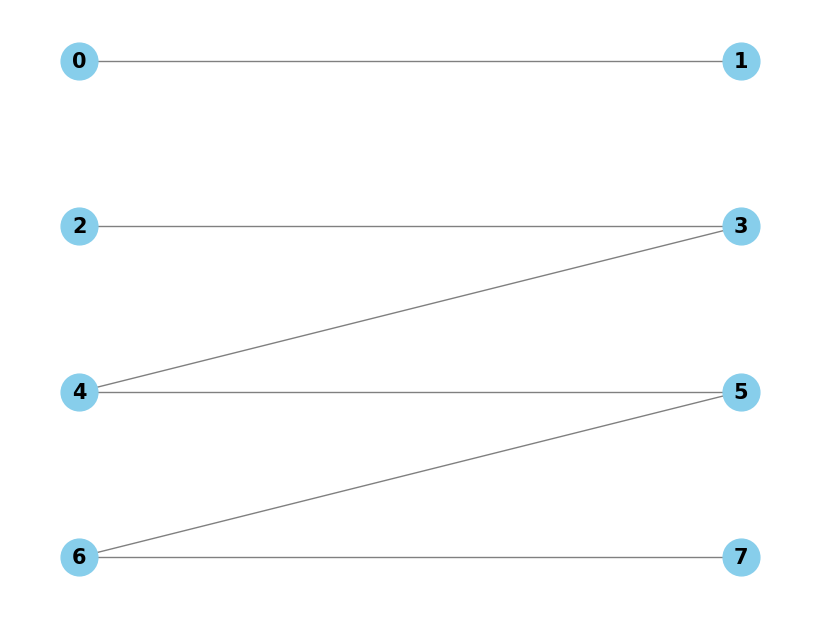

None


Matchings: 2
Matchings: [{('110', '101'), ('100', '011')}, {('010', '011'), ('110', '111'), ('000', '001'), ('100', '101')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 9, Edges = 6, Per Edge = 1.500

Sample Circuit - Matching (n_steps=1):


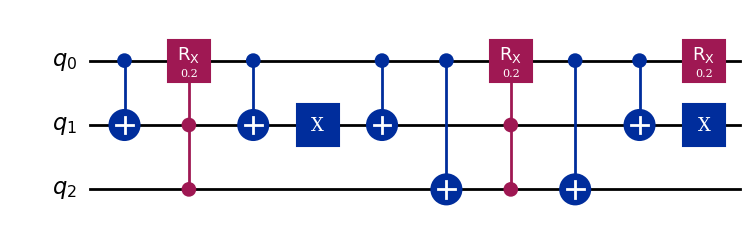


Gate Count Summary (U3/CX) for Sparse Non-Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          33/22       19/19          49/28       34/23
       2          66/44       38/38          98/56       66/46
       5        165/110       95/95        245/140     162/115
      10        330/220     190/190        490/280     322/230
      20        660/440     380/380        980/560     642/460
      50      1650/1100     950/950      2450/1400   1602/1150
     100      3300/2200   1900/1900      4900/2800   3202/2300

Hamming cost/edge: 1.500
Error plot saved as: trotterization_plots/sparse_non_bipartite_graph_3_qubits_error_analysis.pdf


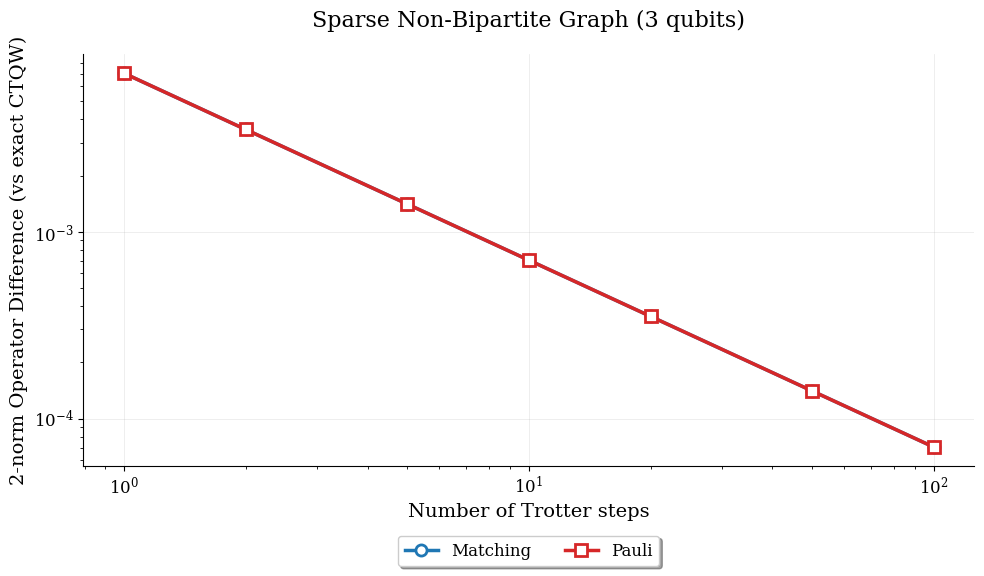

In [11]:
sparse_nonbipartite_8 = {
    ('000','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}
analyze_and_plot(sparse_nonbipartite_8, "Sparse Non-Bipartite Graph (3 qubits)")


Sparse Bipartite Graph (3 qubits)
Original edges: {('110', '101'), ('110', '111'), ('100', '101'), ('000', '001'), ('010', '001'), ('100', '011'), ('010', '011')}
Number of qubits: 3

Graph:


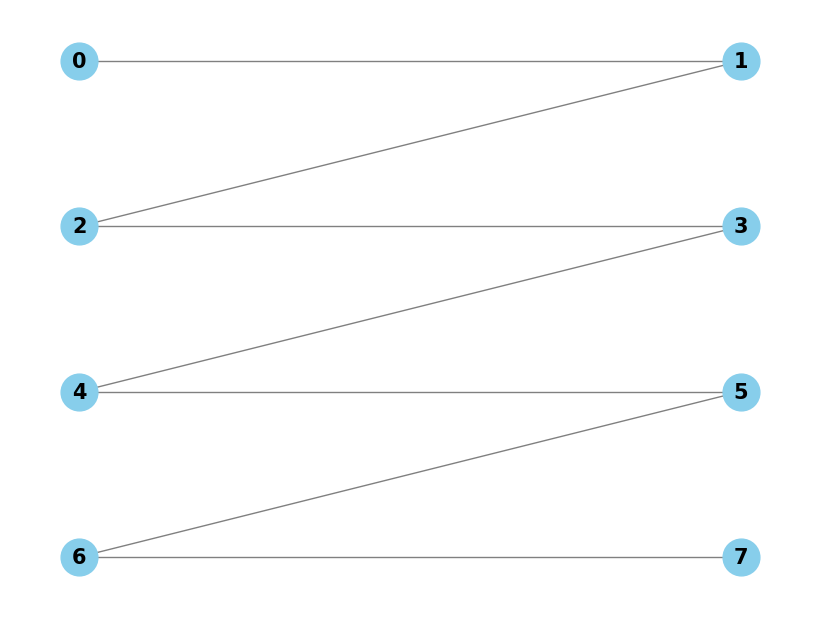

None


Matchings: 2
Matchings: [{('110', '101'), ('010', '001'), ('100', '011')}, {('010', '011'), ('110', '111'), ('000', '001'), ('100', '101')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 11, Edges = 7, Per Edge = 1.571

Sample Circuit - Matching (n_steps=1):


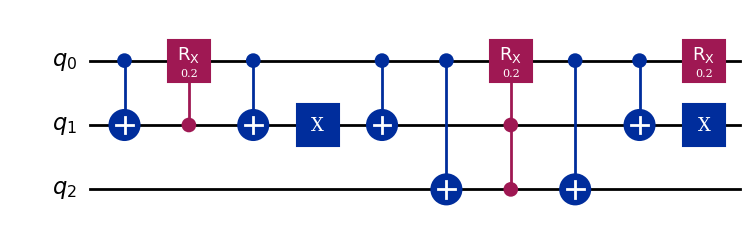


Gate Count Summary (U3/CX) for Sparse Bipartite Graph (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          21/16       17/12          39/20       26/16
       2          42/32       32/23          78/40       49/32
       5         105/80       77/56        195/100      118/80
      10        210/160     152/111        390/200     233/160
      20        420/320     302/221        780/400     463/320
      50       1050/800     752/551      1950/1000    1153/800
     100      2100/1600   1502/1101      3900/2000   2303/1600

Hamming cost/edge: 1.571
Error plot saved as: trotterization_plots/sparse_bipartite_graph_3_qubits_error_analysis.pdf


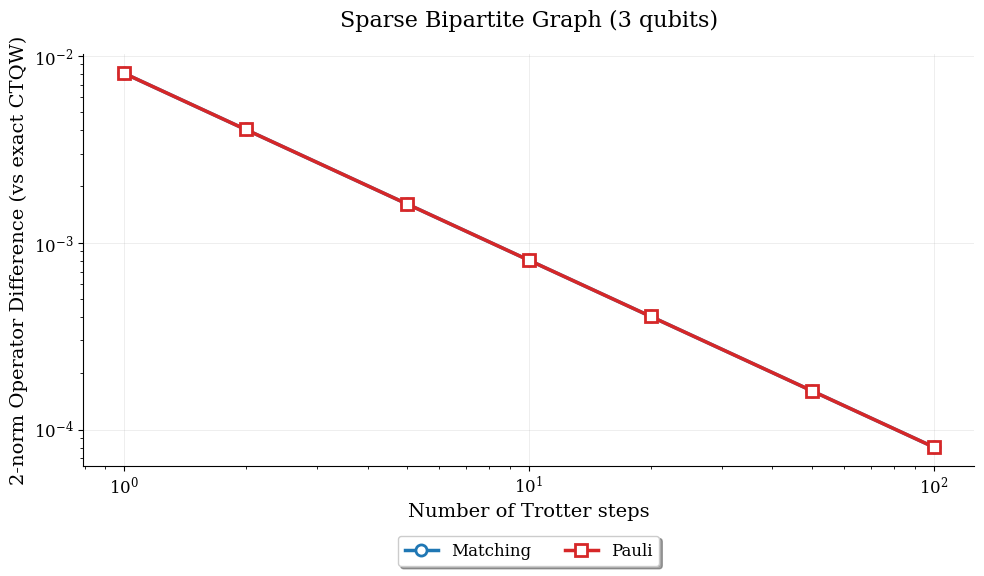

In [12]:
sparse_bipartite_8 = {
    ('000','001'), ('010','001'), ('010','011'), ('100','011'), ('100','101'), ('110','101'), ('110','111')
}

analyze_and_plot(sparse_bipartite_8, "Sparse Bipartite Graph (3 qubits)")


Dense Non-Bipartite Graph (4 qubits)
Original edges: {('1101', '1111'), ('0100', '0101'), ('1100', '1111'), ('0110', '1010'), ('0000', '0110'), ('0101', '0111'), ('1001', '1010'), ('1100', '1101'), ('0010', '0110'), ('0100', '1000'), ('0111', '1011'), ('0101', '1001'), ('1011', '1100'), ('0010', '1010'), ('0101', '1011'), ('0001', '0101'), ('0111', '1111'), ('0100', '0110'), ('1010', '1100'), ('0001', '0100'), ('0001', '1001'), ('0110', '1100'), ('0111', '1101'), ('0000', '0010'), ('1001', '1110'), ('1010', '1110'), ('0000', '0001'), ('0001', '0011'), ('0110', '1110'), ('1110', '1111'), ('0110', '0111'), ('0101', '0110'), ('0101', '1101'), ('1000', '1010'), ('0001', '1000'), ('1011', '1111'), ('1010', '1011'), ('1011', '1101'), ('1001', '1011'), ('0100', '1010'), ('1010', '1111'), ('0010', '0100'), ('1000', '1100'), ('1101', '1110'), ('0010', '0011'), ('1001', '1101'), ('1100', '1110'), ('0000', '0111'), ('0011', '0111'), ('0000', '0101'), ('0010', '1000'), ('0011', '0101'), ('0001', 

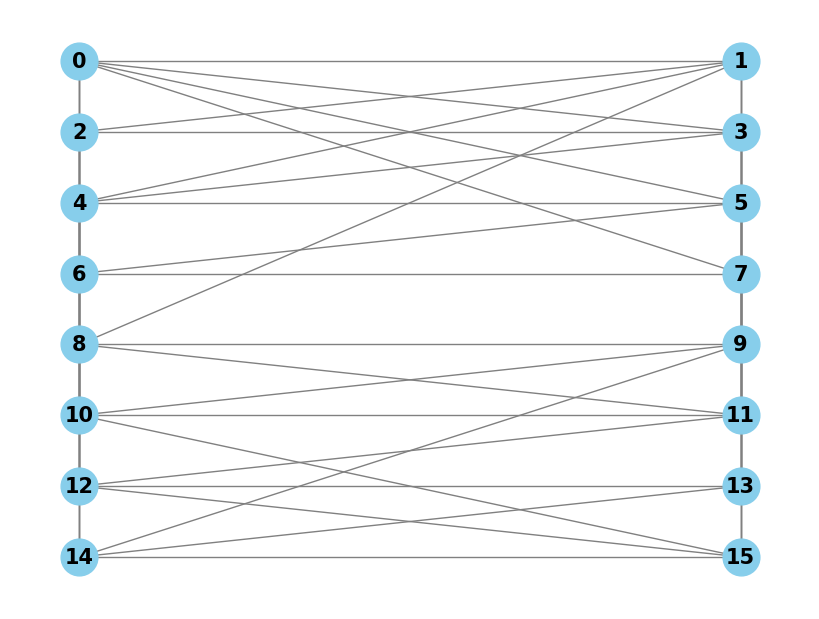

None


Matchings: 9
Matchings: [{('1100', '1110'), ('1101', '1111'), ('0100', '0110'), ('1001', '1011'), ('0101', '0111'), ('0000', '0010'), ('0001', '0011'), ('1000', '1010')}, {('0010', '0011'), ('0100', '0101'), ('1010', '1011'), ('1100', '1101'), ('1000', '1001'), ('0000', '0001'), ('1110', '1111'), ('0110', '0111')}, {('1101', '1110'), ('1100', '1111'), ('0110', '1010'), ('0001', '0010'), ('0000', '0011'), ('0100', '1000'), ('0111', '1011'), ('0101', '1001')}, {('0010', '1000'), ('0011', '0101'), ('0001', '0100'), ('0111', '1101'), ('0000', '0110'), ('1001', '1010'), ('1011', '1100')}, {('0101', '1011'), ('0001', '1000'), ('0000', '0111'), ('1010', '1100'), ('1001', '1110'), ('0010', '0100')}, {('0000', '0101'), ('1011', '1101'), ('0110', '1100'), ('0011', '1001'), ('0100', '1010')}, {('0011', '0100'), ('1000', '1011'), ('1010', '1111'), ('0101', '0110')}, {('1001', '1101'), ('0011', '0111'), ('0001', '0101'), ('1011', '1111'), ('0000', '0100'), ('1010', '1110'), ('0010', '0110'), ('100

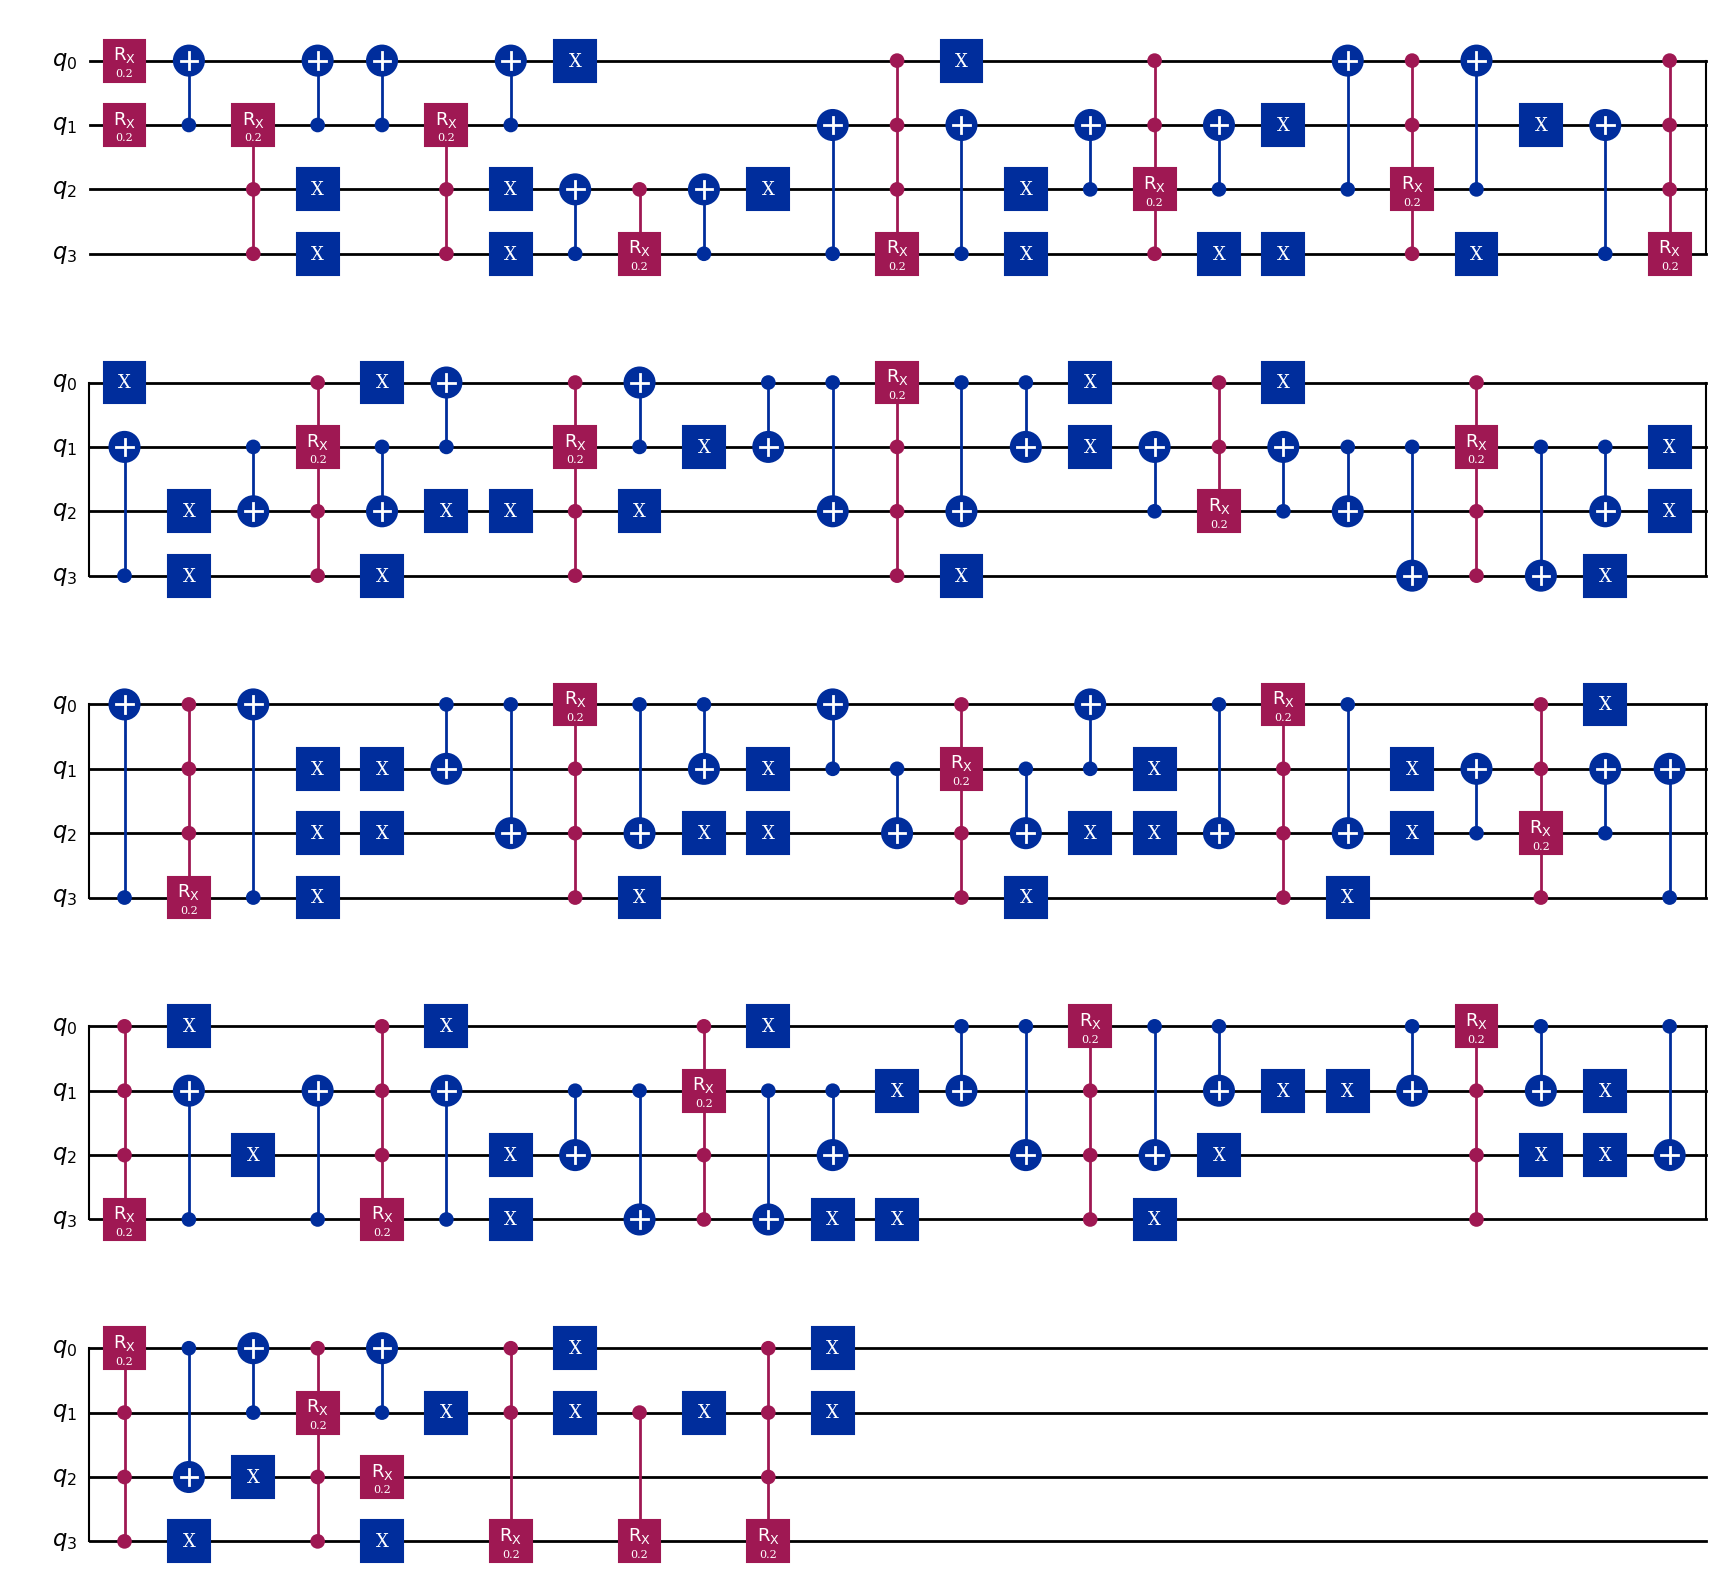


Gate Count Summary (U3/CX) for Dense Non-Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        876/516     418/498        268/200     155/101
       2      1752/1032     834/996        536/400     310/202
       5      4380/2580   2082/2490      1340/1000     763/505
      10      8760/5160   4172/4980      2680/2000   1532/1010
      20    17520/10320   8342/9960      5360/4000   3062/2020
      50    43800/25800 20852/24900    13400/10000   7653/5050
     100    87600/51600 41702/49800    26800/20000 15203/10100

Hamming cost/edge: 1.590
Error plot saved as: trotterization_plots/dense_non_bipartite_graph_4_qubits_error_analysis.pdf


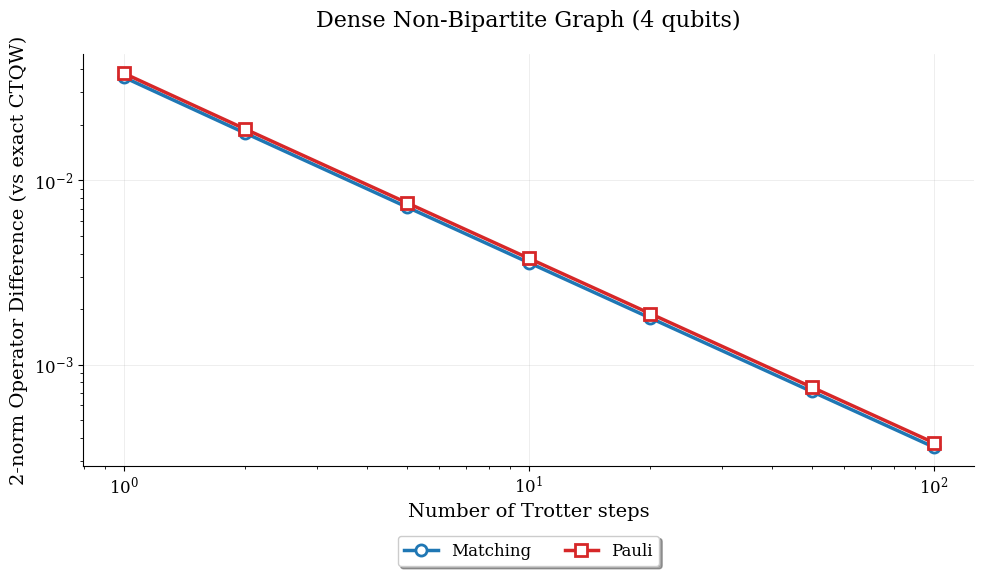

In [13]:
dense_nonbipartite_16 = {
    ('0000','0001'), ('0000','0010'), ('0000','0011'), ('0000','0100'), ('0000','0101'), ('0000','0110'), ('0000','0111'),
    ('0001','0010'), ('0001','0011'), ('0001','0100'), ('0001','0101'), ('0001','1000'), ('0001','1001'),
    ('0010','0011'), ('0010','0100'), ('0010','0110'), ('0010','1000'), ('0010','1010'),
    ('0011','0100'), ('0011','0101'), ('0011','0111'), ('0011','1001'), ('0011','1011'),
    ('0100','0101'), ('0100','0110'), ('0100','1000'), ('0100','1010'), ('0100','1100'),
    ('0101','0110'), ('0101','0111'), ('0101','1001'), ('0101','1011'), ('0101','1101'),
    ('0110','0111'), ('0110','1010'), ('0110','1100'), ('0110','1110'),
    ('0111','1011'), ('0111','1101'), ('0111','1111'),
    ('1000','1001'), ('1000','1010'), ('1000','1011'), ('1000','1100'),
    ('1001','1010'), ('1001','1011'), ('1001','1101'), ('1001','1110'),
    ('1010','1011'), ('1010','1100'), ('1010','1110'), ('1010','1111'),
    ('1011','1100'), ('1011','1101'), ('1011','1111'),
    ('1100','1101'), ('1100','1110'), ('1100','1111'),
    ('1101','1110'), ('1101','1111'),
    ('1110','1111')
}
analyze_and_plot(dense_nonbipartite_16, "Dense Non-Bipartite Graph (4 qubits)")


Dense Bipartite Graph (4 qubits)
Original edges: {('0111', '1100'), ('0111', '1110'), ('0000', '1000'), ('0100', '1001'), ('0101', '1110'), ('0110', '1010'), ('0100', '1011'), ('0000', '1101'), ('0111', '1001'), ('0100', '1000'), ('0111', '1011'), ('0100', '1111'), ('0001', '1110'), ('0111', '1000'), ('0111', '1111'), ('0100', '1101'), ('0110', '1110'), ('0000', '1010'), ('0010', '1100'), ('0001', '1000'), ('0001', '1111'), ('0100', '1010'), ('0010', '1001'), ('0011', '1100'), ('0111', '1010'), ('0110', '1111'), ('0010', '1011'), ('0000', '1110'), ('0010', '1000'), ('0010', '1111'), ('0011', '1001'), ('0011', '1011'), ('0010', '1101'), ('0100', '1110'), ('0011', '1000'), ('0011', '1111'), ('0101', '1100'), ('0000', '1111'), ('0011', '1101'), ('0001', '1100'), ('0101', '1001'), ('0010', '1010'), ('0101', '1011'), ('0101', '1000'), ('0001', '1001'), ('0101', '1111'), ('0110', '1100'), ('0111', '1101'), ('0001', '1011'), ('0011', '1010'), ('0101', '1101'), ('0110', '1001'), ('0010', '111

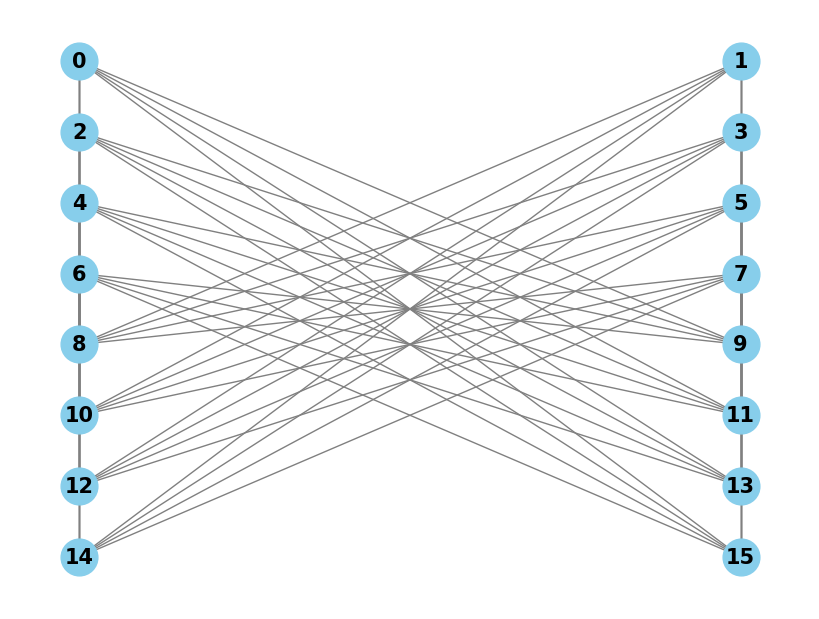

None


Matchings: 8
Matchings: [{('0000', '1000'), ('1001', '0001'), ('1110', '0110'), ('0111', '1111'), ('1100', '0100'), ('1010', '0010'), ('1011', '0011'), ('0101', '1101')}, {('0111', '1110'), ('0110', '1111'), ('1010', '0011'), ('1100', '0101'), ('0100', '1101'), ('1011', '0010'), ('1000', '0001'), ('0000', '1001')}, {('1110', '0100'), ('1000', '0010'), ('0101', '1111'), ('0111', '1101'), ('1001', '0011'), ('1011', '0001'), ('1100', '0110'), ('0000', '1010')}, {('0111', '1100'), ('1110', '0101'), ('1001', '0010'), ('0110', '1101'), ('0000', '1011'), ('1000', '0011'), ('0100', '1111'), ('1010', '0001')}, {('1110', '0010'), ('1001', '0101'), ('1100', '0000'), ('1000', '0100'), ('1101', '0001'), ('0110', '1010'), ('1111', '0011'), ('0111', '1011')}, {('1111', '0010'), ('0100', '1001'), ('1000', '0101'), ('0110', '1011'), ('1110', '0011'), ('0000', '1101'), ('1100', '0001'), ('0111', '1010')}, {('1110', '0000'), ('0101', '1011'), ('1111', '0001'), ('1100', '0010'), ('0100', '1010'), ('1000'

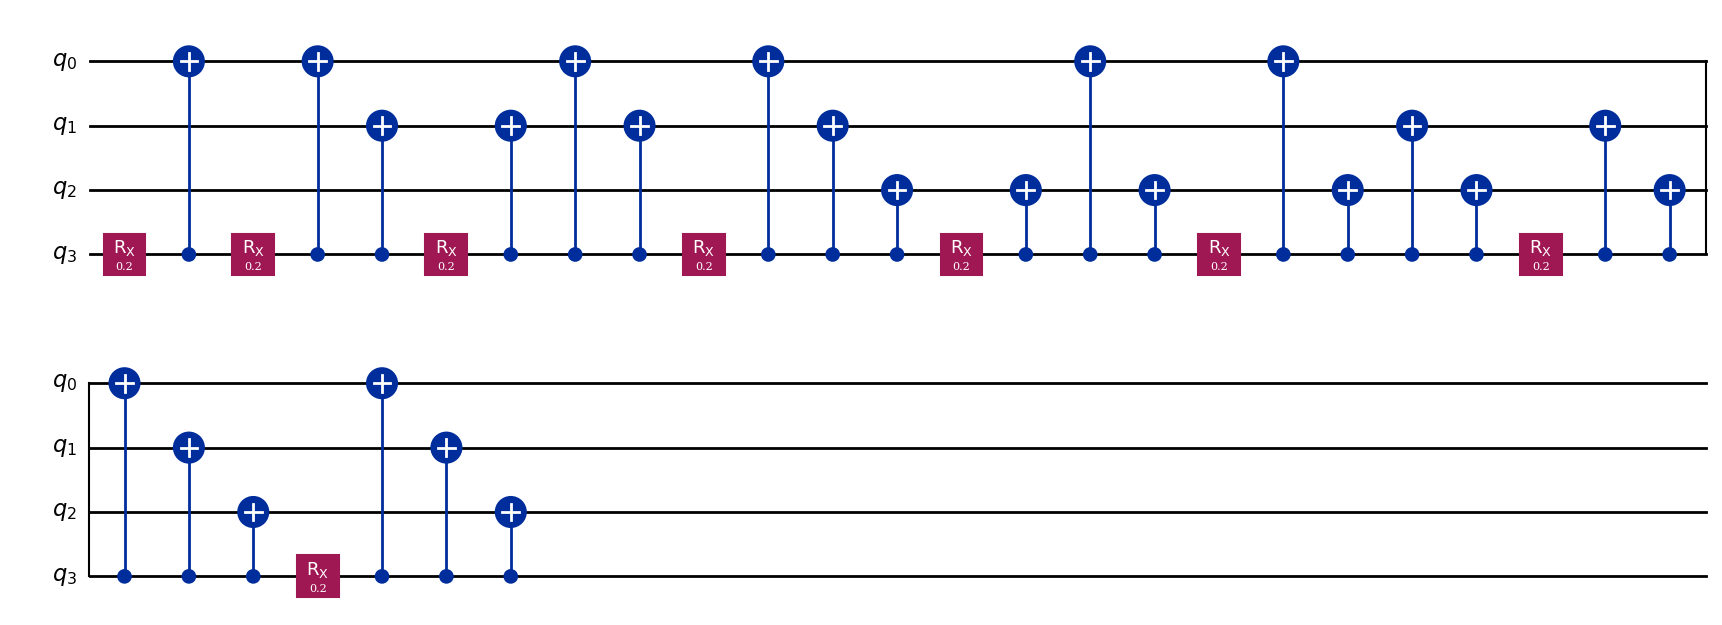


Gate Count Summary (U3/CX) for Dense Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1           8/24        8/14          46/24       22/14
       2          16/48       16/28          92/48       37/28
       5         40/120       40/70        230/120       88/70
      10         80/240      80/140        460/240     173/140
      20        160/480     160/280        920/480     343/280
      50       400/1200     400/700      2300/1200     855/700
     100       800/2400    800/1400      4600/2400   1705/1400

Hamming cost/edge: 2.500
Error plot saved as: trotterization_plots/dense_bipartite_graph_4_qubits_error_analysis.pdf


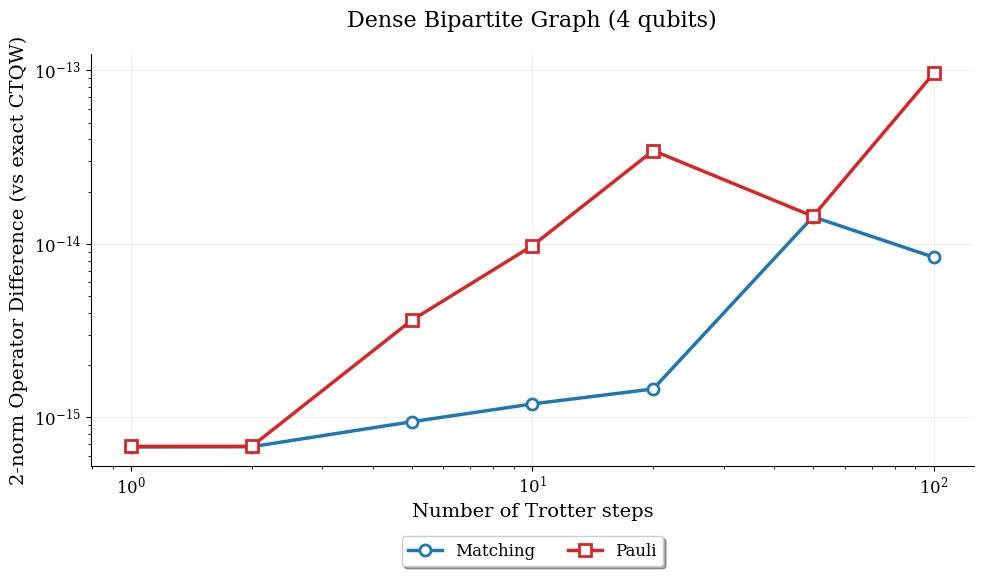

In [14]:
dense_bipartite_16 = {
    ('0000','1000'), ('0000','1001'), ('0000','1010'), ('0000','1011'), ('0000','1100'), ('0000','1101'), ('0000','1110'), ('0000','1111'),
    ('0001','1000'), ('0001','1001'), ('0001','1010'), ('0001','1011'), ('0001','1100'), ('0001','1101'), ('0001','1110'), ('0001','1111'),
    ('0010','1000'), ('0010','1001'), ('0010','1010'), ('0010','1011'), ('0010','1100'), ('0010','1101'), ('0010','1110'), ('0010','1111'),
    ('0011','1000'), ('0011','1001'), ('0011','1010'), ('0011','1011'), ('0011','1100'), ('0011','1101'), ('0011','1110'), ('0011','1111'),
    ('0100','1000'), ('0100','1001'), ('0100','1010'), ('0100','1011'), ('0100','1100'), ('0100','1101'), ('0100','1110'), ('0100','1111'),
    ('0101','1000'), ('0101','1001'), ('0101','1010'), ('0101','1011'), ('0101','1100'), ('0101','1101'), ('0101','1110'), ('0101','1111'),
    ('0110','1000'), ('0110','1001'), ('0110','1010'), ('0110','1011'), ('0110','1100'), ('0110','1101'), ('0110','1110'), ('0110','1111'),
    ('0111','1000'), ('0111','1001'), ('0111','1010'), ('0111','1011'), ('0111','1100'), ('0111','1101'), ('0111','1110'), ('0111','1111')
}

analyze_and_plot(dense_bipartite_16, "Dense Bipartite Graph (4 qubits)")


Sparse Non-Bipartite Graph (4 qubits)
Original edges: {('0000', '0100'), ('0010', '0011'), ('1010', '0101'), ('0111', '0110'), ('0001', '0011'), ('0010', '0110'), ('0001', '0100')}
Number of qubits: 4

Graph:


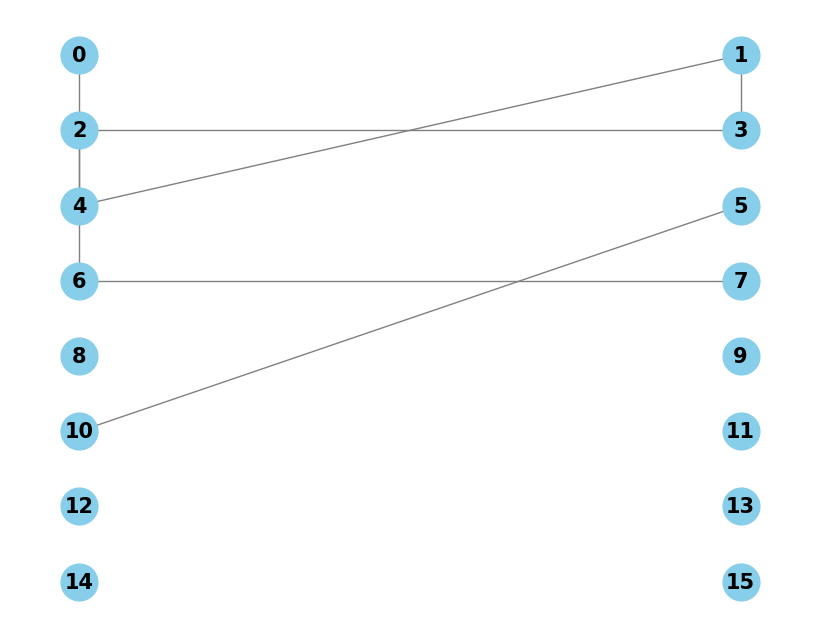

None


Matchings: 3
Matchings: [{('0000', '0100'), ('0010', '0110'), ('1010', '0101')}, {('0010', '0011'), ('0111', '0110'), ('0001', '0100')}, {('0001', '0011')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 11, Edges = 7, Per Edge = 1.571

Sample Circuit - Matching (n_steps=1):


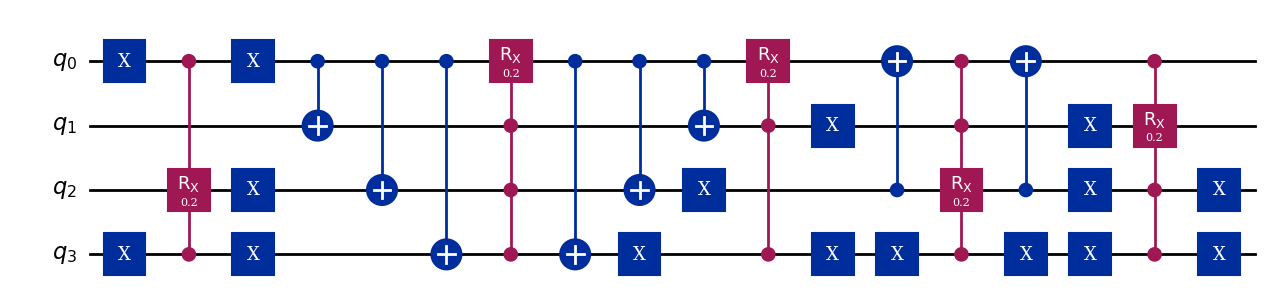


Gate Count Summary (U3/CX) for Sparse Non-Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         151/84       73/82        154/120      104/80
       2        302/168     143/164        308/240     205/160
       5        755/420     353/410        770/600     511/400
      10       1510/840     703/820      1540/1200    1031/800
      20      3020/1680   1403/1640      3080/2400   2061/1600
      50      7550/4200   3503/4100      7700/6000   5201/4000
     100     15100/8400   7003/8200    15400/12000  10201/8000

Hamming cost/edge: 1.571
Error plot saved as: trotterization_plots/sparse_non_bipartite_graph_4_qubits_error_analysis.pdf


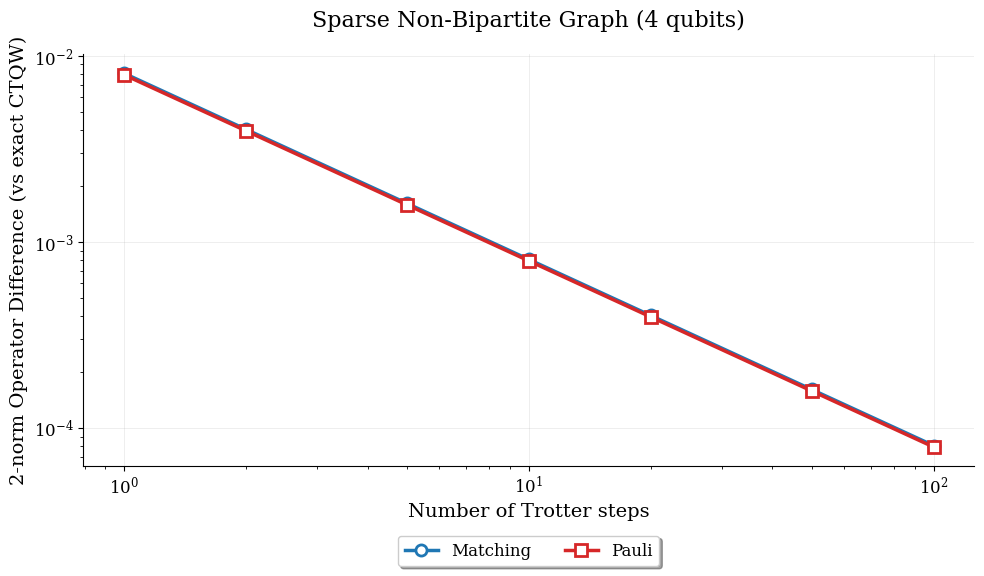

In [15]:
sparse_nonbipartite_16 = {
    ('0000','0100'),  # H=1, start cluster in 0xxx
    ('0001','0100'),  # H=2, degree-2 at 0100
    ('0001','0011'),  # H=1, degree-2 at 0001
    ('0010','0011'),  # H=1, degree-2 at 0011
    ('0010','0110'),  # H=1, degree-2 at 0010
    ('0111','0110'),  # H=1, degree-2 at 0110
    ('1010','0101'),  # H=3, high-Hamming bridge to 1xxx
}

analyze_and_plot(sparse_nonbipartite_16, "Sparse Non-Bipartite Graph (4 qubits)")


Sparse Bipartite Graph (4 qubits)
Original edges: {('0100', '0111'), ('0110', '0101'), ('1110', '1101'), ('1010', '1101'), ('1010', '1001'), ('0110', '1001'), ('1000', '0111'), ('1100', '1111'), ('0100', '0011'), ('0010', '0101'), ('0000', '0001'), ('1100', '1011'), ('0000', '0011'), ('1000', '1011'), ('0010', '0001')}
Number of qubits: 4

Graph:


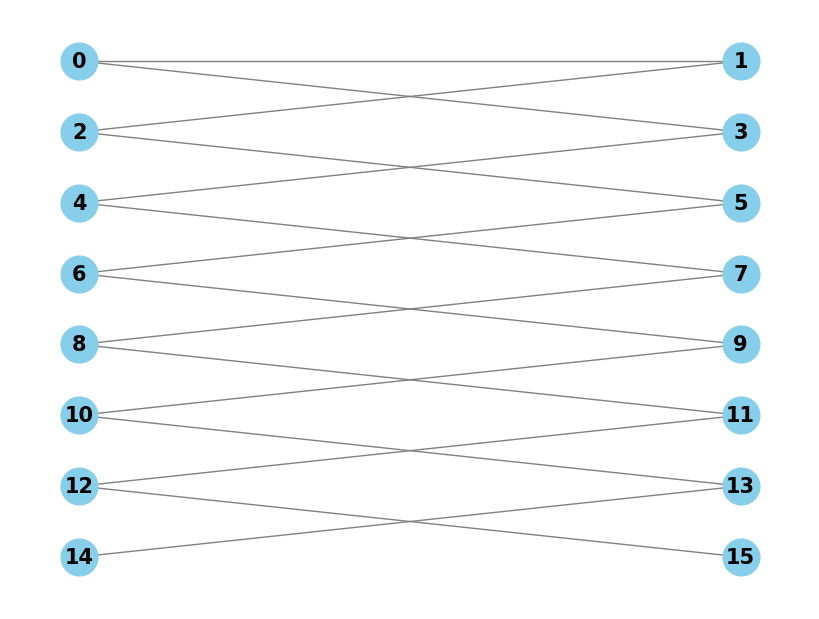

None


Matchings: 3
Matchings: [{('0100', '0111'), ('0110', '0101'), ('1110', '1101'), ('1010', '1001'), ('1100', '1111'), ('0000', '0011'), ('1000', '1011'), ('0010', '0001')}, {('1010', '1101'), ('0110', '1001'), ('1000', '0111'), ('0100', '0011'), ('0010', '0101'), ('1100', '1011')}, {('0000', '0001')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 37, Edges = 15, Per Edge = 2.467

Sample Circuit - Matching (n_steps=1):


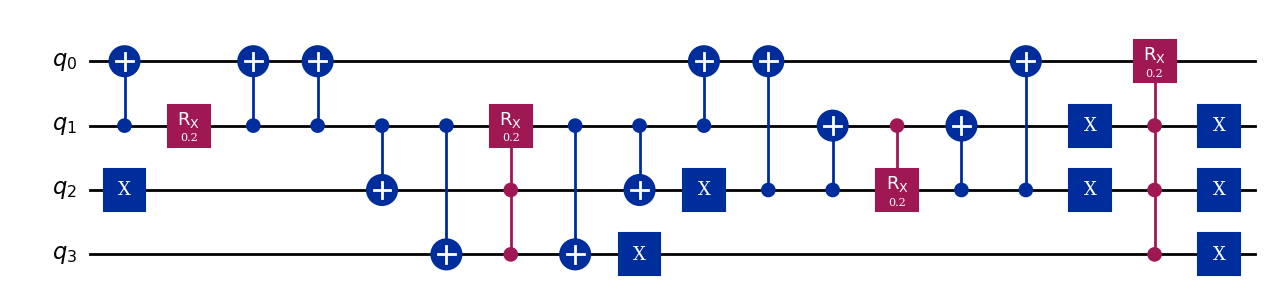


Gate Count Summary (U3/CX) for Sparse Bipartite Graph (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          62/42       39/37          77/58       42/52
       2         124/84       76/73        154/116      83/104
       5        310/210     187/181        385/290     206/260
      10        620/420     372/361        770/580     411/520
      20       1240/840     742/721      1540/1160    821/1040
      50      3100/2100   1852/1801      3850/2900   2051/2600
     100      6200/4200   3702/3601      7700/5800   4101/5200

Hamming cost/edge: 2.467
Error plot saved as: trotterization_plots/sparse_bipartite_graph_4_qubits_error_analysis.pdf


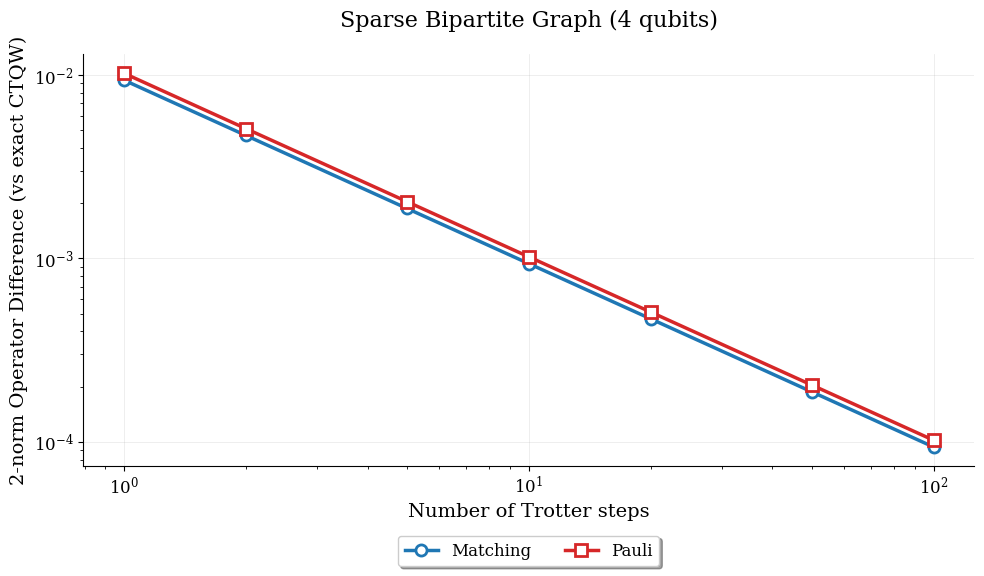

In [16]:
sparse_bipartite_16 = {
    ('0000','0001'), ('0000','0011'),
    ('0010','0001'), ('0010','0101'),
    ('0100','0011'), ('0100','0111'),
    ('0110','0101'), ('0110','1001'),
    ('1000','0111'), ('1000','1011'),
    ('1010','1001'), ('1010','1101'),
    ('1100','1011'), ('1100','1111'),
    ('1110','1101')
}

analyze_and_plot(sparse_bipartite_16, "Sparse Bipartite Graph (4 qubits)")


Sparse Non Bipartite Graph (5 qubits)
Original edges: {('10000', '01111'), ('00000', '00001'), ('00100', '00101'), ('01000', '00111'), ('00010', '00011'), ('00100', '00011'), ('01001', '01011'), ('00110', '00101'), ('00010', '00001')}
Number of qubits: 5

Graph:


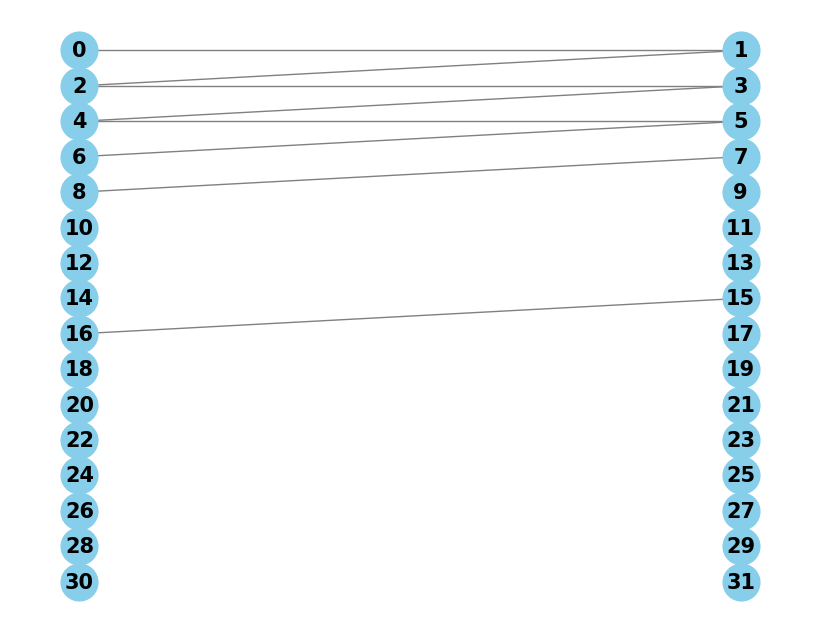

None


Matchings: 3
Matchings: [{('10000', '01111'), ('01000', '00111'), ('00100', '00011'), ('00110', '00101'), ('00010', '00001')}, {('00000', '00001'), ('00010', '00011'), ('00100', '00101')}, {('01001', '01011')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 20, Edges = 9, Per Edge = 2.222

Sample Circuit - Matching (n_steps=1):


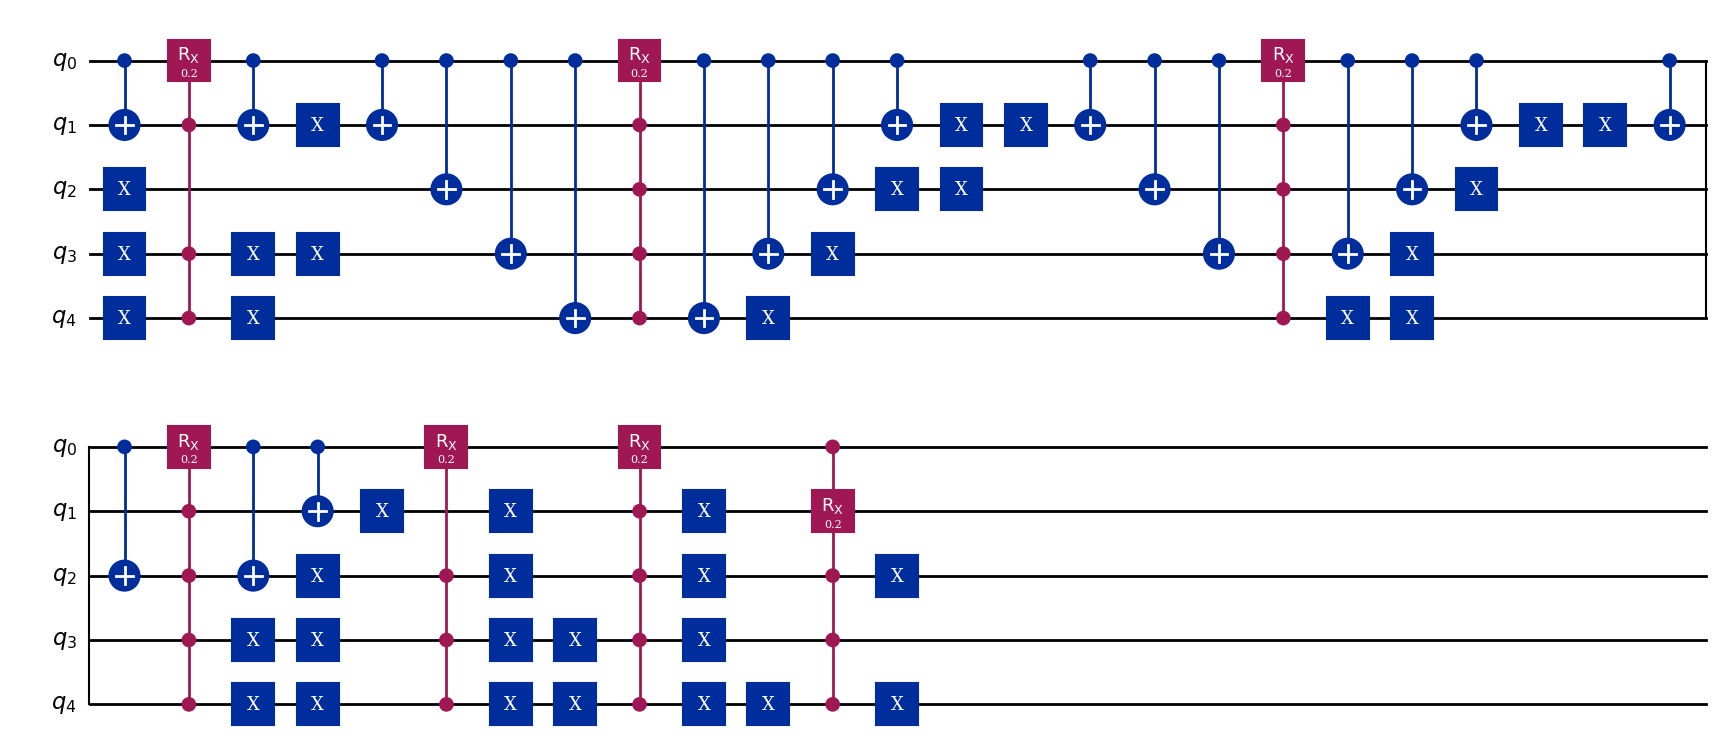


Gate Count Summary (U3/CX) for Sparse Non Bipartite Graph (5 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        318/180     176/165        564/496     380/276
       2        636/360     348/330       1128/992     763/552
       5       1590/900     864/825      2820/2480   1891/1380
      10      3180/1800   1724/1650      5640/4960   3811/2760
      20      6360/3600   3444/3300     11280/9920   7601/5520
      50     15900/9000   8604/8250    28200/24800 19001/13800
     100    31800/18000 17204/16500    56400/49600 37901/27600

Hamming cost/edge: 2.222
Error plot saved as: trotterization_plots/sparse_non_bipartite_graph_5_qubits_error_analysis.pdf


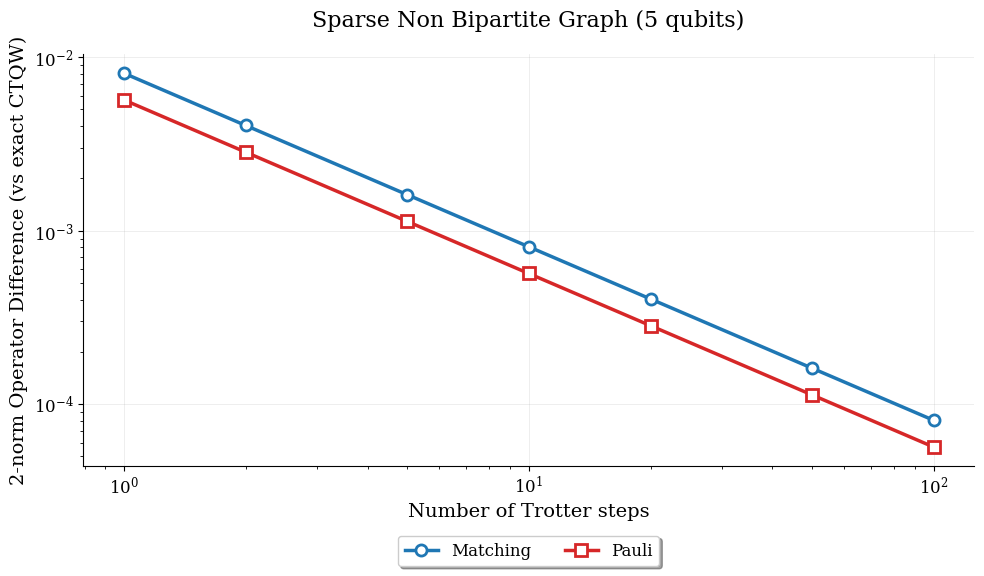

In [17]:
sparse_nonbipartite_32 = {
    # Cluster in 0xxxx region
    ('00000','00001'),  # H=1
    ('00010','00001'),  # H=2, degree-2 at 00001
    ('00010','00011'),  # H=1, degree-2 at 00010
    ('00100','00011'),  # H=2, degree-2 at 00011
    ('00100','00101'),  # H=1, degree-2 at 00100
    ('00110','00101'),  # H=2, degree-2 at 00101
    ('01000','00111'),  # H=3, bridge
    ('01001','01011'),  # H=1, small cluster in 01xxx
    ('10000','01111'),  # H=4, high-Hamming bridge to 1xxxx
}

analyze_and_plot(sparse_nonbipartite_32, "Sparse Non Bipartite Graph (5 qubits)" )


Cayley Graph of Z2 x Z2 x Z2 (3 qubits)
Original edges: {('100', '110'), ('110', '111'), ('000', '010'), ('010', '110'), ('001', '101'), ('011', '111'), ('100', '101'), ('000', '100'), ('001', '011'), ('000', '001'), ('101', '111'), ('010', '011')}
Number of qubits: 3

Graph:


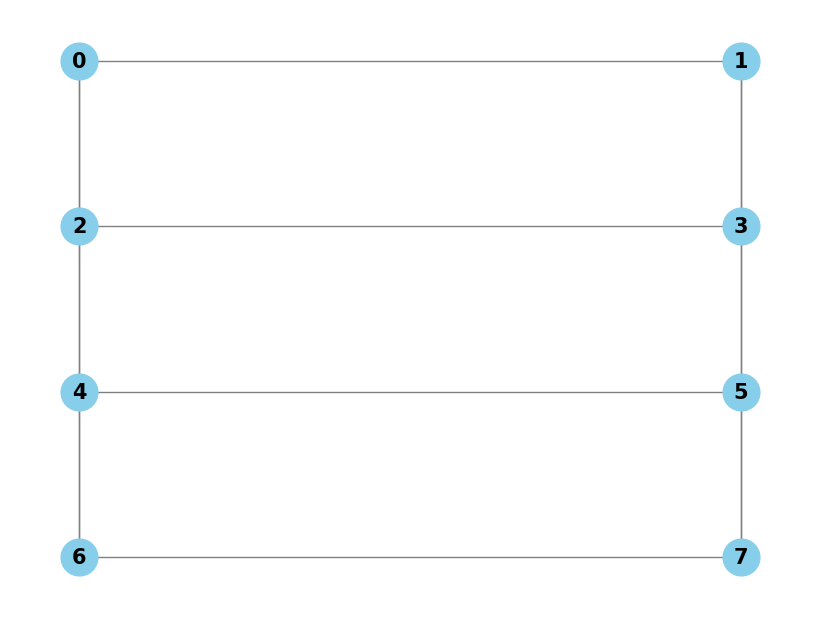

None


Matchings: 3
Matchings: [{('001', '011'), ('100', '110'), ('000', '010'), ('101', '111')}, {('010', '011'), ('110', '111'), ('000', '001'), ('100', '101')}, {('011', '111'), ('010', '110'), ('001', '101'), ('000', '100')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 12, Edges = 12, Per Edge = 1.000

Sample Circuit - Matching (n_steps=1):


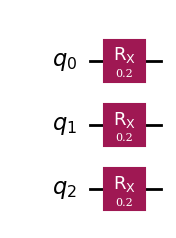


Gate Count Summary (U3/CX) for Cayley Graph of Z2 x Z2 x Z2 (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            3/0         3/0            3/0         3/0
       2            6/0         3/0            6/0         3/0
       5           15/0         3/0           15/0         3/0
      10           30/0         3/0           30/0         3/0
      20           60/0         3/0           60/0         3/0
      50          150/0         3/0          150/0         3/0
     100          300/0         3/0          300/0         3/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cayley_graph_of_z2_x_z2_x_z2_3_qubits_error_analysis.pdf


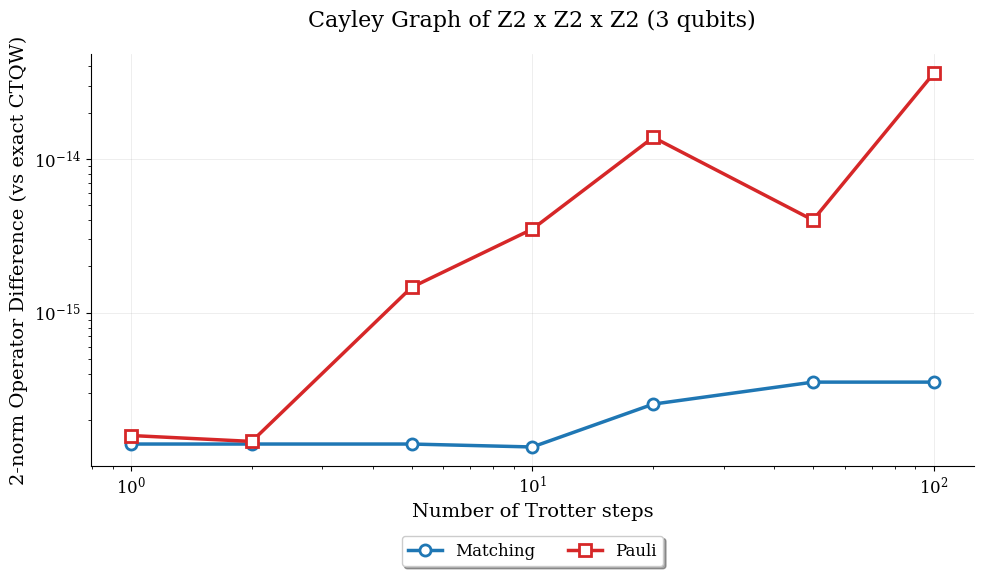

In [18]:
cayley_8 = set()
vertices_8 = [format(i, '03b') for i in range(8)]
generators_8 = ['001', '010', '100']
for v in vertices_8:
    v_int = int(v, 2)
    for g in generators_8:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '03b')
        if v < neighbor:  # Avoid duplicates
            cayley_8.add((v, neighbor))

analyze_and_plot(cayley_8, "Cayley Graph of Z2 x Z2 x Z2 (3 qubits)")


Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)
Original edges: {('0000', '1000'), ('0100', '0101'), ('1101', '1111'), ('0101', '0111'), ('1100', '1101'), ('0010', '1010'), ('0001', '0101'), ('0111', '1111'), ('0100', '0110'), ('0001', '1001'), ('0000', '0010'), ('1010', '1110'), ('0000', '0001'), ('0001', '0011'), ('0110', '1110'), ('1110', '1111'), ('0110', '0111'), ('1000', '1010'), ('0101', '1101'), ('1011', '1111'), ('1010', '1011'), ('1001', '1011'), ('1000', '1100'), ('0010', '0011'), ('1001', '1101'), ('1100', '1110'), ('0011', '0111'), ('0000', '0100'), ('0100', '1100'), ('1000', '1001'), ('0011', '1011'), ('0010', '0110')}
Number of qubits: 4

Graph:


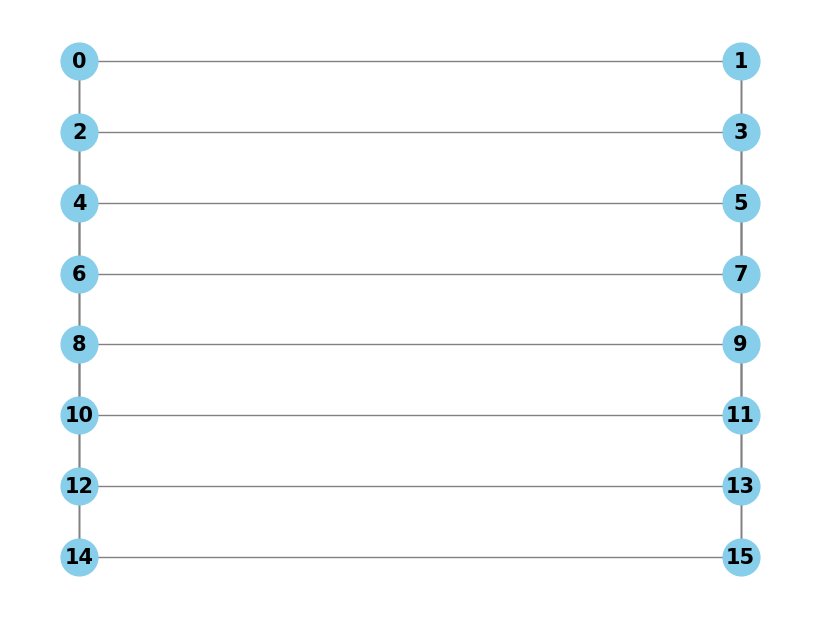

None


Matchings: 4
Matchings: [{('0000', '1000'), ('0010', '1010'), ('0111', '1111'), ('0001', '1001'), ('0100', '1100'), ('0110', '1110'), ('0011', '1011'), ('0101', '1101')}, {('0010', '0011'), ('0100', '0101'), ('1010', '1011'), ('1100', '1101'), ('1000', '1001'), ('0000', '0001'), ('1110', '1111'), ('0110', '0111')}, {('1100', '1110'), ('1101', '1111'), ('0100', '0110'), ('1001', '1011'), ('0101', '0111'), ('0000', '0010'), ('0001', '0011'), ('1000', '1010')}, {('1001', '1101'), ('0011', '0111'), ('0001', '0101'), ('1011', '1111'), ('0000', '0100'), ('1010', '1110'), ('0010', '0110'), ('1000', '1100')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 32, Edges = 32, Per Edge = 1.000

Sample Circuit - Matching (n_steps=1):


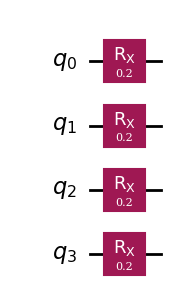


Gate Count Summary (U3/CX) for Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            4/0         4/0            4/0         4/0
       2            8/0         4/0            8/0         4/0
       5           20/0         4/0           20/0         4/0
      10           40/0         4/0           40/0         4/0
      20           80/0         4/0           80/0         4/0
      50          200/0         4/0          200/0         4/0
     100          400/0         4/0          400/0         4/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cayley_graph_of_z2_x_z2_x_z2_x_z2_4_qubits_error_analysis.pdf


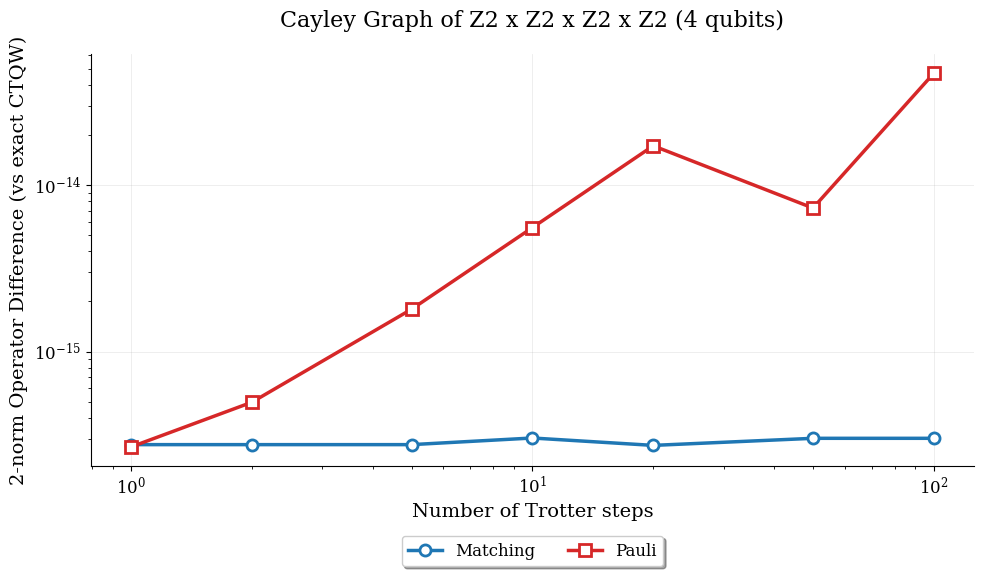

In [19]:
cayley_16 = set()
vertices_16 = [format(i, '04b') for i in range(16)]
generators_16 = ['0001', '0010', '0100', '1000']
for v in vertices_16:
    v_int = int(v, 2)
    for g in generators_16:
        g_int = int(g, 2)
        neighbor = format(v_int ^ g_int, '04b')
        if v < neighbor:  # Avoid duplicates
            cayley_16.add((v, neighbor))
analyze_and_plot(cayley_16, "Cayley Graph of Z2 x Z2 x Z2 x Z2 (4 qubits)")


Circulant Graph C8(1,2) (3 qubits)
Original edges: {('011', '100'), ('100', '110'), ('000', '010'), ('011', '101'), ('110', '111'), ('001', '010'), ('101', '110'), ('010', '100'), ('100', '101'), ('001', '011'), ('000', '001'), ('101', '111'), ('010', '011')}
Number of qubits: 3

Graph:


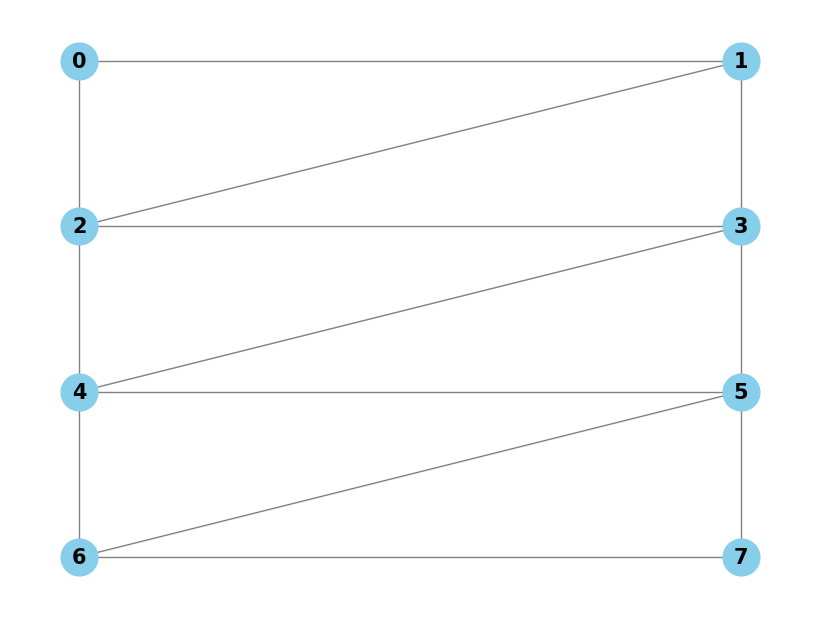

None


Matchings: 4
Matchings: [{('101', '110'), ('011', '100'), ('001', '010')}, {('011', '101'), ('010', '100')}, {('001', '011'), ('100', '110'), ('000', '010'), ('101', '111')}, {('010', '011'), ('110', '111'), ('000', '001'), ('100', '101')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 19, Edges = 13, Per Edge = 1.462

Sample Circuit - Matching (n_steps=1):


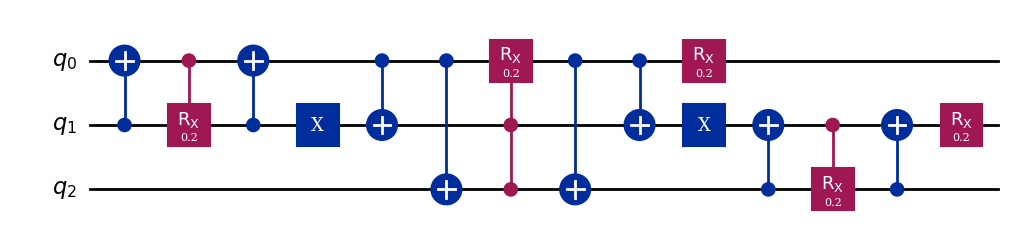


Gate Count Summary (U3/CX) for Circulant Graph C8(1,2) (3 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          25/20       22/14          50/24       27/16
       2          50/40       41/28         100/48       51/32
       5        125/100       98/70        250/120      119/80
      10        250/200     193/140        500/240     234/160
      20        500/400     383/280       1000/480     464/320
      50      1250/1000     953/700      2500/1200    1203/800
     100      2500/2000   1903/1400      5000/2400   2304/1600

Hamming cost/edge: 1.462
Error plot saved as: trotterization_plots/circulant_graph_c81,2_3_qubits_error_analysis.pdf


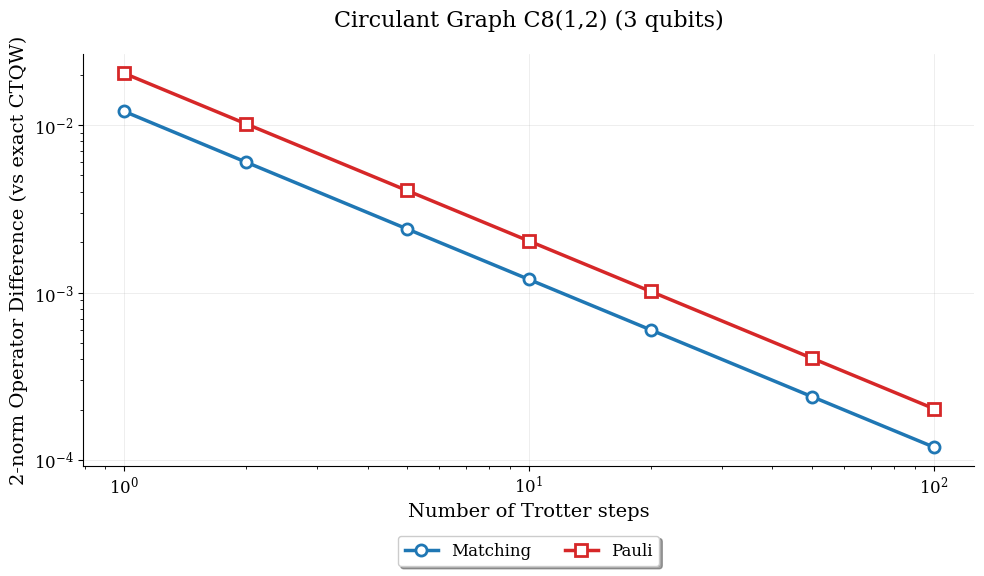

In [20]:
circulant_8 = set()
n = 8
offsets_8 = [1, 2]
for i in range(n):
    v = format(i, '03b')
    for offset in offsets_8:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '03b')
        if v < neighbor:  # Avoid duplicates
            circulant_8.add((v, neighbor))
analyze_and_plot(circulant_8, "Circulant Graph C8(1,2) (3 qubits)")


Circulant Graph C16(1,3,5) (4 qubits)
Original edges: {('0100', '0111'), ('0111', '1100'), ('0011', '1000'), ('0100', '0101'), ('0100', '1001'), ('1100', '1111'), ('1000', '1101'), ('0011', '0110'), ('1001', '1010'), ('1100', '1101'), ('1011', '1100'), ('1011', '1110'), ('0111', '1000'), ('0101', '1000'), ('0001', '0100'), ('1001', '1100'), ('1001', '1110'), ('0000', '0001'), ('1110', '1111'), ('0110', '0111'), ('0101', '0110'), ('0110', '1001'), ('1010', '1011'), ('0110', '1011'), ('0010', '0111'), ('0010', '0101'), ('1010', '1111'), ('0001', '0110'), ('0111', '1010'), ('1101', '1110'), ('0010', '0011'), ('1010', '1101'), ('0101', '1010'), ('0000', '0101'), ('0001', '0010'), ('0011', '0100'), ('1000', '1001'), ('0000', '0011'), ('1000', '1011')}
Number of qubits: 4

Graph:


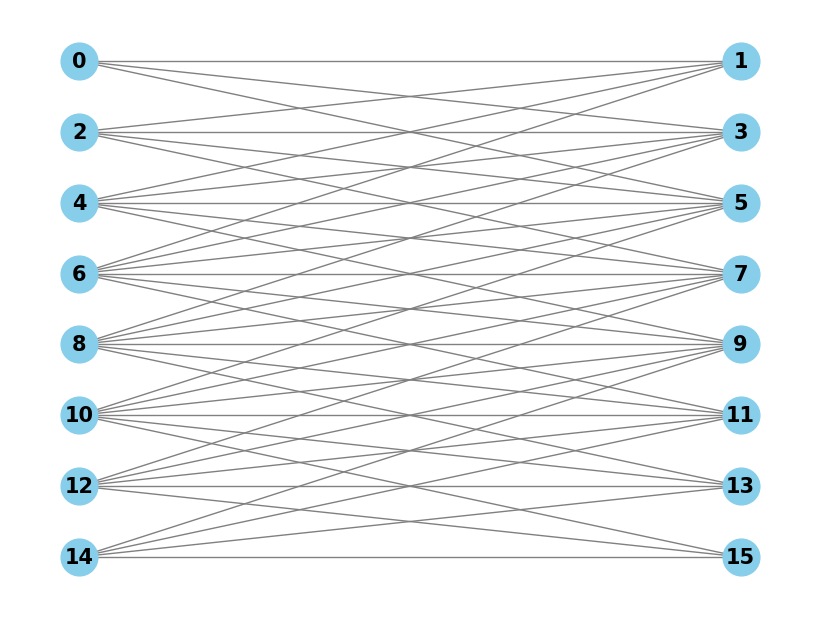

None


Matchings: 7
Matchings: [{('0100', '0111'), ('0011', '1000'), ('1100', '1111'), ('0001', '0010'), ('1001', '1010'), ('0101', '0110'), ('1011', '1110')}, {('0111', '1100'), ('0100', '1001'), ('1000', '1101'), ('0011', '0110'), ('0010', '0101'), ('1010', '1111')}, {('1010', '1101'), ('0111', '1000'), ('0000', '0101'), ('0001', '0100'), ('1001', '1110'), ('1011', '1100')}, {('1101', '1110'), ('0101', '1000'), ('0110', '1011'), ('0010', '0111'), ('0011', '0100'), ('1001', '1100')}, {('0110', '1001'), ('0000', '0011'), ('1000', '1011'), ('0111', '1010')}, {('0101', '1010'), ('0001', '0110')}, {('0010', '0011'), ('0100', '0101'), ('1010', '1011'), ('1100', '1101'), ('1000', '1001'), ('0000', '0001'), ('1110', '1111'), ('0110', '0111')}]
Number of qubits: 4

Hamming Cost Analysis:
Total = 88, Edges = 39, Per Edge = 2.256

Sample Circuit - Matching (n_steps=1):


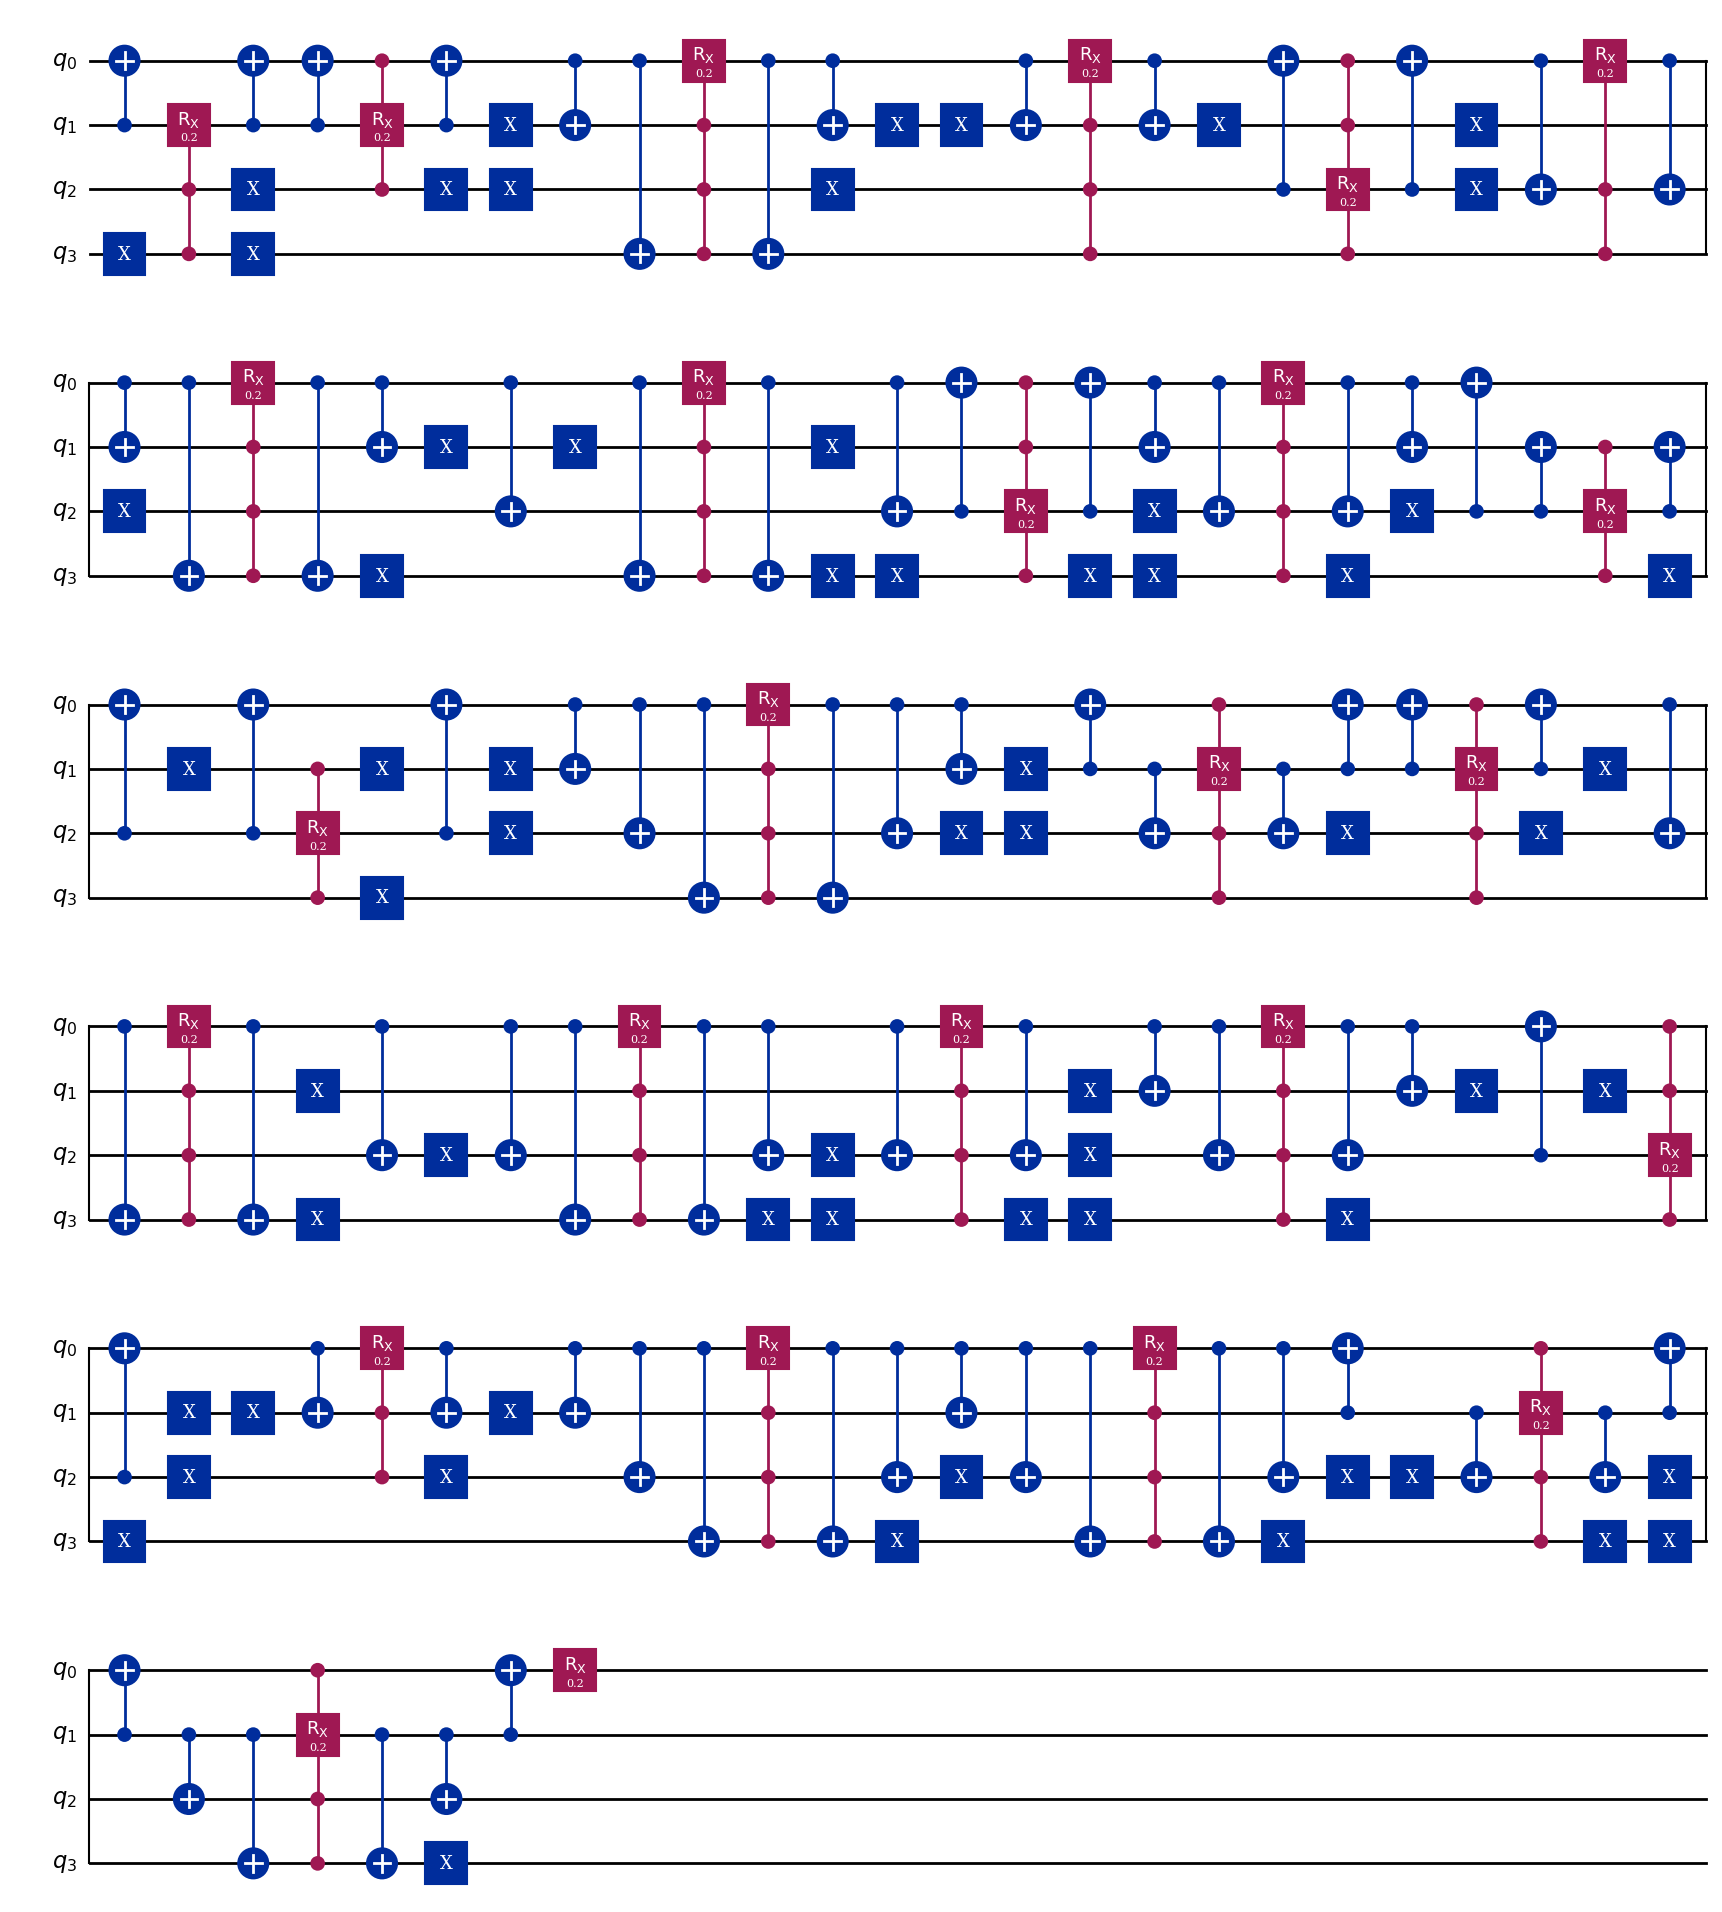


Gate Count Summary (U3/CX) for Circulant Graph C16(1,3,5) (4 qubits):
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1        820/512     399/461         153/92       90/70
       2      1640/1024     796/920        306/184     176/140
       5      4100/2560   1987/2297        765/460     434/350
      10      8200/5120   3982/4592       1530/920     864/700
      20    16400/10240   7982/9182      3060/1840   1724/1400
      50    41000/25600 19952/22952      7650/4600   4304/3500
     100    82000/51200 39902/45902     15300/9200   8604/7000

Hamming cost/edge: 2.256
Error plot saved as: trotterization_plots/circulant_graph_c161,3,5_4_qubits_error_analysis.pdf


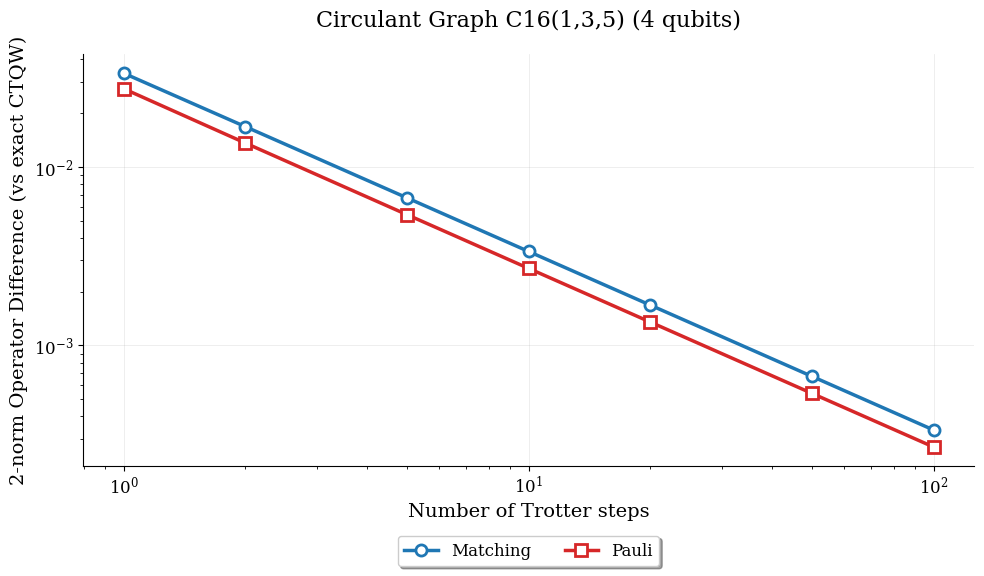

In [21]:
circulant_16 = set()
n = 16
offsets_16 = [1, 3, 5]
for i in range(n):
    v = format(i, '04b')
    for offset in offsets_16:
        neighbor_idx = (i + offset) % n
        neighbor = format(neighbor_idx, '04b')
        if v < neighbor:  # Avoid duplicates
            circulant_16.add((v, neighbor))
analyze_and_plot(circulant_16, "Circulant Graph C16(1,3,5) (4 qubits)")


Cayley Z2^5
Original edges: {('00110', '00111'), ('01000', '11000'), ('01010', '01110'), ('01010', '11010'), ('00110', '10110'), ('11000', '11001'), ('00001', '00101'), ('10000', '10010'), ('10100', '11100'), ('01000', '01100'), ('01010', '01011'), ('00000', '01000'), ('10001', '10101'), ('00101', '00111'), ('01100', '11100'), ('00010', '10010'), ('10001', '11001'), ('11000', '11010'), ('11001', '11011'), ('10110', '10111'), ('00111', '01111'), ('11100', '11101'), ('10110', '11110'), ('01001', '01011'), ('11010', '11110'), ('10000', '10100'), ('00110', '01110'), ('00101', '10101'), ('00000', '00001'), ('00011', '00111'), ('11001', '11101'), ('11101', '11111'), ('10100', '10110'), ('10001', '10011'), ('00010', '01010'), ('01100', '01101'), ('10101', '10111'), ('00100', '00110'), ('01101', '11101'), ('00101', '01101'), ('01000', '01010'), ('10011', '11011'), ('10100', '10101'), ('10111', '11111'), ('01011', '11011'), ('00000', '10000'), ('01111', '11111'), ('00100', '01100'), ('00000', 

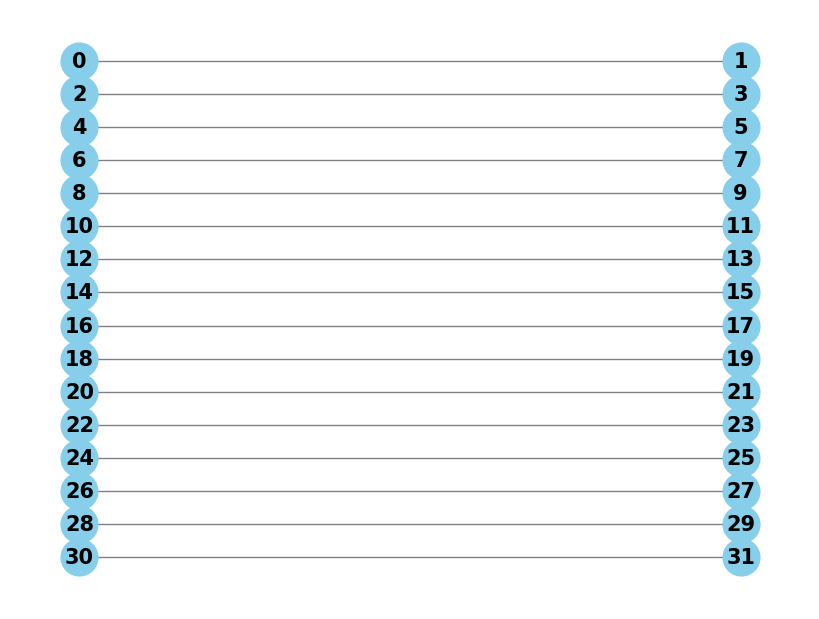

None


Matchings: 5
Matchings: [{('11010', '11011'), ('00110', '00111'), ('11000', '11001'), ('00000', '00001'), ('01010', '01011'), ('11100', '11101'), ('10000', '10001'), ('00100', '00101'), ('11110', '11111'), ('01100', '01101'), ('00010', '00011'), ('01000', '01001'), ('10100', '10101'), ('10010', '10011'), ('10110', '10111'), ('01110', '01111')}, {('01000', '11000'), ('01101', '11101'), ('01111', '11111'), ('00011', '10011'), ('00101', '10101'), ('00010', '10010'), ('01001', '11001'), ('00100', '10100'), ('01010', '11010'), ('01011', '11011'), ('00110', '10110'), ('00000', '10000'), ('00001', '10001'), ('01110', '11110'), ('01100', '11100'), ('00111', '10111')}, {('01000', '01100'), ('01010', '01110'), ('11011', '11111'), ('01011', '01111'), ('00000', '00100'), ('00011', '00111'), ('11001', '11101'), ('11000', '11100'), ('01001', '01101'), ('10001', '10101'), ('10010', '10110'), ('11010', '11110'), ('00010', '00110'), ('00001', '00101'), ('10011', '10111'), ('10000', '10100')}, {('00001

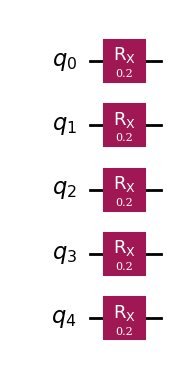


Gate Count Summary (U3/CX) for Cayley Z2^5:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1            5/0         5/0            5/0         5/0
       2           10/0         5/0           10/0         5/0
       5           25/0         5/0           25/0         5/0
      10           50/0         5/0           50/0         5/0
      20          100/0         5/0          100/0         5/0
      50          250/0         5/0          250/0         5/0
     100          500/0         5/0          500/0         5/0

Hamming cost/edge: 1.000
Error plot saved as: trotterization_plots/cayley_z2^5_error_analysis.pdf


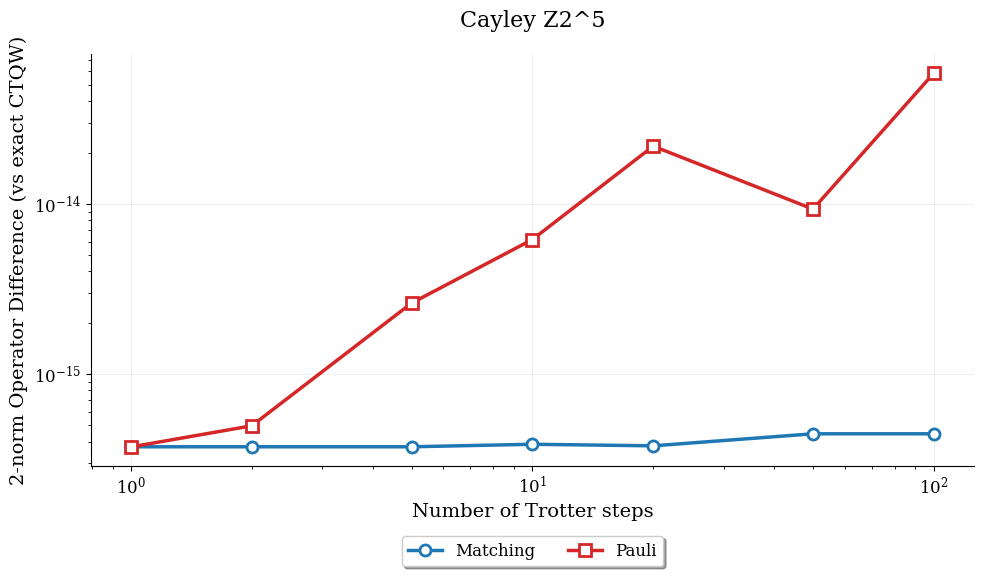

In [22]:
# 5 qubits: Cayley graph of Z2^5 with standard generators (bit flips)
cayley_edges = set()
for i in range(32):
    node_i = format(i, '05b')
    for bit_pos in range(5):
        j = i ^ (1 << bit_pos)  # XOR to flip bit
        node_j = format(j, '05b')
        if i < j:  # Avoid duplicates
            cayley_edges.add((node_i, node_j))

analyze_and_plot(cayley_edges, "Cayley Z2^5")


Circulant C32(1,2,5)
Original edges: {('00110', '00111'), ('10101', '10110'), ('10001', '10110'), ('01100', '10001'), ('11000', '11001'), ('01110', '10000'), ('00110', '01000'), ('11011', '11101'), ('10000', '10010'), ('01010', '01011'), ('01010', '01100'), ('01001', '01110'), ('10011', '11000'), ('00101', '00111'), ('00010', '00100'), ('11000', '11010'), ('11001', '11011'), ('00101', '01010'), ('10110', '10111'), ('01101', '10010'), ('10111', '11000'), ('11100', '11101'), ('01001', '01011'), ('00000', '00001'), ('10010', '10100'), ('11101', '11111'), ('00010', '00111'), ('01011', '10000'), ('10100', '10110'), ('10001', '10011'), ('01100', '01101'), ('10101', '10111'), ('10000', '10101'), ('00100', '01001'), ('00100', '00110'), ('00011', '01000'), ('10110', '11000'), ('00110', '01011'), ('01000', '01010'), ('10111', '11100'), ('01111', '10000'), ('10100', '10101'), ('10100', '11001'), ('00111', '01000'), ('00000', '00010'), ('10101', '11010'), ('00000', '00101'), ('10011', '10100'), (

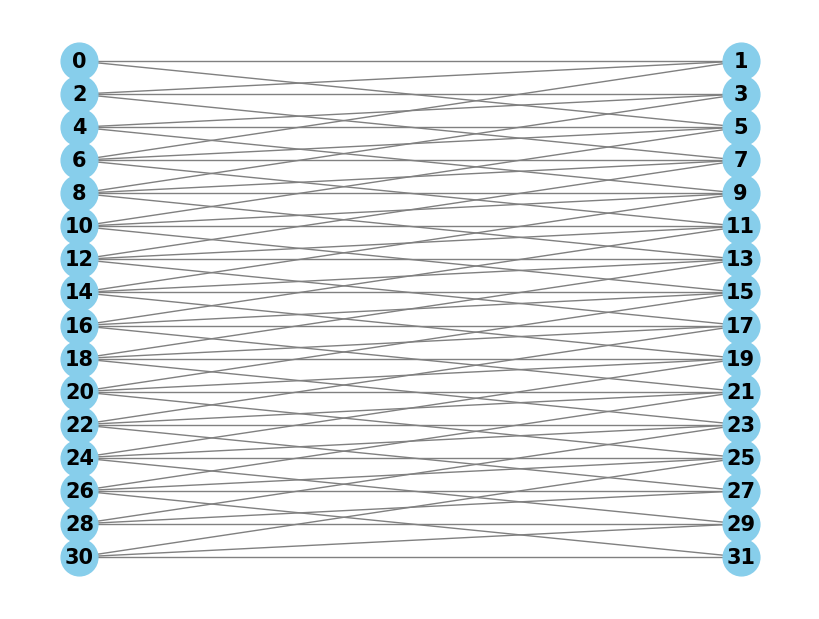

None


Matchings: 8
Matchings: [{('11010', '11011'), ('00110', '00111'), ('11000', '11001'), ('00000', '00001'), ('01010', '01011'), ('11100', '11101'), ('10000', '10001'), ('00100', '00101'), ('11110', '11111'), ('01100', '01101'), ('00010', '00011'), ('01000', '01001'), ('10100', '10101'), ('10010', '10011'), ('10110', '10111'), ('01110', '01111')}, {('00010', '00100'), ('01101', '10010'), ('01110', '10000'), ('00110', '01000'), ('10111', '11100'), ('10100', '11001'), ('11010', '11111'), ('00111', '01001'), ('10011', '11000'), ('10101', '10110'), ('00101', '01010'), ('11011', '11101'), ('01100', '10001')}, {('11101', '11110'), ('00001', '00110'), ('10111', '11000'), ('01010', '01100'), ('01001', '01110'), ('10010', '10100'), ('10101', '11010'), ('00010', '00111'), ('00000', '00101'), ('00011', '01000'), ('10001', '10110'), ('01011', '10000'), ('11011', '11100')}, {('00011', '00101'), ('11001', '11110'), ('00110', '01011'), ('01101', '01110'), ('00001', '00010'), ('11010', '11100'), ('10110

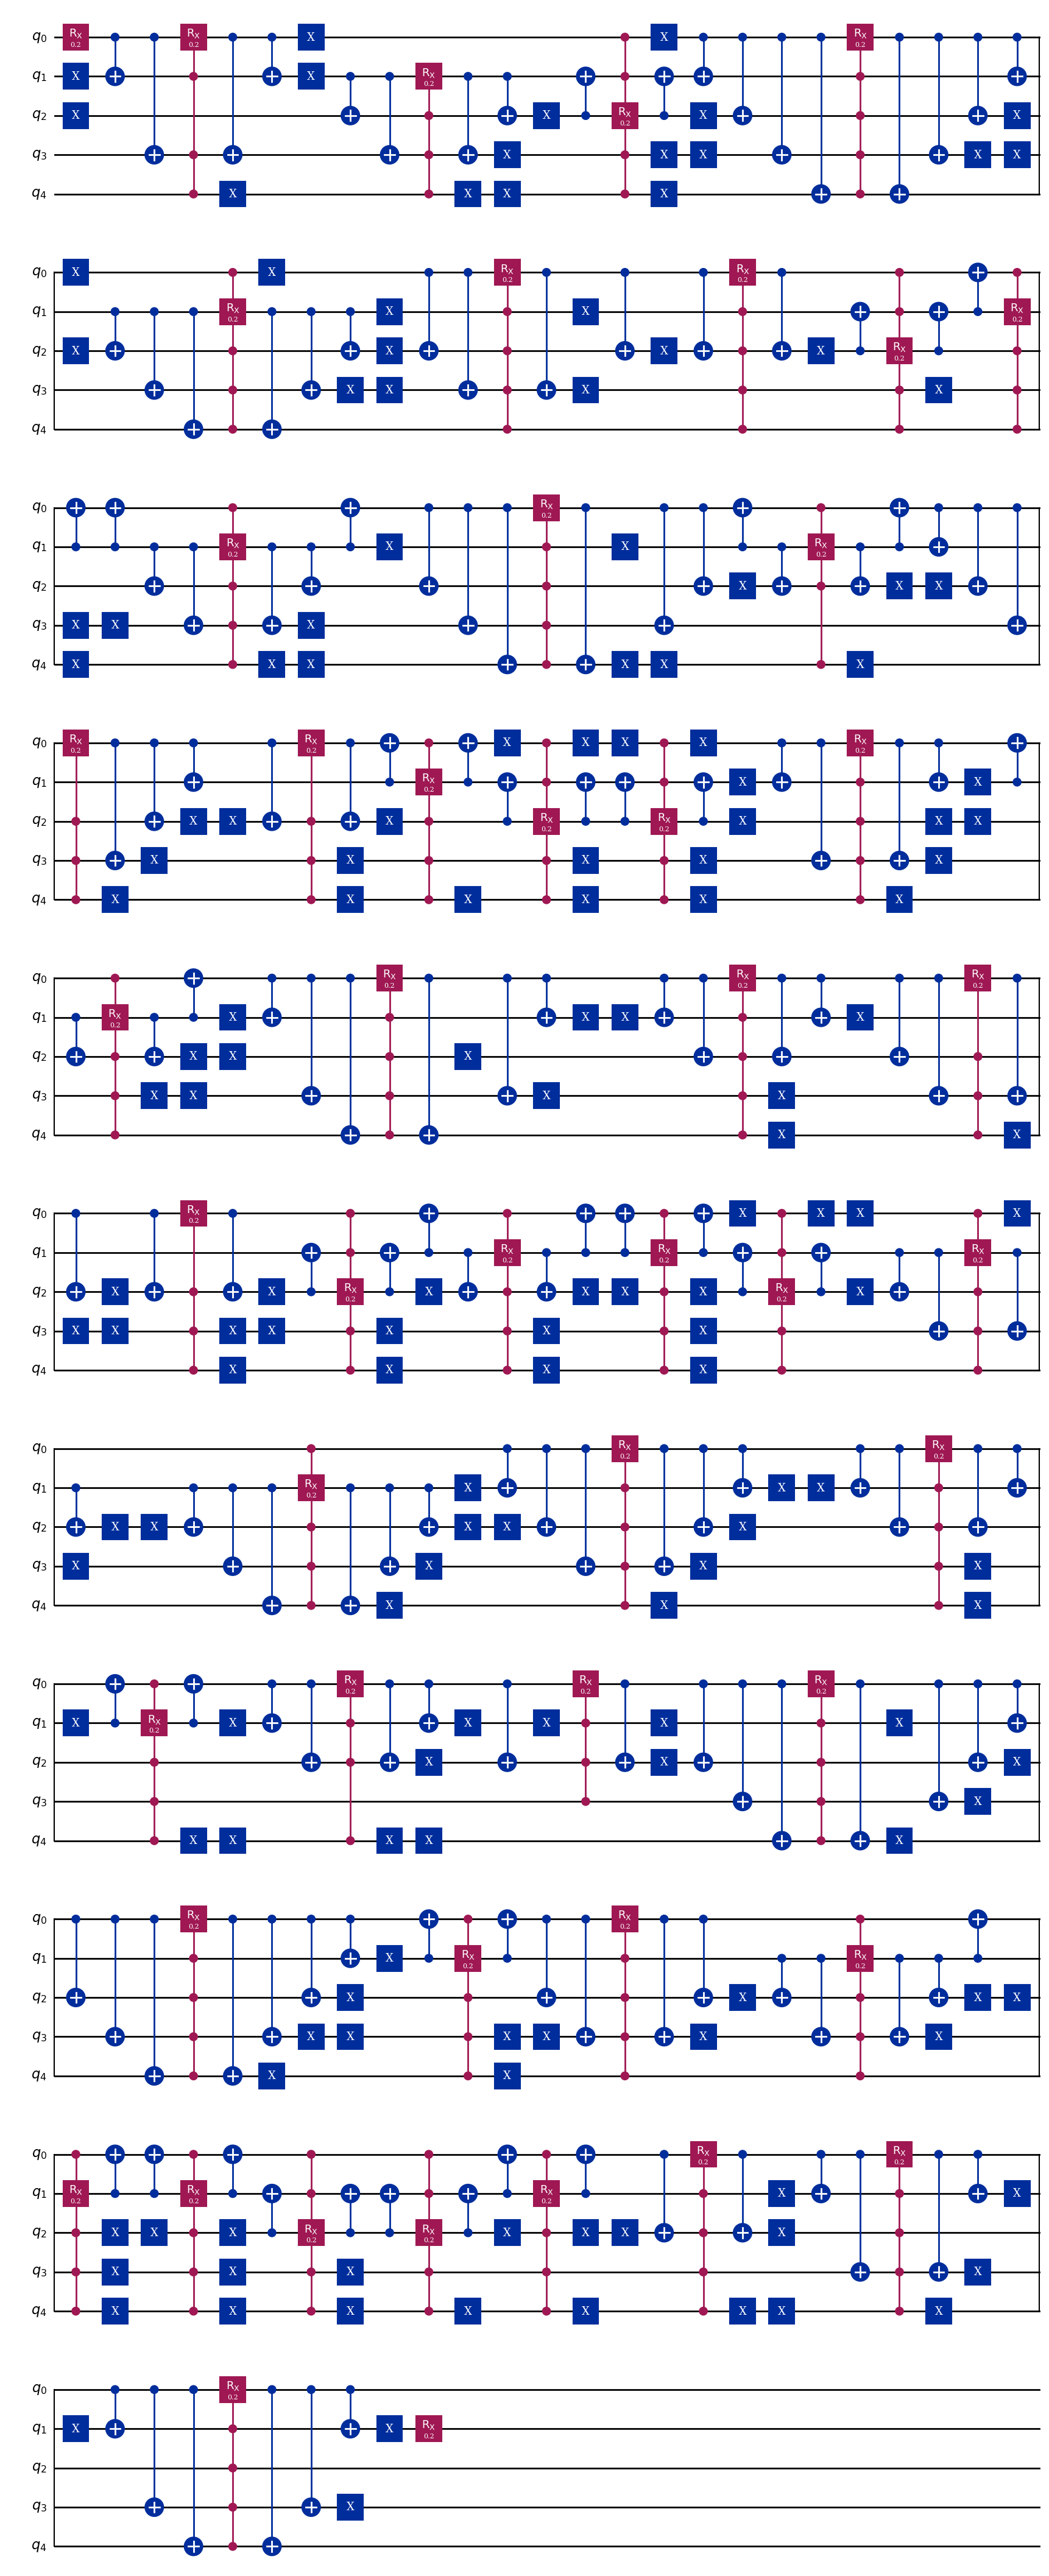


Gate Count Summary (U3/CX) for Circulant C32(1,2,5):
 n_steps Match (No Opt)   Match (Opt) Pauli (No Opt) Pauli (Opt)
       1      2081/1264     1222/1215        470/300     192/152
       2      4162/2528     2443/2430        940/600     379/304
       5     10405/6320     6106/6075      2350/1500     940/760
      10    20810/12640   12231/12150      4700/3000   1875/1520
      20    41620/25280   24461/24300      9400/6000   3745/3040
      50   104050/63200   61151/60750    23500/15000   9355/7600
     100  208100/126400 122301/121500    47000/30000 18705/15200

Hamming cost/edge: 2.159
Error plot saved as: trotterization_plots/circulant_c321,2,5_error_analysis.pdf


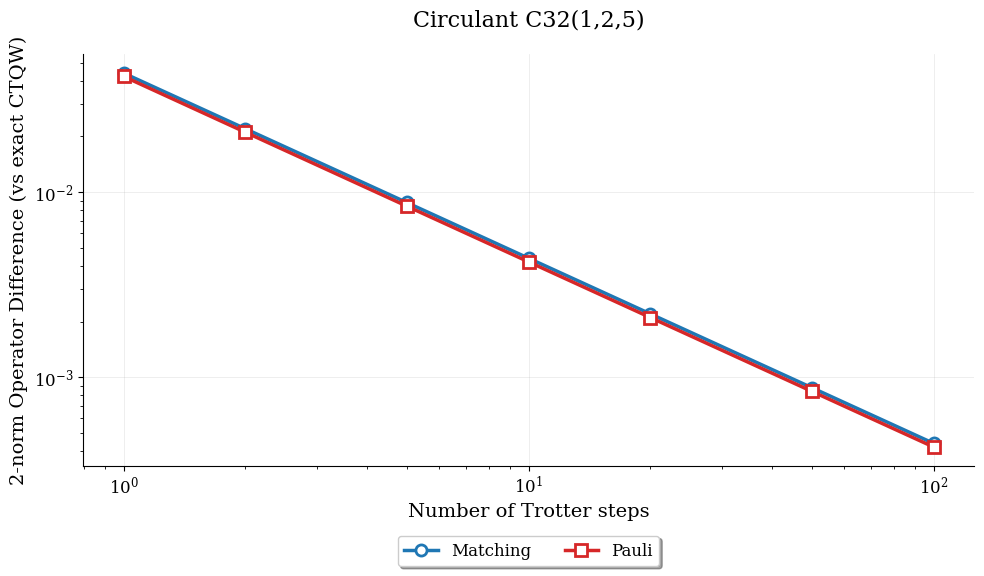

In [23]:
# 5 qubits: Circulant graph C32(1,2,5)
circ_edges = set()
offsets = [1, 2, 5]
for i in range(32):
    node_i = format(i, '05b')
    for offset in offsets:
        j = (i + offset) % 32
        node_j = format(j, '05b')
        if i < j:  # Avoid duplicates (circulant is symmetric)
            circ_edges.add((node_i, node_j))

analyze_and_plot(circ_edges, "Circulant C32(1,2,5)")


Path P32
Original edges: {('11010', '11011'), ('00110', '00111'), ('10111', '11000'), ('11100', '11101'), ('10101', '10110'), ('00111', '01000'), ('11000', '11001'), ('00000', '00001'), ('00001', '00010'), ('10011', '10100'), ('10001', '10010'), ('11011', '11100'), ('01011', '01100'), ('01001', '01010'), ('01010', '01011'), ('00100', '00101'), ('01100', '01101'), ('01110', '01111'), ('10010', '10011'), ('11001', '11010'), ('00011', '00100'), ('10000', '10001'), ('11101', '11110'), ('11110', '11111'), ('01111', '10000'), ('00010', '00011'), ('01000', '01001'), ('10100', '10101'), ('10110', '10111'), ('00101', '00110'), ('01101', '01110')}
Number of qubits: 5

Graph:


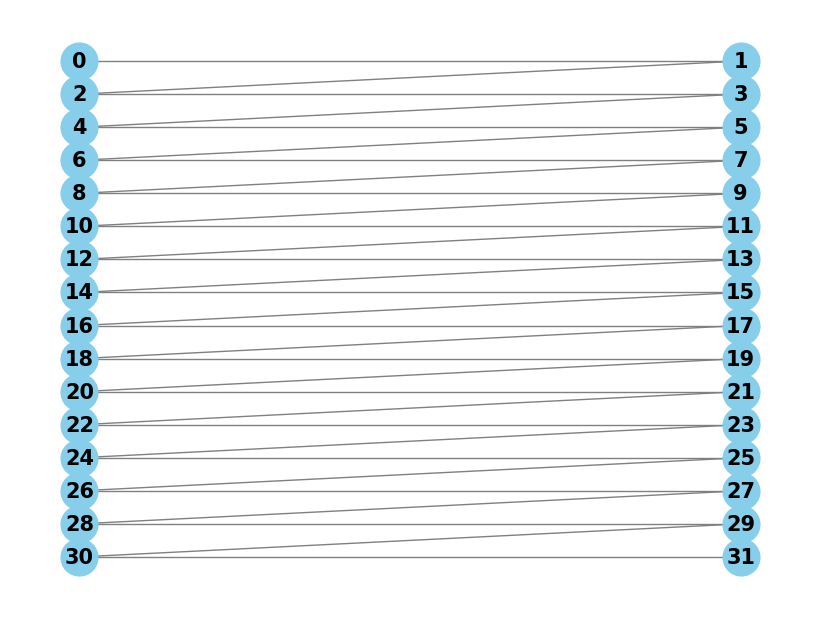

None


Matchings: 2
Matchings: [{('11010', '11011'), ('00110', '00111'), ('11000', '11001'), ('00000', '00001'), ('01010', '01011'), ('11100', '11101'), ('11110', '11111'), ('00100', '00101'), ('01100', '01101'), ('10110', '10111'), ('00010', '00011'), ('01000', '01001'), ('01110', '01111'), ('10010', '10011'), ('10100', '10101'), ('10000', '10001')}, {('11101', '11110'), ('01011', '01100'), ('10111', '11000'), ('01101', '01110'), ('01111', '10000'), ('00001', '00010'), ('00101', '00110'), ('10101', '10110'), ('01001', '01010'), ('11001', '11010'), ('00011', '00100'), ('10011', '10100'), ('10001', '10010'), ('11011', '11100'), ('00111', '01000')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 57, Edges = 31, Per Edge = 1.839

Sample Circuit - Matching (n_steps=1):


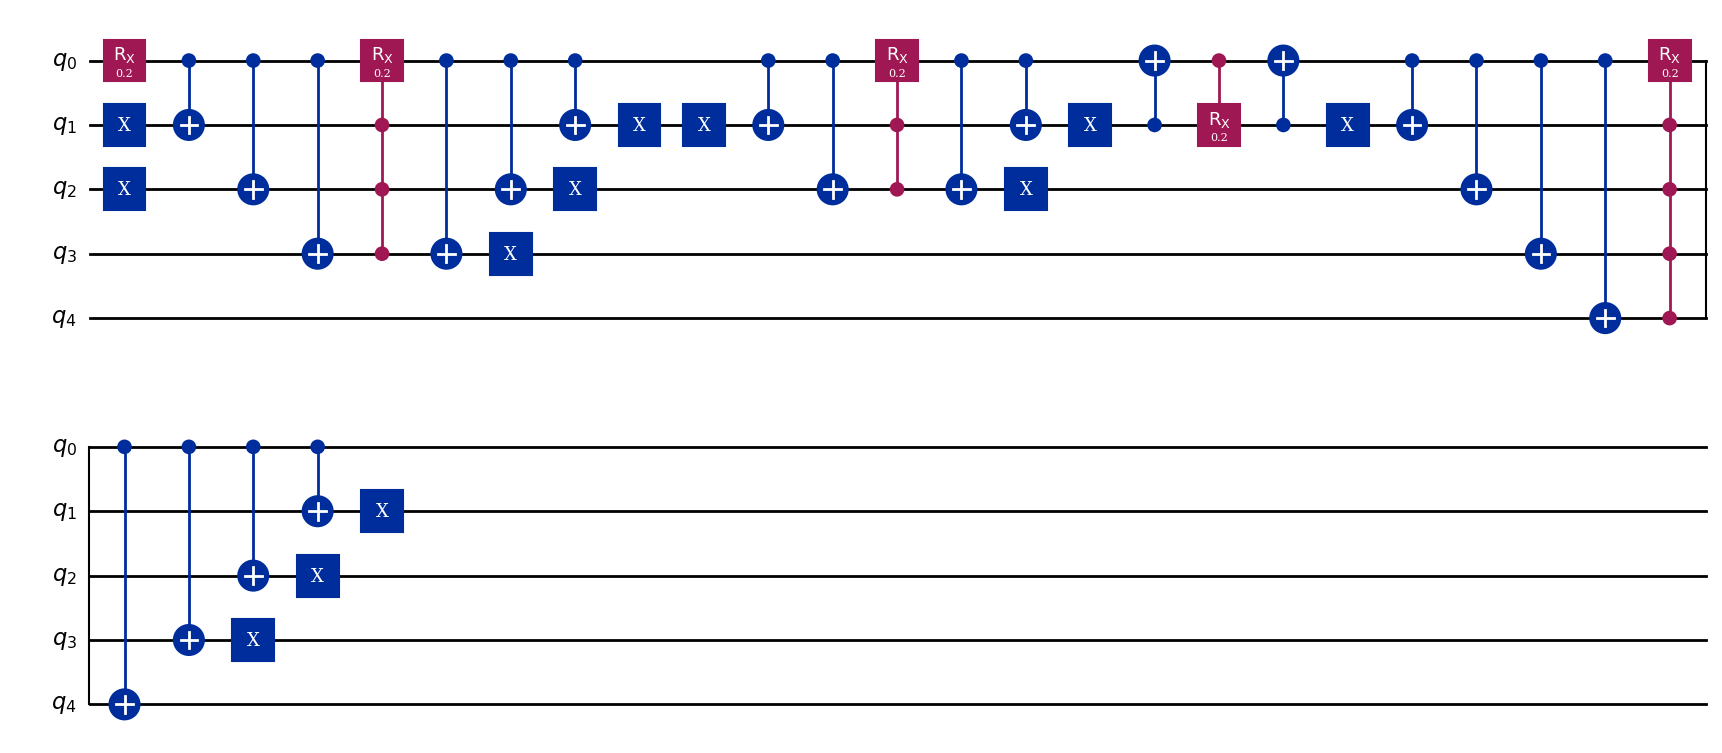


Gate Count Summary (U3/CX) for Path P32:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         108/74       66/65        287/196     172/124
       2        216/148     127/130        574/392     339/248
       5        540/370     310/325       1435/980     840/620
      10       1080/740     615/650      2870/1960   1675/1240
      20      2160/1480   1225/1300      5740/3920   3345/2480
      50      5400/3700   3055/3250     14350/9800   8355/6200
     100     10800/7400   6105/6500    28700/19600 16705/12400

Hamming cost/edge: 1.839
Error plot saved as: trotterization_plots/path_p32_error_analysis.pdf


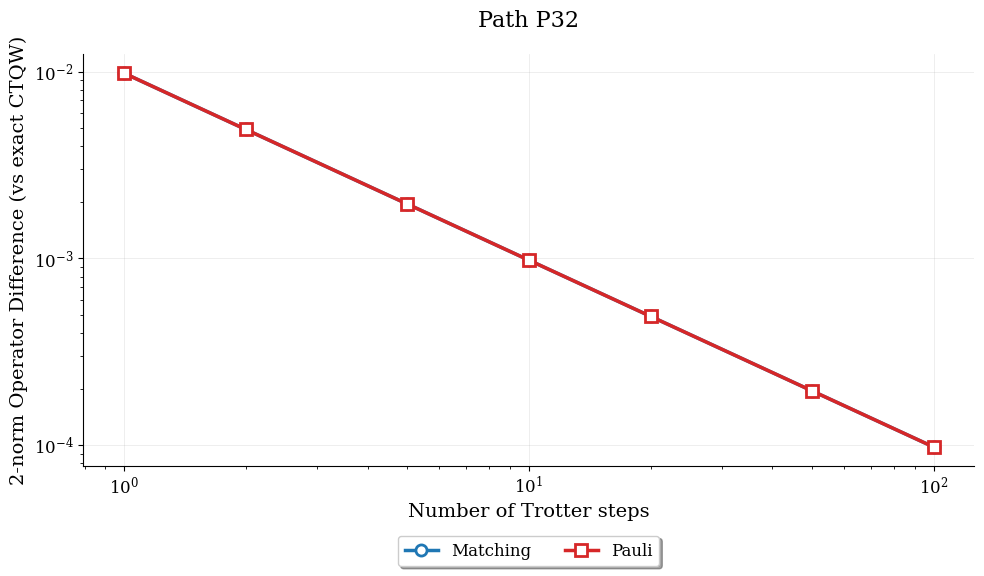

In [24]:
# 5 qubits: Path graph P32
path_edges = set()
for i in range(31):
    node_i = format(i, '05b')
    node_j = format(i+1, '05b')
    path_edges.add((node_i, node_j))

analyze_and_plot(path_edges, "Path P32")


Cycle C32
Original edges: {('11010', '11011'), ('00110', '00111'), ('10111', '11000'), ('11100', '11101'), ('10101', '10110'), ('00111', '01000'), ('11000', '11001'), ('00000', '00001'), ('00001', '00010'), ('10011', '10100'), ('10001', '10010'), ('11011', '11100'), ('01011', '01100'), ('01001', '01010'), ('01010', '01011'), ('00100', '00101'), ('01100', '01101'), ('01110', '01111'), ('10010', '10011'), ('11001', '11010'), ('00011', '00100'), ('10000', '10001'), ('11101', '11110'), ('11110', '11111'), ('11111', '00000'), ('01111', '10000'), ('00010', '00011'), ('01000', '01001'), ('10100', '10101'), ('10110', '10111'), ('00101', '00110'), ('01101', '01110')}
Number of qubits: 5

Graph:


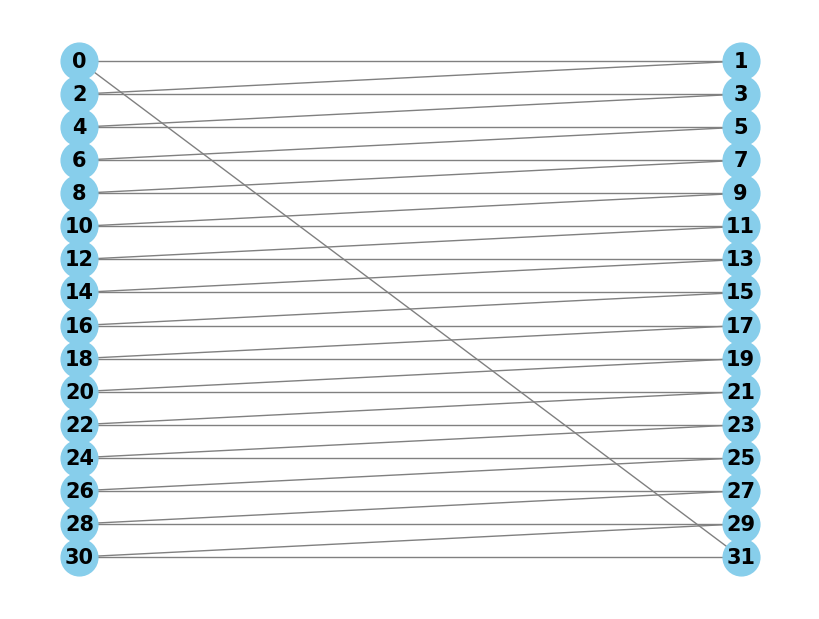

None


Matchings: 2
Matchings: [{('11010', '11011'), ('00110', '00111'), ('11000', '11001'), ('00000', '00001'), ('01010', '01011'), ('11100', '11101'), ('11110', '11111'), ('00100', '00101'), ('01100', '01101'), ('10110', '10111'), ('00010', '00011'), ('01000', '01001'), ('01110', '01111'), ('10010', '10011'), ('10100', '10101'), ('10000', '10001')}, {('11101', '11110'), ('01011', '01100'), ('10111', '11000'), ('11111', '00000'), ('01111', '10000'), ('00001', '00010'), ('01101', '01110'), ('00101', '00110'), ('10101', '10110'), ('01001', '01010'), ('11001', '11010'), ('00011', '00100'), ('10011', '10100'), ('10001', '10010'), ('11011', '11100'), ('00111', '01000')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 62, Edges = 32, Per Edge = 1.938

Sample Circuit - Matching (n_steps=1):


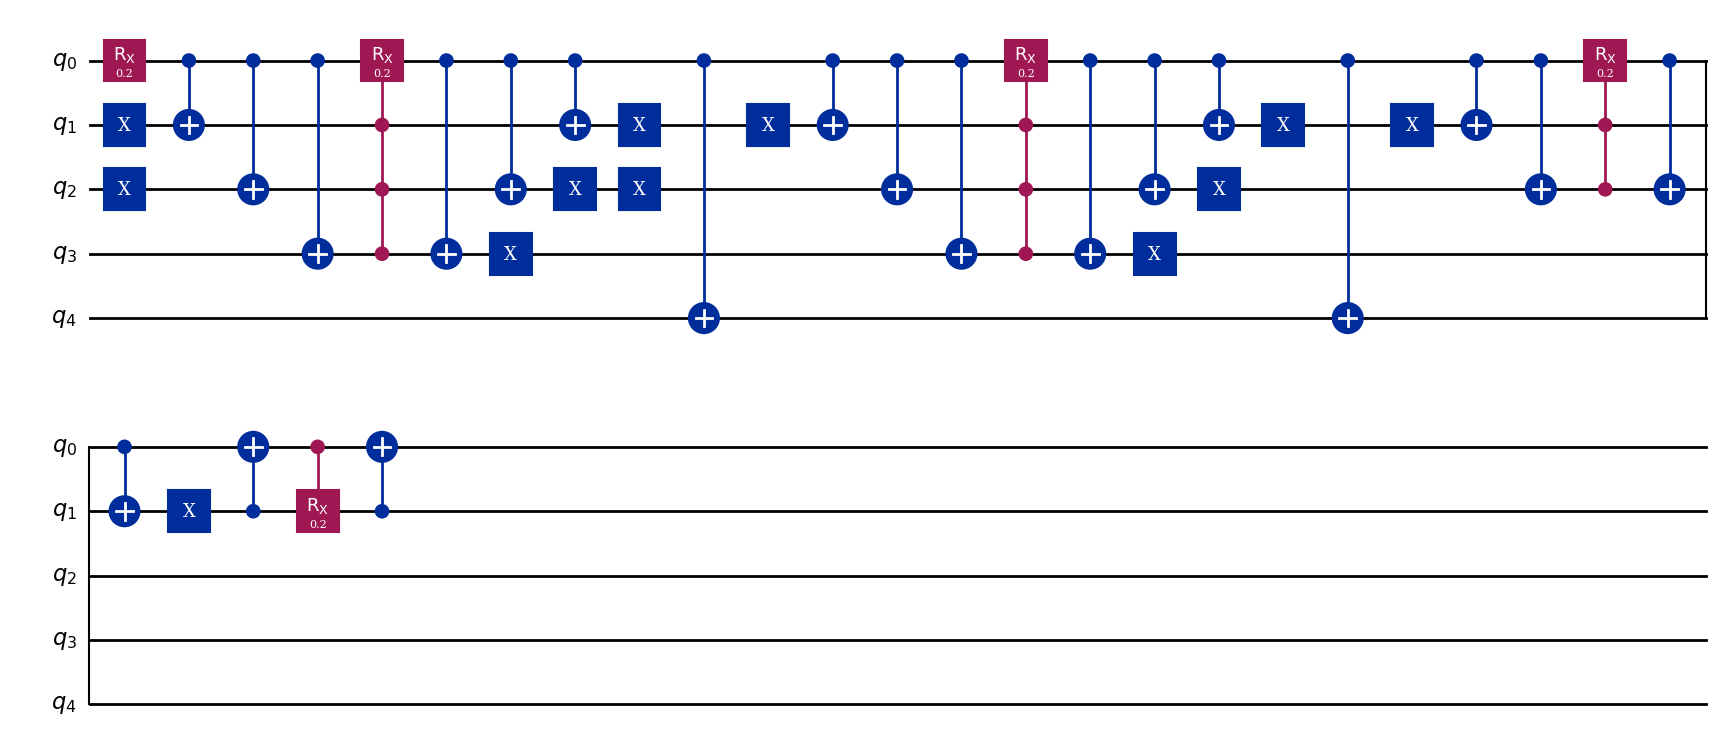


Gate Count Summary (U3/CX) for Cycle C32:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         101/70       52/56        199/132      123/87
       2        202/140     101/111        398/264     240/174
       5        505/350     248/276        995/660     591/435
      10       1010/700     493/551      1990/1320    1176/870
      20      2020/1400    983/1101      3980/2640   2346/1740
      50      5050/3500   2453/2751      9950/6600   5856/4350
     100     10100/7000   4903/5501    19900/13200  11706/8700

Hamming cost/edge: 1.938
Error plot saved as: trotterization_plots/cycle_c32_error_analysis.pdf


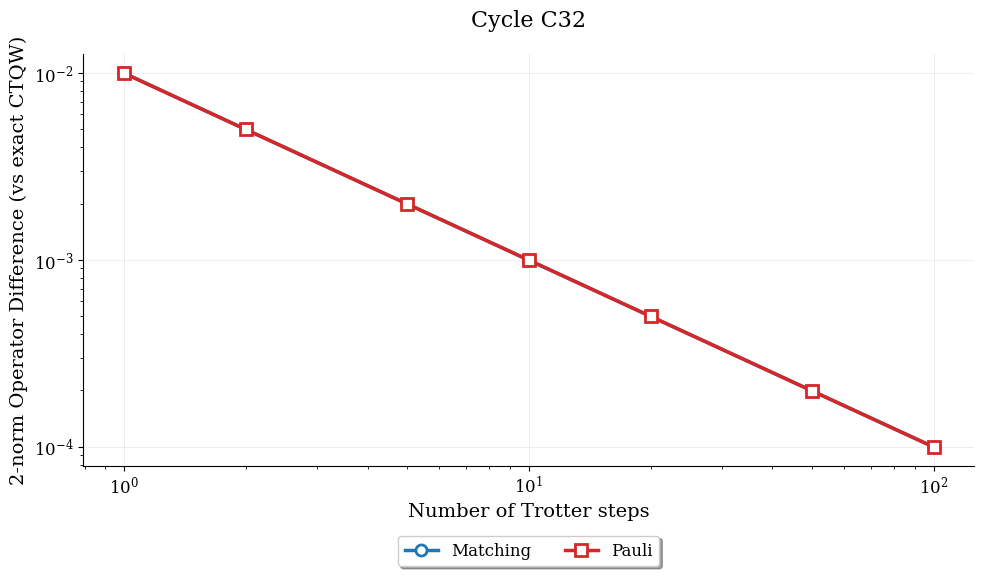

In [25]:
# 5 qubits: Cycle graph C32
cycle_edges = set()
for i in range(32):
    node_i = format(i, '05b')
    j = (i + 1) % 32
    node_j = format(j, '05b')
    if i < j or (i == 31 and j == 0):  # Handle wraparound
        cycle_edges.add((node_i, node_j))

analyze_and_plot(cycle_edges, "Cycle C32")


Star S32
Original edges: {('00000', '11001'), ('00000', '11110'), ('00000', '01011'), ('00000', '01100'), ('00000', '10000'), ('00000', '00111'), ('00000', '00001'), ('00000', '01101'), ('00000', '11101'), ('00000', '00010'), ('00000', '11100'), ('00000', '10100'), ('00000', '00101'), ('00000', '10110'), ('00000', '01010'), ('00000', '01001'), ('00000', '00110'), ('00000', '01111'), ('00000', '01110'), ('00000', '11111'), ('00000', '00100'), ('00000', '01000'), ('00000', '11000'), ('00000', '10010'), ('00000', '11010'), ('00000', '10011'), ('00000', '00011'), ('00000', '11011'), ('00000', '10101'), ('00000', '10111'), ('00000', '10001')}
Number of qubits: 5

Graph:


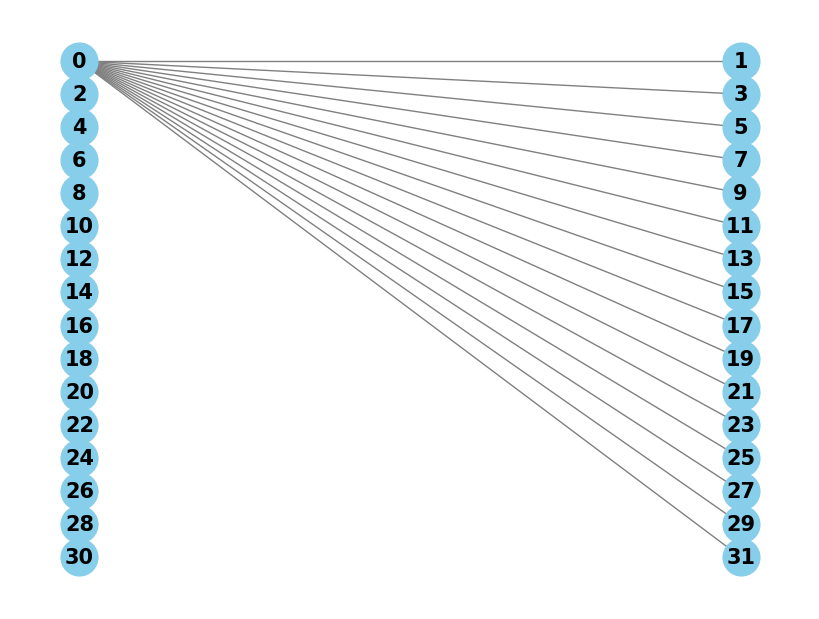

None


Matchings: 31
Matchings: [{('00000', '11001')}, {('00000', '11110')}, {('00000', '01011')}, {('00000', '01100')}, {('00000', '00111')}, {('00000', '01101')}, {('00000', '11101')}, {('00000', '11100')}, {('00000', '10100')}, {('00000', '00101')}, {('00000', '10110')}, {('00000', '01010')}, {('00000', '01001')}, {('00000', '00110')}, {('00000', '01111')}, {('00000', '01110')}, {('00000', '11111')}, {('00000', '11000')}, {('00000', '10010')}, {('00000', '11010')}, {('00000', '10011')}, {('00000', '00011')}, {('00000', '11011')}, {('00000', '10101')}, {('00000', '10111')}, {('00000', '10001')}, {('00000', '10000')}, {('00000', '00001')}, {('00000', '00010')}, {('00000', '00100')}, {('00000', '01000')}]
Number of qubits: 5

Hamming Cost Analysis:
Total = 80, Edges = 31, Per Edge = 2.581

Sample Circuit - Matching (n_steps=1):


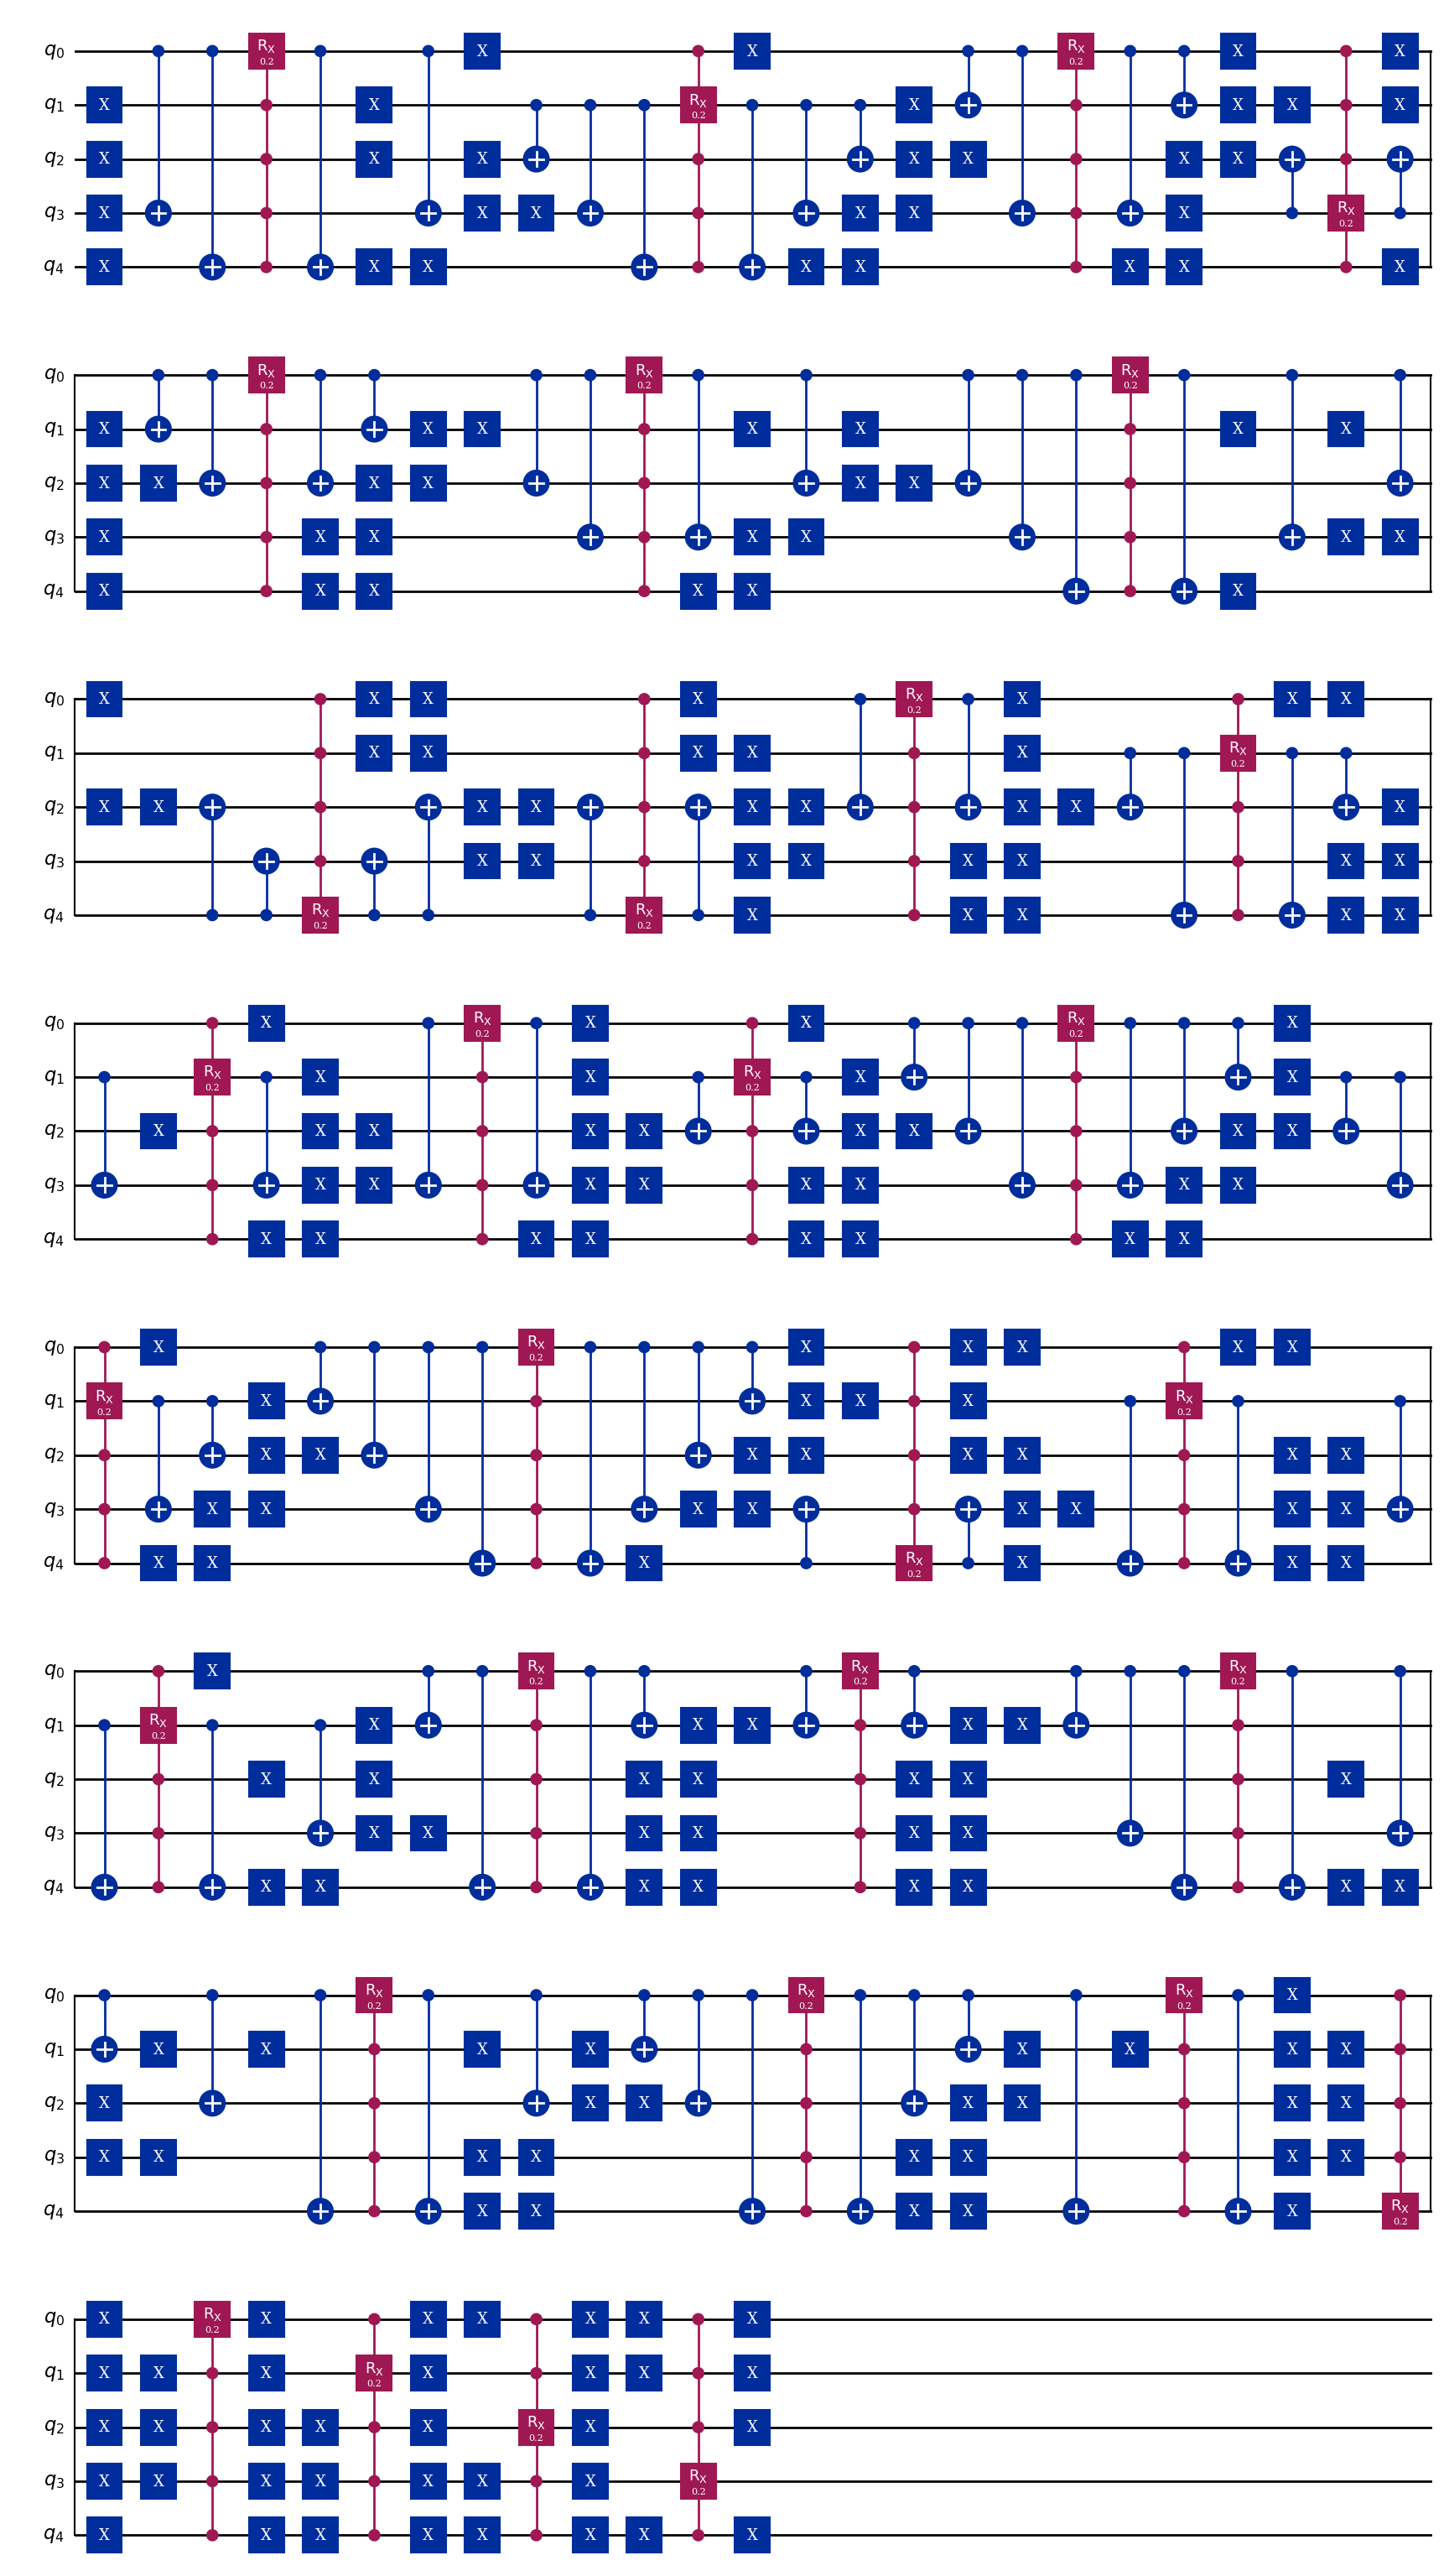


Gate Count Summary (U3/CX) for Star S32:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt)  Pauli (Opt)
       1       1550/842     834/812      3046/2768     1057/624
       2      3100/1684   1660/1624      6092/5536    2125/1248
       5      7750/4210   4138/4060    15230/13840    5296/3120
      10     15500/8420   8268/8120    30460/27680   10531/6240
      20    31000/16840 16528/16240    60920/55360  21301/12480
      50    77500/42100 41308/40600  152300/138400  52651/31200
     100   155000/84200 82608/81200  304600/276800 105301/62400

Hamming cost/edge: 2.581
Error plot saved as: trotterization_plots/star_s32_error_analysis.pdf


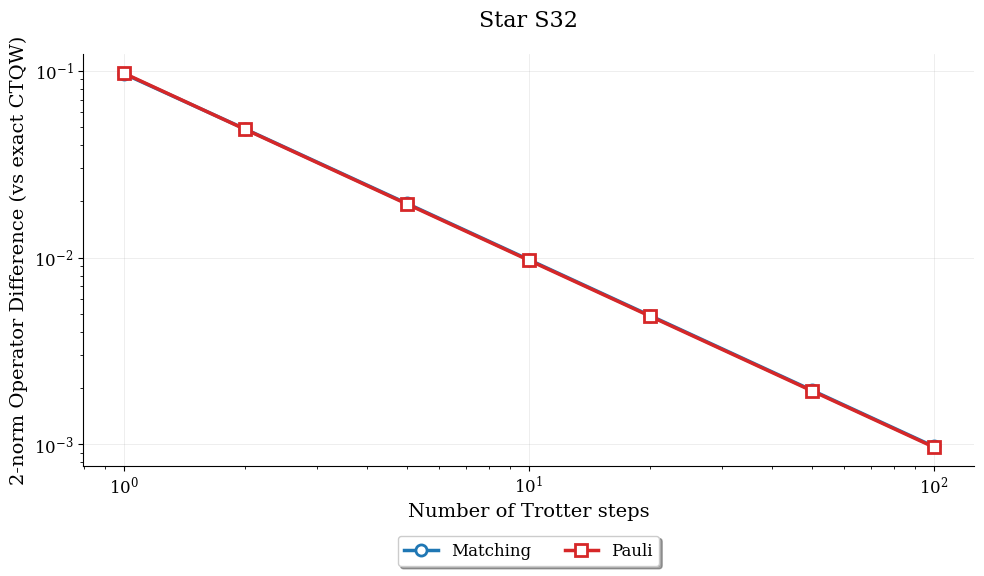

In [26]:
# 5 qubits: Star graph (node 0 connected to all others)
star_edges = set()
node_0 = '00000'
for i in range(1, 32):
    node_i = format(i, '05b')
    star_edges.add((node_0, node_i))

analyze_and_plot(star_edges, "Star S32")


Bipartite K16,16
Original edges: {('00000', '11001'), ('00100', '10101'), ('00111', '11100'), ('01000', '11000'), ('01000', '11010'), ('00011', '10001'), ('00101', '11111'), ('01101', '11000'), ('01101', '11010'), ('00010', '10111'), ('01100', '11011'), ('00101', '10010'), ('01010', '11000'), ('01010', '11010'), ('01111', '10110'), ('00110', '10110'), ('00001', '10000'), ('00100', '11001'), ('00111', '11111'), ('01100', '10001'), ('00111', '10010'), ('00001', '11101'), ('00010', '10000'), ('01011', '11110'), ('01110', '10000'), ('01011', '11001'), ('01010', '10001'), ('00001', '11100'), ('00000', '10110'), ('00011', '11101'), ('00011', '10100'), ('00011', '11100'), ('01000', '10000'), ('00010', '11100'), ('01110', '11100'), ('01101', '10000'), ('00100', '10110'), ('00001', '11111'), ('00110', '10101'), ('01100', '11101'), ('01010', '10000'), ('00001', '10010'), ('01100', '10100'), ('01001', '11000'), ('01001', '11010'), ('01111', '11110'), ('00110', '11110'), ('00011', '11111'), ('011

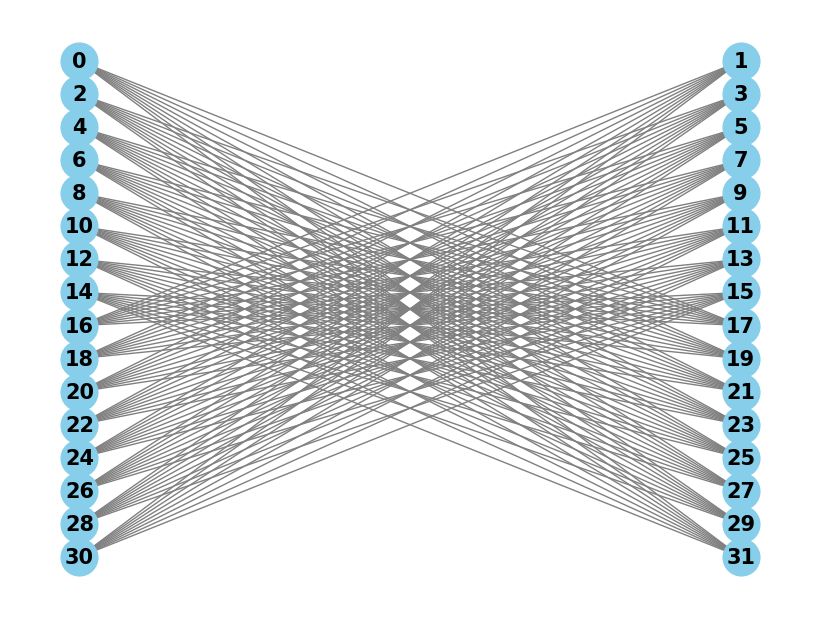

None


Matchings: 16
Matchings: [{('01000', '11000'), ('01101', '11101'), ('00011', '10011'), ('11001', '01001'), ('11110', '01110'), ('00010', '10010'), ('00100', '10100'), ('11100', '01100'), ('10110', '00110'), ('10001', '00001'), ('00000', '10000'), ('11010', '01010'), ('11111', '01111'), ('10101', '00101'), ('11011', '01011'), ('00111', '10111')}, {('00100', '10101'), ('00111', '10110'), ('11000', '01001'), ('11011', '01010'), ('11100', '01101'), ('00010', '10011'), ('11010', '01011'), ('00101', '10100'), ('01100', '11101'), ('10111', '00110'), ('11001', '01000'), ('00001', '10000'), ('01111', '11110'), ('00000', '10001'), ('00011', '10010'), ('11111', '01110')}, {('11111', '01101'), ('01000', '11010'), ('01100', '11110'), ('00011', '10001'), ('11100', '01110'), ('01111', '11101'), ('00010', '10000'), ('00101', '10111'), ('11011', '01001'), ('00100', '10110'), ('00110', '10100'), ('11001', '01011'), ('00000', '10010'), ('00001', '10011'), ('11000', '01010'), ('10101', '00111')}, {('1010

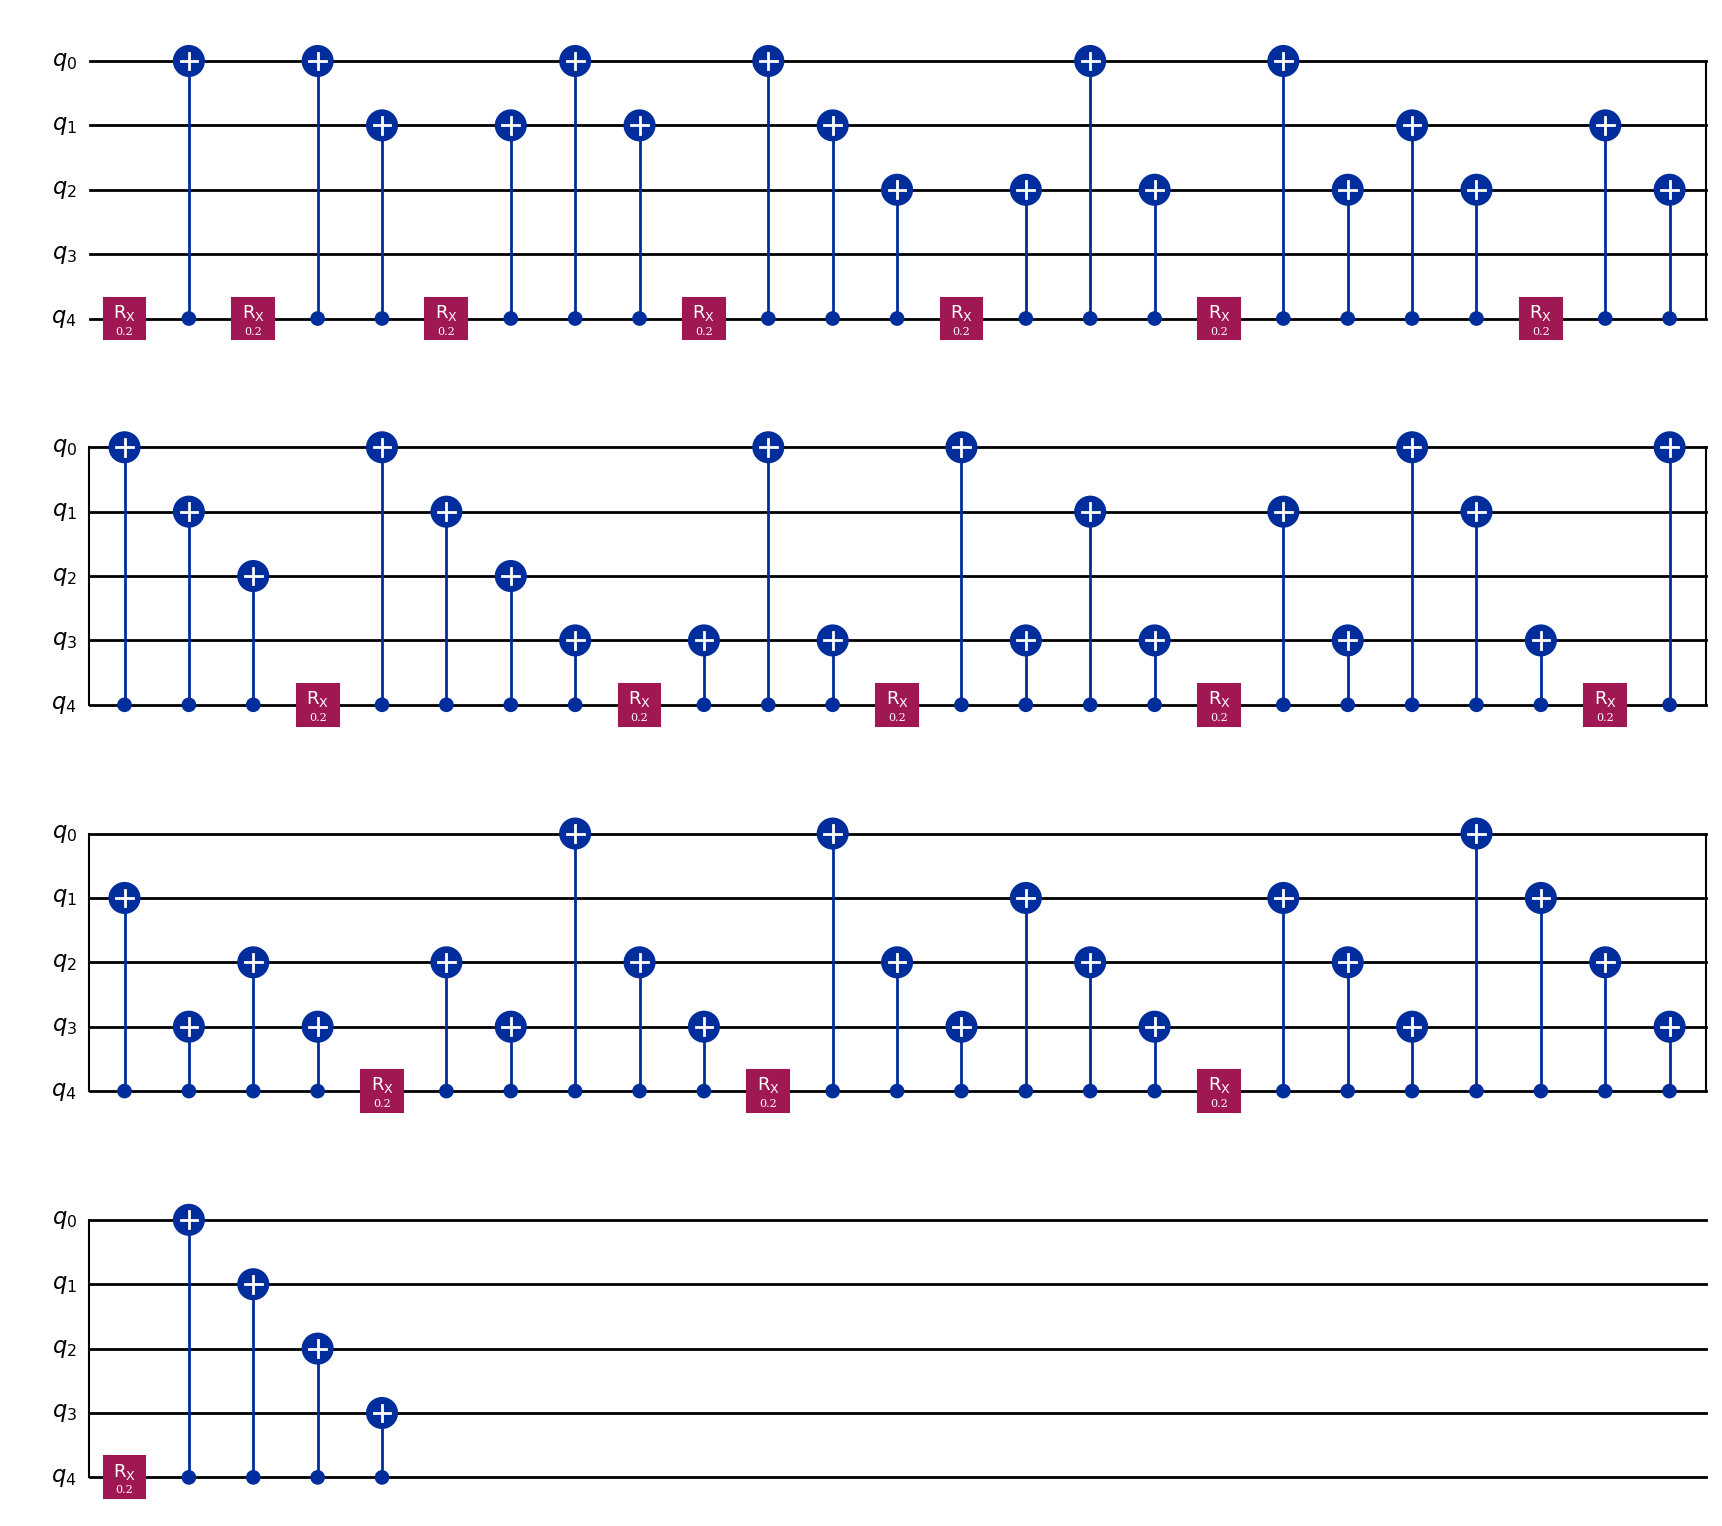


Gate Count Summary (U3/CX) for Bipartite K16,16:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1          16/64       16/30         110/64       43/30
       2         32/128       32/60        220/128       77/60
       5         80/320      80/150        550/320     188/150
      10        160/640     160/300       1100/640     373/300
      20       320/1280     320/600      2200/1280     743/600
      50       800/3200    800/1500      5500/3200   1856/1500
     100      1600/6400   1600/3000     11000/6400   3706/3000

Hamming cost/edge: 3.000
Error plot saved as: trotterization_plots/bipartite_k16,16_error_analysis.pdf


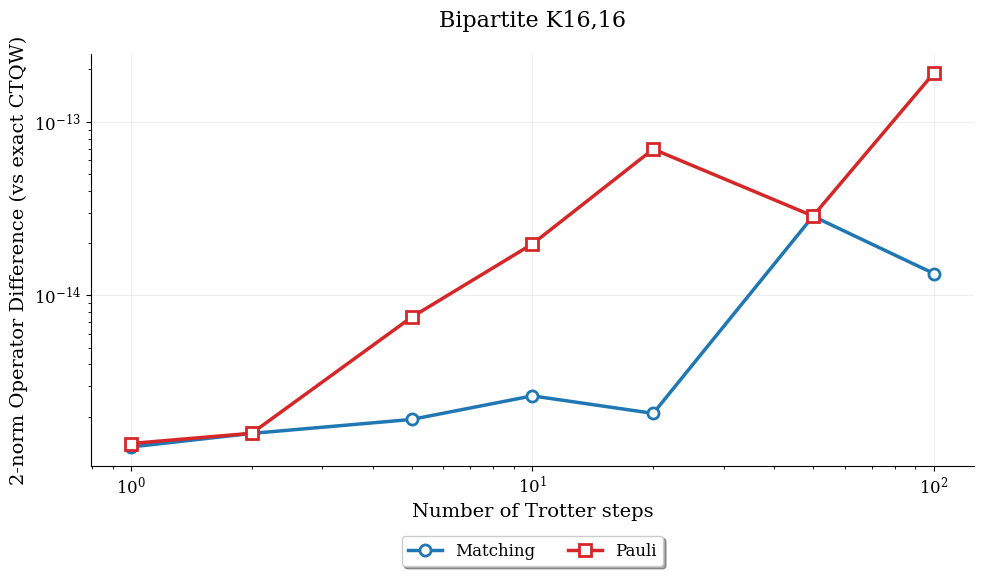

In [27]:
# 5 qubits: Complete bipartite K16,16
bipartite_edges = set()
# Connect all nodes with MSB=0 to all nodes with MSB=1
for i in range(16):
    node_i = format(i, '05b')  # MSB=0
    for j in range(16, 32):
        node_j = format(j, '05b')  # MSB=1
        bipartite_edges.add((node_i, node_j))

analyze_and_plot(bipartite_edges, "Bipartite K16,16")


Peterson Graph
Original edges: {('100', '001'), ('011', '100'), ('100', '000'), ('011', '000'), ('010', '111'), ('001', '010'), ('111', '001'), ('000', '101'), ('101', '111'), ('110', '000'), ('000', '001'), ('001', '110'), ('010', '011')}
Number of qubits: 3

Graph:


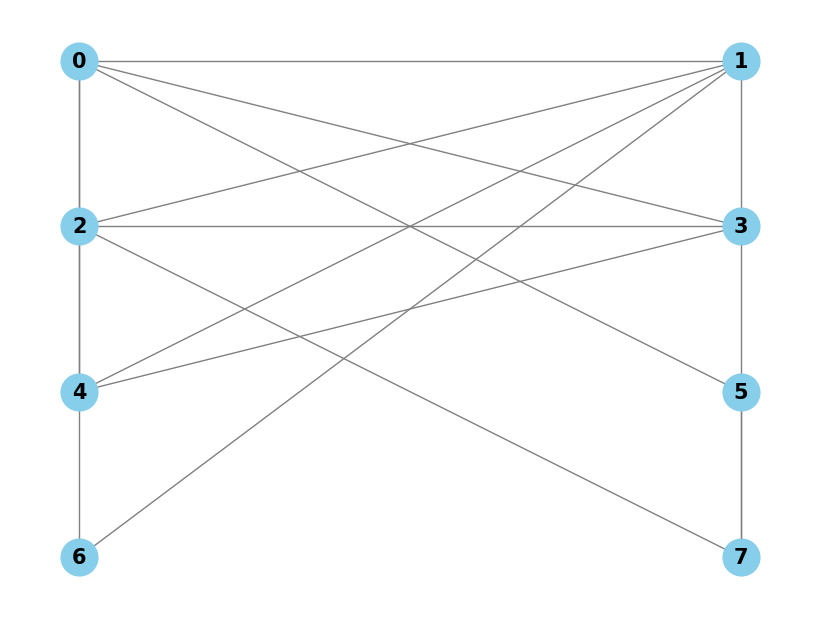

None


Matchings: 7
Matchings: [{('100', '001'), ('010', '111'), ('011', '000')}, {('011', '100'), ('000', '101'), ('001', '010')}, {('111', '001'), ('110', '000')}, {('001', '110')}, {('100', '000')}, {('101', '111')}, {('000', '001'), ('010', '011')}]
Number of qubits: 3

Hamming Cost Analysis:
Total = 24, Edges = 13, Per Edge = 1.846

Sample Circuit - Matching (n_steps=1):


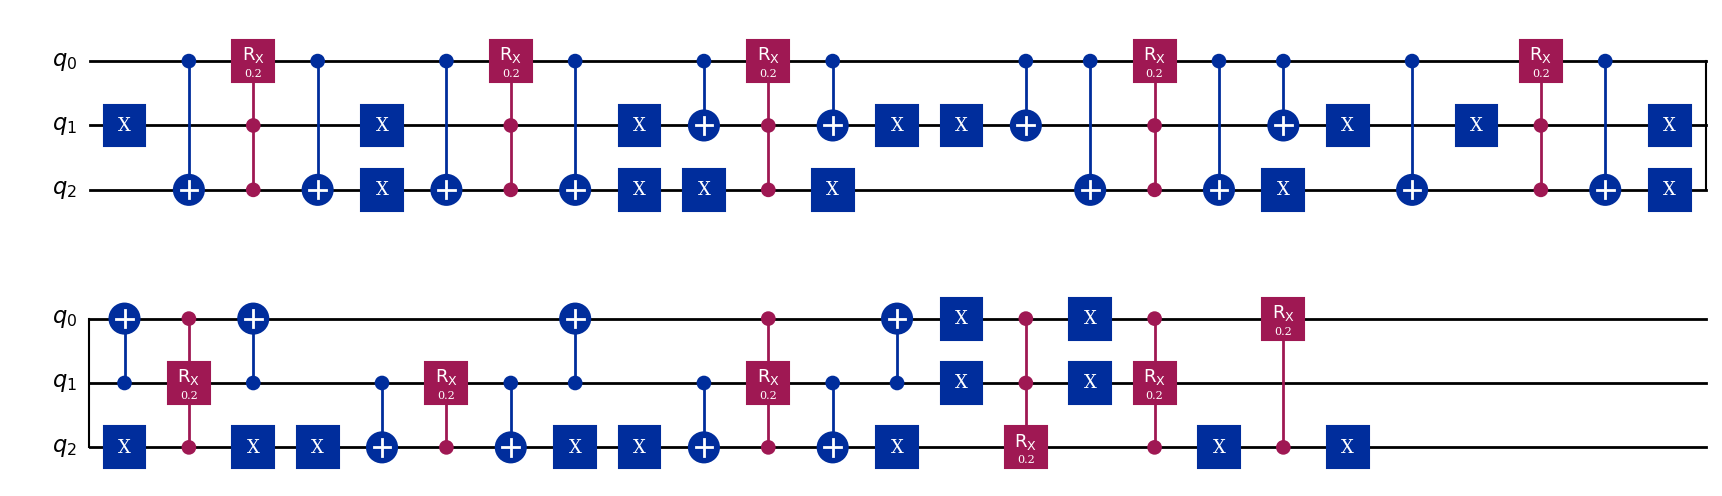


Gate Count Summary (U3/CX) for Peterson Graph:
 n_steps Match (No Opt) Match (Opt) Pauli (No Opt) Pauli (Opt)
       1         167/96       91/83          78/48       44/26
       2        334/192     178/165         156/96       86/52
       5        835/480     439/411        390/240     207/130
      10       1670/960     874/821        780/480     422/260
      20      3340/1920   1744/1641       1560/960     822/520
      50      8350/4800   4354/4101      3900/2400   2102/1300
     100     16700/9600   8704/8201      7800/4800   4102/2600

Hamming cost/edge: 1.846
Error plot saved as: trotterization_plots/peterson_graph_error_analysis.pdf


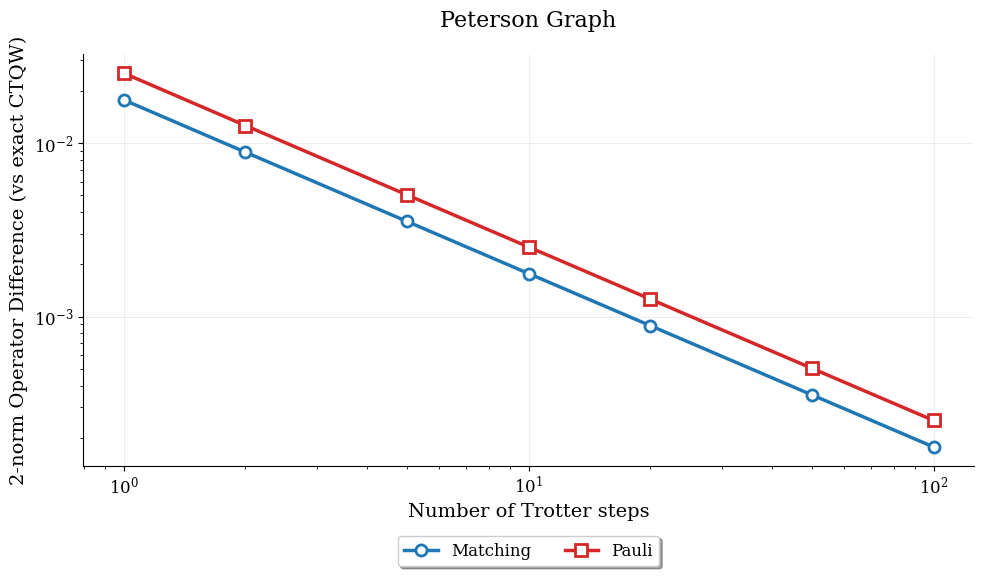

In [28]:
# Peterson graph (needs 10 nodes, we'll use first 10 of 3-qubit space)
# Outer pentagon: 0-1-2-3-4-0
# Inner pentagram: 5-7-9-6-8-5
# Connections: 0-5, 1-6, 2-7, 3-8, 4-9
peterson_edges = {
    # Outer pentagon (using 3-bit labels)
    ('000', '001'), ('001', '010'), ('010', '011'), ('011', '100'), ('100', '000'),
    # Inner pentagram
    ('101', '111'), ('111', '001'), ('001', '110'), ('110', '000'), ('000', '101'),
    # Spoke connections
    ('000', '101'), ('001', '110'), ('010', '111'), ('011', '000'), ('100', '001')
}

analyze_and_plot(peterson_edges, "Peterson Graph")